# Philippine Dengue Forecasting: Do Weather Signals Improve Predictions?

**Exploratory published-source-block benchmark · Revision 0.2.0 · Candidate · E2E / GUIDED · NOTEBOOK_SPEC 2.2**

Can past rainfall and temperature improve forecasts of Quezon City's reported dengue counts one to four reporting blocks ahead? You will compare six systems, change one availability assumption, and conclude using measured evidence.

**Input → System → Output:** aggregate case counts and historical weather → source checks, lagged features, Chronos and Mitra → forecasts, errors, model intervals and a reproducible results bundle.

**Important scope:** the publisher gives conflicting week definitions. We preserve its year/block order without inventing calendar dates. Case–weather alignment and real reporting availability are unverified. Results describe this published alignment, not verified weekly forecasting, clinical diagnosis or an operational warning system.

**How to use:** basic Python/Colab familiarity; choose a fresh **T4 GPU**, keep defaults and **Run all**. No token or manual restart is required. Initial targets are 60 minutes, 20 GiB free disk and 12 GiB peak GPU allocation; hosted measurements are pending. Infrastructure cells handle reproducibility; the numbered sections contain the learning activity.

By the end, identify a forecast origin and horizon, explain time leakage, compare weather against the same model without weather, interpret an interval's empirical coverage, and support a conclusion with errors and limitations.

**AI Assistance Disclosure:** Code and instructional text were developed with generative AI assistance under maintainer direction. The maintainer remains responsible for review, validation and release decisions. AI assistance does not constitute independent verification, provider endorsement or release approval.


In [1]:
import csv
import hashlib
import io
import json
import os
from pathlib import Path
import platform
import shutil
import subprocess
import time
import urllib.request
import uuid
import zipfile
from IPython.display import Image, Markdown, FileLink, display

USE_BYOD = False # @param {type:"boolean"}
BYOD_CSV = "" # @param {type:"string"}
BYOD_SOURCE_BLOCKS_CONFIRMED = False # @param {type:"boolean"}
BYOD_AREA = "" # @param {type:"string"}
BYOD_SOURCE_CITATION = "" # @param {type:"string"}
# Optional BYOD: manually place your aggregate CSV in Colab, then set the controls.
# Exact columns: year,block,cases,rain,temp. At least six complete 52-block years.
# Integer counts, rainfall in mm/block, temperature in Celsius. No individual records.
# Name the area and cite the source: they label outputs and provenance, never predictors.
if USE_BYOD and (not BYOD_SOURCE_BLOCKS_CONFIRMED or not Path(BYOD_CSV).is_file()):
    raise ValueError('Confirm aggregate source-block definitions/units and provide an existing CSV.')
if USE_BYOD and not (BYOD_AREA.strip() and BYOD_SOURCE_CITATION.strip()):
    raise ValueError('Name the BYOD area and cite its source; another area is never relabelled Quezon City.')
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('Use a fresh Colab Linux x86-64 T4 runtime.')
try:
    GPU = subprocess.check_output(['nvidia-smi','--query-gpu=name','--format=csv,noheader'],text=True).strip()
except (FileNotFoundError, subprocess.CalledProcessError) as exc:
    raise RuntimeError('Select Runtime > Change runtime type > T4 GPU, then Run all.') from exc
if 'T4' not in GPU:
    raise RuntimeError('The canonical target is a fresh T4 runtime.')
ROOT = Path.cwd() / 'outputs' / 'dengue' / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
if shutil.disk_usage(ROOT).free < 20*1024**3:
    raise RuntimeError('Allow at least 20 GiB free disk.')
print('Run directory:', ROOT, '\nGPU:', GPU)


Run directory: /content/outputs/dengue/b7f9cc3954ac 
GPU: Tesla T4


## Infrastructure — reproducible local environment

The next cell is collapsed: it carries the embedded source (about 230,000 characters), checks each file against its SHA-256, and builds an isolated Python environment pinned for both models. Expand it to read the code; you do not need to. It does not fetch DIMER scripts or call workers. All stages run locally in this Colab runtime in separate processes.

Optional BYOD is disabled above. It accepts only aggregate `year,block,cases,rain,temp` data with six complete 52-block years: at least two history years plus two validation and two test years. Cases must be nonnegative integer counts, rainfall nonnegative mm per block and temperature in Celsius (−30 to 60). Every row needs all five values; the notebook names the file, line and column of any refusal. Name the area and cite the source in `BYOD_AREA` and `BYOD_SOURCE_CITATION`: they label captions and provenance and are never predictors. Before any model is downloaded, every Mitra context the experiment will need is checked; a constant-count stretch stops the run there, with the affected contexts listed. No individual health records are accepted.


In [2]:
# @title Embedded source, integrity check and isolated environment (collapsed; expand to read)
FILES = {'dengue_runtime.py': '"""Standalone source-block forecasting experiment; no DIMER runtime imports."""\n\nfrom __future__ import annotations\n\nimport argparse\nimport csv\nimport gc\nimport hashlib\nimport json\nimport os\nimport platform\nimport time\nimport zipfile\nfrom pathlib import Path\n\nimport dengue_core as core\nimport dengue_data as data\nimport dengue_models as models\nimport numpy as np\n\nSTAGES = (\n    "prepare",\n    "baselines",\n    "validation",\n    "lock",\n    "test",\n    "activity",\n    "future",\n    "reload",\n    "report",\n)\nSYSTEMS = ("persistence", "seasonal", "ridge", "chronos", "mitra_cases", "mitra_weather")\nSCOPE = "exploratory_published_source_blocks"\nBYOD_FIELDS = ["year", "block", "cases", "rain", "temp"]\nDEFAULT_AREA = "Quezon City, Philippines"\nDEFAULT_SOURCE = "Zenodo record 21978184 (QC Data sheet), ODC-ODbL 1.0"\nRESOURCE_TARGETS = {\n    "kind": "targets, not measurements",\n    "wall_minutes": 60,\n    "free_disk_gib": 20,\n    "peak_gpu_allocated_gib": 12,\n}\nLIMITATIONS = [\n    "Published source-block order only: calendar dates and case-weather alignment are unverified",\n    "Final data vintages: revised counts and retrospective IMERG/ERA5-Land products do not "\n    "reconstruct what was available when each forecast would have been issued",\n    "Zero reporting delay is an assumption; the two-block delay activity is illustrative",\n    "Foundation-model pretraining overlap with this series is unknown",\n    "Two evaluation years (26 origins) limit every comparison; bootstrap intervals are descriptive",\n    "Reported counts, not population-adjusted incidence; not an operational warning system",\n]\n\n\ndef read(path: Path):\n    return json.loads(path.read_text(encoding="utf-8"))\n\n\ndef write(path: Path, obj) -> None:\n    path.parent.mkdir(parents=True, exist_ok=True)\n    path.write_text(json.dumps(obj, indent=2, allow_nan=False), encoding="utf-8", newline="\\n")\n\n\ndef sha(path: Path) -> str:\n    return hashlib.sha256(path.read_bytes()).hexdigest()\n\n\ndef digest(obj) -> str:\n    return hashlib.sha256(json.dumps(obj, sort_keys=True, allow_nan=False).encode()).hexdigest()\n\n\ndef output(root: Path) -> Path:\n    return root / "results"\n\n\ndef rows_at(root: Path):\n    rows = read(root / "data.json")\n    core.validate_rows(rows)\n    return rows\n\n\ndef identity(root: Path) -> str:\n    names = ("data.json", "dataset_audit.json", "model_manifest.json", "source.json")\n    identities = {n: sha(root / n) for n in names}\n    source = read(root / "source.json")\n    for name, checksum in source.get("files", {}).items():\n        if Path(name).name != name or sha(root / name) != checksum:\n            raise ValueError("Embedded source changed: " + name)\n    for name in ("run_config.json", "requirements.txt"):\n        if (root / name).exists():\n            identities[name] = sha(root / name)\n    audit = read(root / "dataset_audit.json")\n    if audit.get("derived_data_sha256") and audit["derived_data_sha256"] != sha(root / "data.json"):\n        raise ValueError("Derived data differs from audited source")\n    for module in (core, data, models):\n        identities[Path(module.__file__).name] = sha(Path(module.__file__))\n    identities["runtime"] = sha(Path(__file__))\n    return digest(identities)\n\n\ndef table(path: Path, rows: list[dict]) -> None:\n    if not rows:\n        raise ValueError(f"No rows for {path.name}")\n    with path.open("w", encoding="utf-8", newline="") as handle:\n        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))\n        writer.writeheader()\n        writer.writerows(rows)\n\n\ndef selected_window(root: Path) -> int:\n    lock = read(output(root) / "experiment_lock.json")\n    if lock["identity"] != identity(root):\n        raise ValueError("Experiment source changed after lock")\n    return lock["window"]\n\n\ndef text_field(value, label: str, limit: int = 160) -> str:\n    """Plain one-line provenance text; never used as a predictor."""\n    text = str(value or "").strip()\n    if not text or len(text) > limit or not text.isprintable():\n        raise ValueError(f"{label} must be one printable line of 1-{limit} characters")\n    return text\n\n\ndef byod_rows(path: Path) -> list[dict]:\n    """Parse the aggregate BYOD CSV, naming the file, line and column of each refusal."""\n    rows = []\n    with path.open(encoding="utf-8-sig", newline="") as handle:\n        reader = csv.reader(handle)\n        header = next(reader, None)\n        if header != BYOD_FIELDS:\n            raise ValueError(\n                f"{path.name}: header must be exactly year,block,cases,rain,temp (found {header}); "\n                "reject extra personal fields and any other extra field"\n            )\n        for line, values in enumerate(reader, start=2):\n            where = f"{path.name} line {line}"\n            if len(values) != len(BYOD_FIELDS):\n                raise ValueError(\n                    f"{where}: expected 5 values, found {len(values)}; "\n                    "extra or missing values are refused"\n                )\n            record = {}\n            for field, raw in zip(BYOD_FIELDS, values, strict=True):\n                text = raw.strip()\n                if not text:\n                    raise ValueError(\n                        f"{where}, column {field}: missing value; missing is never replaced by zero"\n                    )\n                if field in ("year", "block"):\n                    try:\n                        record[field] = int(text)\n                    except ValueError as exc:\n                        raise ValueError(f"{where}, column {field}: must be an integer") from exc\n                    continue\n                try:\n                    number = float(text)\n                except ValueError as exc:\n                    raise ValueError(f"{where}, column {field}: not a number") from exc\n                problem = core.value_problem(field, number)\n                if problem:\n                    raise ValueError(f"{where}, column {field}: {problem}")\n                record[field] = int(number) if field == "cases" else number\n            rows.append(record)\n    return rows\n\n\ndef planned_contexts(rows, plan):\n    """Every support task the model stages can request: partitions, delays, windows, weather."""\n    tasks = [("validation", o, delay) for o in plan["validation"] for delay in (0, 2)]\n    tasks += [("test", o, 0) for o in plan["test"]]\n    tasks += [("future", len(rows) - 1, 0)]\n    for partition, origin, delay in tasks:\n        for h in range(1, 5):\n            for window in plan["windows"]:\n                for weather in (False, True):\n                    yield partition, origin, h, window, delay, weather\n\n\ndef context_preflight(root, rows, plan) -> None:\n    """Refuse an experiment whose mandatory Mitra contexts cannot be fitted, before any model.\n\n    Policy: no origin is dropped, no variance is invented and no fallback is labelled Mitra.\n    """\n    checked, problems = 0, []\n    for partition, origin, h, window, delay, weather in planned_contexts(rows, plan):\n        task = core.training_task(rows, origin, h, window=window, delay=delay, weather=weather)\n        checked += 1\n        problem = models.support_problem(task["X"], task["y"])\n        if problem:\n            problems.append(\n                {\n                    "partition": partition,\n                    "origin_key": key(rows, origin),\n                    "horizon": h,\n                    "window": window,\n                    "delay": delay,\n                    "system": "mitra_weather" if weather else "mitra_cases",\n                    "problem": problem,\n                }\n            )\n    write(\n        output(root) / "context_preflight.json",\n        {\n            "policy": "reject before model staging; no dropped origins, invented variance "\n            "or relabelled fallback",\n            "contexts_checked": checked,\n            "contexts_refused": len(problems),\n            "refused": problems[:50],\n        },\n    )\n    if problems:\n        first = problems[0]\n        raise ValueError(\n            f"{len(problems)} of {checked} planned Mitra contexts cannot be fitted "\n            f"(first: {first[\'partition\']} origin {first[\'origin_key\']}, horizon "\n            f"{first[\'horizon\']}, window {first[\'window\']}, delay {first[\'delay\']}: "\n            f"{first[\'problem\']}). Both Mitra systems are mandatory, so the experiment stops "\n            "before any model is downloaded; see results/context_preflight.json."\n        )\n\n\ndef feature_example(rows, plan) -> list[dict]:\n    """Trace one weather-feature row and its latest mature label to source blocks."""\n    origin, h = plan["test"][0], 1\n    values = core.feature_row(rows, origin, h, weather=True)\n    trace = core.feature_sources(rows, origin, h, weather=True)\n\n    def span(indices):\n        if not indices:\n            return "target block calendar position (known in advance)"\n        first, last = key(rows, indices[0]), key(rows, indices[-1])\n        return first if first == last else f"{first} .. {last}"\n\n    task = core.training_task(rows, origin, h, weather=True)\n    label = int(max(task["target_indices"]))\n    result = [\n        {\n            "item": "forecast origin (issued after this block)",\n            "value": "",\n            "source_blocks": key(rows, origin),\n        },\n        {\n            "item": "target (not observed at issuance)",\n            "value": "",\n            "source_blocks": key(rows, origin + h),\n        },\n    ]\n    result += [\n        {"item": name, "value": round(float(v), 4), "source_blocks": span(indices)}\n        for (name, indices), v in zip(trace, values, strict=True)\n    ]\n    result.append(\n        {\n            "item": "latest mature training label (cases)",\n            "value": rows[label]["cases"],\n            "source_blocks": key(rows, label),\n        }\n    )\n    return result\n\n\ndef fit_ridge(X, y, query):\n    """Training-only standardisation; fixed L2=1 and unpenalised intercept."""\n    X, y, query = np.asarray(X), np.asarray(y), np.asarray(query)\n    mean, scale = X.mean(0), X.std(0)\n    scale[scale < 1e-12] = 1\n    design = np.column_stack([np.ones(len(X)), (X - mean) / scale])\n    penalty = np.eye(design.shape[1])\n    penalty[0, 0] = 0\n    coef = np.linalg.solve(design.T @ design + penalty, design.T @ y)\n    state = {"mean": mean.tolist(), "scale": scale.tolist(), "coef": coef.tolist()}\n    return ridge_predict(state, query), state\n\n\ndef ridge_predict(state, query):\n    q = np.atleast_2d(query)\n    design = np.column_stack([np.ones(len(q)), (q - state["mean"]) / state["scale"]])\n    return design @ np.asarray(state["coef"])\n\n\ndef point(logvalue: float) -> tuple[float, float]:\n    raw = float(np.expm1(logvalue))\n    if not np.isfinite(raw):\n        raise ValueError("Non-finite inverse transformed forecast")\n    return raw, max(0.0, raw)\n\n\ndef key(rows, index):\n    # Preserve source block order. These are not reconstructed observation dates.\n    year = rows[0]["year"] + index // 52\n    return f"{year}-B{index % 52 + 1:02d}"\n\n\ndef prediction(rows, system, origin, h, delay, raw, q=None):\n    if not np.isfinite(raw):\n        raise ValueError("Non-finite prediction")\n    item = dict(\n        system=system,\n        origin=origin,\n        origin_key=key(rows, origin),\n        cutoff=origin - delay,\n        target_index=origin + h,\n        target_key=key(rows, origin + h),\n        horizon=h,\n        delay=delay,\n        reference=rows[origin + h]["cases"] if origin + h < len(rows) else None,\n        raw_prediction=float(raw),\n        prediction=max(0.0, float(raw)),\n        clipped=bool(raw < 0),\n        q10=None,\n        q50=None,\n        q90=None,\n    )\n    if q is not None:\n        if not np.isfinite(q).all() or np.any(np.diff(q) < 0):\n            raise ValueError("Invalid/crossing model quantiles")\n        item.update(q10=float(q[0]), q50=float(q[1]), q90=float(q[2]))\n    return item\n\n\ndef simple(rows, origins, window=104, delay=0, save=False):\n    predictions, states = [], {}\n    for origin in origins:\n        for h in range(1, 5):\n            predictions.append(\n                prediction(rows, "persistence", origin, h, delay, rows[origin - delay]["cases"])\n            )\n            seasonal_index = origin + h - 52\n            if seasonal_index > origin - delay:\n                raise ValueError("Seasonal baseline accesses unavailable value")\n            predictions.append(\n                prediction(rows, "seasonal", origin, h, delay, rows[seasonal_index]["cases"])\n            )\n            task = core.training_task(rows, origin, h, window=window, delay=delay)\n            estimate, state = fit_ridge(task["X"], task["y"], task["query"])\n            raw, _ = point(float(estimate[0]))\n            predictions.append(prediction(rows, "ridge", origin, h, delay, raw))\n            if save:\n                states[str(h)] = {"state": state, "query": np.asarray(task["query"]).tolist()}\n    return predictions, states\n\n\ndef free_gpu() -> None:\n    gc.collect()\n    import torch\n\n    if torch.cuda.is_available():\n        torch.cuda.empty_cache()\n\n\ndef model_forecasts(root, rows, origins, window, system, delay=0, save=False):\n    manifest = read(root / "model_manifest.json")\n    cache = root / "models"\n    state = {"system": system, "window": window, "delay": delay, "origins": {}}\n    if system == "chronos":\n        model = models.load_chronos(cache, manifest)\n    else:\n        model = models.load_mitra(cache, manifest)\n    predictions = []\n    try:\n        for number, origin in enumerate(origins):\n            print(f"{system}: origin {number + 1}/{len(origins)} {key(rows, origin)}", flush=True)\n            if system == "chronos":\n                history = [\n                    r["cases"] for r in rows[max(0, origin - delay - 103) : origin - delay + 1]\n                ]\n                quantiles = np.asarray(models.chronos_predict(model, history, 4 + delay))\n                if quantiles.shape != (4 + delay, 3):\n                    raise ValueError("Unexpected Chronos forecast shape")\n                for h in range(1, 5):\n                    q = quantiles[h + delay - 1]\n                    predictions.append(prediction(rows, system, origin, h, delay, q[1], q))\n                if save:\n                    state["origins"][str(origin)] = {"history": history}\n            else:\n                saved = {}\n                for h in range(1, 5):\n                    task = core.training_task(\n                        rows,\n                        origin,\n                        h,\n                        window=window,\n                        delay=delay,\n                        weather=system == "mitra_weather",\n                    )\n                    estimate = np.asarray(\n                        models.mitra_predict(\n                            model, task["X"], task["y"], np.atleast_2d(task["query"])\n                        )\n                    ).reshape(-1)\n                    if len(estimate) != 1:\n                        raise ValueError("Expected exactly one direct forecast")\n                    raw, _ = point(float(estimate[0]))\n                    predictions.append(prediction(rows, system, origin, h, delay, raw))\n                    if save:\n                        saved[str(h)] = {\n                            k: np.asarray(task[k]).tolist() for k in ("X", "y", "query")\n                        }\n                        saved[str(h)]["issuance_indices"] = np.asarray(\n                            task["issuance_indices"]\n                        ).tolist()\n                        saved[str(h)]["feature_names"] = task["feature_names"]\n                if save:\n                    state["origins"][str(origin)] = saved\n    finally:\n        del model\n        free_gpu()\n    return predictions, state\n\n\ndef scores(predictions):\n    result = {}\n    for system in sorted({p["system"] for p in predictions}):\n        selected = [p for p in predictions if p["system"] == system]\n        horizons = {}\n        for h in range(1, 5):\n            subset = [p for p in selected if p["horizon"] == h]\n            horizons[str(h)] = core.metrics(\n                [p["reference"] for p in subset], [p["prediction"] for p in subset]\n            )\n        result[system] = {\n            "origins": len(selected) // 4,\n            "pairs": len(selected),\n            "mae": float(np.mean([v["mae"] for v in horizons.values()])),\n            "horizons": horizons,\n        }\n    if "seasonal" in result:\n        for value in result.values():\n            value["seasonal_skill"] = core.skill(value["mae"], result["seasonal"]["mae"])\n    return result\n\n\ndef figures(root, stage):\n    import matplotlib\n\n    matplotlib.use("Agg")\n    import matplotlib.pyplot as plt\n\n    out = output(root)\n    if stage == "prepare":\n        rows = rows_at(root)\n        plan = read(out / "plan.json")\n        spans = [(plan["validation_years"][0], "orange"), (plan["test_years"][0], "green")]\n        if any(r.get("covid") for r in rows):\n            spans.insert(0, (2020, "gray"))\n        fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)\n        for ax, name in zip(axes, ("cases", "rain", "temp"), strict=True):\n            ax.plot([r[name] for r in rows], linewidth=0.8)\n            ax.set_ylabel(\n                {"cases": "Reported cases", "rain": "Rain (mm/block)", "temp": "Temperature (°C)"}[\n                    name\n                ]\n            )\n            for year, color in spans:\n                start = (year - rows[0]["year"]) * 52\n                if start >= 0:\n                    ax.axvspan(start, start + 104, alpha=0.12, color=color)\n        axes[-1].set_xlabel("Published source-block index (not verified dates)")\n        fig.suptitle(\n            f"{plan[\'area\']} · published alignment · orange validation / green test; "\n            "gray if COVID flagged"\n        )\n    else:\n        name = {\n            "baselines": "baseline_metrics.json",\n            "validation": "validation_metrics.json",\n            "test": "metrics.json",\n            "activity": "delay_metrics.json",\n        }[stage]\n        values = read(out / name)\n        fig, ax = plt.subplots(figsize=(10, 5))\n        for system, value in values.items():\n            ax.plot(\n                range(1, 5),\n                [value["horizons"][str(h)]["mae"] for h in range(1, 5)],\n                marker="o",\n                label=system,\n            )\n        ax.set(\n            xlabel="Forecast horizon (source blocks)",\n            ylabel="MAE (cases)",\n            xticks=range(1, 5),\n            title=stage + " · lower MAE is better",\n        )\n        ax.legend()\n    fig.tight_layout()\n    fig.savefig(out / f"{stage}.png", dpi=130)\n    plt.close(fig)\n    if stage == "test":\n        pred = read(out / "test_predictions.json")\n        fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)\n        for system in ("chronos", "mitra_cases", "mitra_weather"):\n            subset = sorted(\n                [p for p in pred if p["system"] == system and p["horizon"] == 4],\n                key=lambda p: p["target_index"],\n            )\n            x = [p["target_index"] for p in subset]\n            axes[0].plot(x, [p["prediction"] for p in subset], label=system)\n            if system == "chronos":\n                axes[0].plot(\n                    x, [p["reference"] for p in subset], color="black", label="Published counts"\n                )\n                axes[0].fill_between(\n                    x,\n                    [p["q10"] for p in subset],\n                    [p["q90"] for p in subset],\n                    alpha=0.15,\n                    label="Chronos nominal 80% interval",\n                )\n            else:\n                axes[1].plot(x, [p["prediction"] - p["reference"] for p in subset], label=system)\n        area = read(out / "plan.json")["area"]\n        axes[0].set(\n            ylabel="Cases",\n            title=f"{area} · four-block forecasts · same targets; raw Chronos interval",\n        )\n        axes[1].axhline(0, color="black", linewidth=0.7)\n        axes[1].set(xlabel="Published source-block index", ylabel="Prediction − reference")\n        for ax in axes:\n            ax.legend()\n        fig.tight_layout()\n        fig.savefig(out / "test_forecasts.png", dpi=130)\n        plt.close(fig)\n\n\ndef largest_misses(predictions) -> list[dict]:\n    """Learner view: each miss with its published count, forecast and signed error."""\n    misses = sorted(predictions, key=lambda p: abs(p["prediction"] - p["reference"]), reverse=True)[\n        :20\n    ]\n    return [\n        {\n            "system": p["system"],\n            "origin_key": p["origin_key"],\n            "target_key": p["target_key"],\n            "horizon": p["horizon"],\n            "reference": p["reference"],\n            "prediction": round(p["prediction"], 3),\n            "error": round(p["prediction"] - p["reference"], 3),\n            "abs_error": round(abs(p["prediction"] - p["reference"]), 3),\n            "raw_prediction": round(p["raw_prediction"], 3),\n            "clipped": p["clipped"],\n        }\n        for p in misses\n    ]\n\n\ndef prepare(root):\n    # BYOD is selected before this stage and never opens an upload dialog by default.\n    config = read(root / "run_config.json") if (root / "run_config.json").exists() else {}\n    if config.get("byod_csv"):\n        if not config.get("source_blocks_confirmed"):\n            raise ValueError("BYOD requires aggregate schema, units and source-block confirmation")\n        area = text_field(config.get("area"), "BYOD_AREA", 120)\n        citation = text_field(config.get("source_citation"), "BYOD_SOURCE_CITATION")\n        rows = byod_rows(Path(config["byod_csv"]))\n        core.validate_rows(rows)\n        if len(rows) < 6 * 52:\n            raise ValueError(\n                "Need six complete source years: two history, two validation, two test"\n            )\n        write(root / "data.json", rows)\n        write(\n            root / "dataset_audit.json",\n            {\n                "scope": SCOPE,\n                "source": "BYOD",\n                "area": area,\n                "source_citation": citation,\n                "units": core.UNITS,\n                "source_sha256": sha(Path(config["byod_csv"])),\n                "rows": len(rows),\n                "timing_verified": False,\n                "weather_alignment_verified": False,\n            },\n        )\n        (root / "DATA_LICENSE.md").write_text(\n            "BYOD: retain your source rights and provenance.\\n", encoding="utf-8"\n        )\n    else:\n        rows = data.acquire(root)\n        area, citation = DEFAULT_AREA, DEFAULT_SOURCE\n    core.validate_rows(rows)\n    years = sorted({r["year"] for r in rows})\n    val_years, test_years = years[-4:-2], years[-2:]\n    plan = {\n        "scope": SCOPE,\n        "validation_years": val_years,\n        "test_years": test_years,\n        "validation": core.origins(rows, val_years),\n        "test": core.origins(rows, test_years),\n        "default_delay": 0,\n        "windows": [52, 104],\n        "chronos_window": 104,\n        "high_case_threshold": float(\n            np.quantile([r["cases"] for r in rows if r["year"] < val_years[0]], 0.9)\n        ),\n        "calendar_verified": False,\n        "alignment_verified": False,\n        "area": area,\n        "source_citation": citation,\n        "units": core.UNITS,\n    }\n    if len(plan["test"]) != 26 or len(plan["validation"]) != 26:\n        raise ValueError("Expected 26 origins per partition; no silent reduction")\n    write(output(root) / "plan.json", plan)\n    context_preflight(root, rows, plan)\n    table(output(root) / "feature_example.csv", feature_example(rows, plan))\n    table(\n        output(root) / "origin_manifest.csv",\n        [\n            {\n                "partition": part,\n                "origin": o,\n                "origin_key": key(rows, o),\n                "horizon": h,\n                "target_key": key(rows, o + h),\n                "cutoff": o,\n            }\n            for part in ("validation", "test")\n            for o in plan[part]\n            for h in range(1, 5)\n        ],\n    )\n    write(\n        output(root) / "feature_schema.json",\n        {\n            name: core.feature_names(weather=weather)\n            for name, weather in [("cases", False), ("weather", True)]\n        },\n    )\n    audit_rows = []\n    for partition in ("validation", "test"):\n        for origin in plan[partition]:\n            for h in range(1, 5):\n                task = core.training_task(rows, origin, h)\n                audit_rows.append(\n                    {\n                        "partition": partition,\n                        "origin": origin,\n                        "horizon": h,\n                        "cutoff": origin,\n                        "max_training_target": int(max(task["target_indices"])),\n                        "max_training_input": int(max(task["issuance_indices"])),\n                        "query_latest_input": origin,\n                        "future_input_used": False,\n                    }\n                )\n    table(output(root) / "availability_audit.csv", audit_rows)\n\n\ndef baselines(root):\n    rows, plan = rows_at(root), read(output(root) / "plan.json")\n    predictions, _ = simple(rows, plan["validation"])\n    write(output(root) / "baseline_validation.json", predictions)\n    write(output(root) / "baseline_metrics.json", scores(predictions))\n\n\ndef validation(root):\n    rows, plan = rows_at(root), read(output(root) / "plan.json")\n    candidates = {}\n    for window in (52, 104):\n        pred, _ = model_forecasts(root, rows, plan["validation"], window, "mitra_cases")\n        write(output(root) / f"validation_cases_{window}.json", pred)\n        candidates[window] = scores(pred)["mitra_cases"]["mae"]\n    chosen = min(candidates, key=lambda w: (candidates[w], w))\n    all_predictions = read(output(root) / "baseline_validation.json")\n    all_predictions += read(output(root) / f"validation_cases_{chosen}.json")\n    for system in ("mitra_weather", "chronos"):\n        pred, _ = model_forecasts(root, rows, plan["validation"], chosen, system)\n        all_predictions.extend(pred)\n    write(output(root) / "selection.json", {"window": chosen, "candidate_mae": candidates})\n    write(output(root) / "validation_predictions.json", all_predictions)\n    write(output(root) / "validation_metrics.json", scores(all_predictions))\n\n\ndef lock(root):\n    write(\n        output(root) / "experiment_lock.json",\n        {\n            "identity": identity(root),\n            "window": read(output(root) / "selection.json")["window"],\n            "plan_sha256": sha(output(root) / "plan.json"),\n            "systems": SYSTEMS,\n            "target_transform": "log1p for ridge/mitra; expm1 then nonnegative floor",\n            "weather_comparison": "mitra_weather minus mitra_cases",\n            "seed": 42,\n            "retrospective_delay_assumption": 0,\n            "scope": SCOPE,\n        },\n    )\n\n\ndef test(root):\n    rows, plan, window = rows_at(root), read(output(root) / "plan.json"), selected_window(root)\n    predictions, _ = simple(rows, plan["test"])\n    for system in ("chronos", "mitra_cases", "mitra_weather"):\n        pred, state = model_forecasts(root, rows, plan["test"], window, system, save=True)\n        predictions.extend(pred)\n        # Store just the final completed origin for an independent reload check.\n        final = str(plan["test"][-1])\n        state["origins"] = {final: state["origins"][final]}\n        write(output(root) / f"artifact_test_{system}.json", state)\n    last_simple, state = simple(rows, [plan["test"][-1]], save=True)\n    write(output(root) / "artifact_test_ridge.json", state)\n    write(\n        output(root) / "reload_expected_test.json",\n        [p for p in predictions if p["origin"] == plan["test"][-1]],\n    )\n    del last_simple\n    assert_cohort(predictions, plan["test"], rows)\n    write(output(root) / "test_predictions.json", predictions)\n    table(output(root) / "predictions.csv", predictions)\n    table(output(root) / "largest_misses.csv", largest_misses(predictions))\n    write(output(root) / "metrics.json", scores(predictions))\n\n    def ordered(system):\n        return sorted(\n            [p for p in predictions if p["system"] == system],\n            key=lambda p: (p["origin"], p["horizon"]),\n        )\n\n    cases, weather = ordered("mitra_cases"), ordered("mitra_weather")\n    ref = np.array([p["reference"] for p in cases]).reshape(-1, 4)\n    a = np.array([p["prediction"] for p in cases]).reshape(-1, 4)\n    b = np.array([p["prediction"] for p in weather]).reshape(-1, 4)\n    write(output(root) / "paired_comparison.json", core.paired_bootstrap(ref, a, b))\n    high = {}\n    for system in SYSTEMS:\n        p = [p for p in ordered(system) if p["reference"] >= plan["high_case_threshold"]]\n        high[system] = {\n            "n": len(p),\n            "threshold": plan["high_case_threshold"],\n            "metrics": core.metrics([x["reference"] for x in p], [x["prediction"] for x in p])\n            if p\n            else None,\n            "underprediction_rate": float(np.mean([x["prediction"] < x["reference"] for x in p]))\n            if p\n            else None,\n        }\n    write(output(root) / "high_case_metrics.json", high)\n    intervals = {}\n    for h in range(1, 5):\n        p = [p for p in ordered("chronos") if p["horizon"] == h]\n        truth = np.array([x["reference"] for x in p])\n        q = np.array([[x["q10"], x["q50"], x["q90"]] for x in p])\n        error = truth[:, None] - q\n        intervals[str(h)] = {\n            "n": len(p),\n            "raw_coverage_80": float(np.mean((truth >= q[:, 0]) & (truth <= q[:, 2]))),\n            "raw_mean_width": float(np.mean(q[:, 2] - q[:, 0])),\n            "pinball": np.maximum(\n                error * np.array([0.1, 0.5, 0.9]), error * (np.array([0.1, 0.5, 0.9]) - 1)\n            )\n            .mean(0)\n            .tolist(),\n        }\n    write(output(root) / "interval_metrics.json", intervals)\n\n\ndef assert_cohort(predictions, origins, rows=None):\n    expected = {(o, h) for o in origins for h in range(1, 5)}\n    matched = {}\n    if {p["system"] for p in predictions} != set(SYSTEMS):\n        raise ValueError("Unexpected or missing systems")\n    for system in SYSTEMS:\n        subset = [p for p in predictions if p["system"] == system]\n        if (\n            len(subset) != len(expected)\n            or {(p["origin"], p["horizon"]) for p in subset} != expected\n        ):\n            raise ValueError(f"Incomplete or duplicated cohort: {system}")\n        for p in subset:\n            pair = (p["origin"], p["horizon"])\n            signature = tuple(\n                p[k]\n                for k in (\n                    "origin_key",\n                    "cutoff",\n                    "target_index",\n                    "target_key",\n                    "delay",\n                    "reference",\n                )\n            )\n            if pair in matched and matched[pair] != signature:\n                raise ValueError("Paired target/cutoff/reference disagreement")\n            matched[pair] = signature\n            if (\n                p["target_index"] != p["origin"] + p["horizon"]\n                or p["cutoff"] != p["origin"] - p["delay"]\n            ):\n                raise ValueError("Invalid forecast timing fields")\n            if rows is not None and (\n                p["target_key"] != key(rows, p["target_index"])\n                or p["reference"] != rows[p["target_index"]]["cases"]\n            ):\n                raise ValueError("Forecast reference does not match source")\n\n\ndef activity(root):\n    rows, plan, window = rows_at(root), read(output(root) / "plan.json"), selected_window(root)\n    predictions, _ = simple(rows, plan["validation"], delay=2)\n    for system in ("chronos", "mitra_cases", "mitra_weather"):\n        p, _ = model_forecasts(root, rows, plan["validation"], window, system, delay=2)\n        predictions.extend(p)\n    assert_cohort(predictions, plan["validation"], rows)\n    table(output(root) / "validation_delay_activity.csv", predictions)\n    delayed = scores(predictions)\n    write(output(root) / "delay_metrics.json", delayed)\n    baseline = {\n        (p["system"], p["origin"], p["horizon"]): p\n        for p in read(output(root) / "validation_predictions.json")\n    }\n    paired = []\n    order = sorted(\n        predictions, key=lambda p: (SYSTEMS.index(p["system"]), p["origin"], p["horizon"])\n    )\n    for p in order:\n        zero = baseline[(p["system"], p["origin"], p["horizon"])]\n        if zero["target_index"] != p["target_index"] or zero["reference"] != p["reference"]:\n            raise ValueError("Delay activity is not paired with zero-delay validation targets")\n        paired.append(\n            {\n                "system": p["system"],\n                "origin_key": p["origin_key"],\n                "target_key": p["target_key"],\n                "horizon": p["horizon"],\n                "reference": p["reference"],\n                "prediction_delay_0": round(zero["prediction"], 3),\n                "prediction_delay_2": round(p["prediction"], 3),\n                "abs_error_delay_0": round(abs(zero["prediction"] - zero["reference"]), 3),\n                "abs_error_delay_2": round(abs(p["prediction"] - p["reference"]), 3),\n                "abs_error_change": round(\n                    abs(p["prediction"] - p["reference"])\n                    - abs(zero["prediction"] - zero["reference"]),\n                    3,\n                ),\n            }\n        )\n    table(output(root) / "delay_comparison.csv", paired)\n    zero_scores = read(output(root) / "validation_metrics.json")\n    table(\n        output(root) / "delay_summary.csv",\n        [\n            {\n                "system": system,\n                "pairs": delayed[system]["pairs"],\n                "mae_delay_0": round(zero_scores[system]["mae"], 3),\n                "mae_delay_2": round(delayed[system]["mae"], 3),\n                "change": round(delayed[system]["mae"] - zero_scores[system]["mae"], 3),\n            }\n            for system in SYSTEMS\n        ],\n    )\n\n\ndef future(root):\n    rows, window = rows_at(root), selected_window(root)\n    origin = len(rows) - 1\n    predictions, ridge = simple(rows, [origin], save=True)\n    write(output(root) / "artifact_future_ridge.json", ridge)\n    for system in ("chronos", "mitra_cases", "mitra_weather"):\n        p, state = model_forecasts(root, rows, [origin], window, system, save=True)\n        predictions.extend(p)\n        write(output(root) / f"artifact_future_{system}.json", state)\n    write(output(root) / "future_predictions.json", predictions)\n    table(output(root) / "future_predictions.csv", predictions)\n    by_target = {}\n    for p in predictions:\n        by_target.setdefault((p["horizon"], p["target_key"]), {})[p["system"]] = round(\n            p["prediction"], 2\n        )\n    table(\n        output(root) / "future_forecast_view.csv",\n        [\n            {"target_key": target, "horizon": h, **{s: values[s] for s in SYSTEMS}}\n            for (h, target), values in sorted(by_target.items())\n        ],\n    )\n    artifacts = {p.name: sha(p) for p in output(root).glob("artifact_*.json")}\n    write(\n        output(root) / "artifact_manifest.json",\n        {\n            "format": "dimer_dengue_forecast_contexts",\n            "format_version": 1,\n            "identity": identity(root),\n            "files": artifacts,\n            "creator_pid": os.getpid(),\n            "feature_schema_sha256": sha(output(root) / "feature_schema.json"),\n            "experiment_lock_sha256": sha(output(root) / "experiment_lock.json"),\n            "target_transform": "log1p for Mitra/Ridge; inverse expm1 then floor at zero",\n            "chronos_target": "raw case counts; original quantiles retained",\n            "worker_adapter_compatibility": "not claimed",\n            "bundle_identity": bundle_identity(\n                {n: root / n for n in ("model_manifest.json", "source.json", "dataset_audit.json")},\n                output(root),\n                sha(root / "data.json"),\n            ),\n            "retained_data": "Aggregate numeric support contexts only: lagged case counts "\n            "(plus lagged rain and temperature for mitra_weather) for the final completed test "\n            "origin and the future origin, and fitted Ridge state. No individual records.",\n        },\n    )\n\n\ndef reload(root):\n    manifest, out = read(output(root) / "artifact_manifest.json"), output(root)\n    if (\n        manifest.get("format") != "dimer_dengue_forecast_contexts"\n        or manifest.get("format_version") != 1\n    ):\n        raise ValueError("Unsupported forecast context artifact format")\n    for field, name in (\n        ("feature_schema_sha256", "feature_schema.json"),\n        ("experiment_lock_sha256", "experiment_lock.json"),\n    ):\n        if manifest[field] != sha(out / name):\n            raise ValueError("Artifact feature schema or experiment lock changed")\n    if manifest["identity"] != identity(root) or manifest["creator_pid"] == os.getpid():\n        raise ValueError("Reload requires unchanged source and a fresh process")\n    for name, checksum in manifest["files"].items():\n        if Path(name).name != name or sha(out / name) != checksum:\n            raise ValueError("Artifact hash mismatch")\n    checked, maximum = reproduce(out, root / "models", read(root / "model_manifest.json"))\n    write(\n        out / "verification.json",\n        {\n            "passed": True,\n            "predictions_checked": checked,\n            "max_absolute_difference": maximum,\n            "atol": 1e-3,\n            "rtol": 1e-4,\n            "fresh_process": True,\n            "pid": os.getpid(),\n            "scope": "same workspace; see consumer_verification.json for the exported bundle",\n        },\n    )\n\n\ndef reproduce(out: Path, cache: Path, model_manifest: dict) -> tuple[int, float]:\n    """Rebuild every saved context and compare with its recorded prediction."""\n    maximum = 0.0\n    checked = 0\n    for system in ("ridge", "chronos", "mitra_cases", "mitra_weather"):\n        model = None\n        if system == "chronos":\n            model = models.load_chronos(cache, model_manifest)\n        elif system.startswith("mitra"):\n            model = models.load_mitra(cache, model_manifest)\n        try:\n            for label, expected_name in [\n                ("test", "reload_expected_test.json"),\n                ("future", "future_predictions.json"),\n            ]:\n                artifact = read(out / f"artifact_{label}_{system}.json")\n                expected = sorted(\n                    [p for p in read(out / expected_name) if p["system"] == system],\n                    key=lambda p: p["horizon"],\n                )\n                if len(expected) != 4:\n                    raise ValueError("Missing reload reference")\n                if system == "ridge":\n                    raw = [\n                        point(\n                            float(\n                                ridge_predict(artifact[str(h)]["state"], artifact[str(h)]["query"])[\n                                    0\n                                ]\n                            )\n                        )[0]\n                        for h in range(1, 5)\n                    ]\n                elif system == "chronos":\n                    saved = artifact["origins"][str(expected[0]["origin"])]\n                    q = np.asarray(models.chronos_predict(model, saved["history"], 4))\n                    np.testing.assert_allclose(\n                        q, [[p["q10"], p["q50"], p["q90"]] for p in expected], atol=1e-3, rtol=1e-4\n                    )\n                    raw = q[:, 1]\n                else:\n                    saved = artifact["origins"][str(expected[0]["origin"])]\n                    raw = []\n                    for h in range(1, 5):\n                        s = saved[str(h)]\n                        estimate = models.mitra_predict(\n                            model, np.asarray(s["X"]), np.asarray(s["y"]), np.atleast_2d(s["query"])\n                        )\n                        raw.append(point(float(np.asarray(estimate).reshape(-1)[0]))[0])\n                reference = np.array([p["raw_prediction"] for p in expected])\n                if not np.allclose(raw, reference, atol=1e-3, rtol=1e-4):\n                    raise ValueError(f"Saved {label} {system} context does not reproduce")\n                maximum = max(maximum, float(np.max(np.abs(np.asarray(raw) - reference))))\n                checked += len(expected)\n        finally:\n            del model\n            free_gpu()\n    return checked, maximum\n\n\ndef bundle_identity(provenance: dict, out: Path, data_sha256: str) -> str:\n    """Identity a bundle consumer can recompute: no original workspace or run path needed."""\n    identities = {name: sha(path) for name, path in provenance.items()}\n    for name in ("feature_schema.json", "experiment_lock.json", "plan.json"):\n        identities[name] = sha(out / name)\n    identities["data_sha256"] = data_sha256\n    for module in (core, data, models):\n        identities[Path(module.__file__).name] = sha(Path(module.__file__))\n    identities["runtime"] = sha(Path(__file__))\n    return digest(identities)\n\n\ndef consume(bundle: Path, workdir: Path, cache: Path, code: Path | None = None) -> dict:\n    """Reconstruct the exported contexts from results.zip alone, plus trusted code and weights.\n\n    ``code`` holds the notebook\'s embedded files (source.json, model_manifest.json and the\n    modules). The original run directory, its data.json and run_config.json are never read.\n    """\n    code = Path(code or Path(__file__).resolve().parent)\n    target = Path(workdir) / "bundle"\n    target.mkdir(parents=True, exist_ok=False)\n    with zipfile.ZipFile(bundle) as archive:\n        members = archive.infolist()\n        names = [m.filename for m in members]\n        if len(set(names)) != len(names) or any(\n            Path(n).name != n or n in ("", ".", "..") or m.file_size > 100 * 1024**2\n            for n, m in zip(names, members, strict=True)\n        ):\n            raise ValueError("Bundle members must be unique, flat and bounded")\n        listed = json.loads(archive.read("checksums.json"))\n        if set(names) != {*listed, "checksums.json"}:\n            raise ValueError("Bundle members differ from checksums.json")\n        for name in names:\n            (target / name).write_bytes(archive.read(name))\n    for name, checksum in listed.items():\n        if sha(target / name) != checksum:\n            raise ValueError(f"Bundle member changed: {name}")\n    for name in ("source.json", "model_manifest.json"):\n        if (target / name).read_bytes() != (code / name).read_bytes():\n            raise ValueError(f"Bundle {name} differs from the trusted embedded copy")\n    for name, checksum in read(code / "source.json").get("files", {}).items():\n        if Path(name).name != name or sha(code / name) != checksum:\n            raise ValueError("Trusted embedded source changed: " + name)\n    manifest = read(target / "artifact_manifest.json")\n    if (\n        manifest.get("format") != "dimer_dengue_forecast_contexts"\n        or manifest.get("format_version") != 1\n    ):\n        raise ValueError("Unsupported forecast context artifact format")\n    for field, name in (\n        ("feature_schema_sha256", "feature_schema.json"),\n        ("experiment_lock_sha256", "experiment_lock.json"),\n    ):\n        if manifest[field] != sha(target / name):\n            raise ValueError("Artifact feature schema or experiment lock changed")\n    for name, checksum in manifest["files"].items():\n        if Path(name).name != name or sha(target / name) != checksum:\n            raise ValueError("Artifact hash mismatch")\n    expected_identity = bundle_identity(\n        {n: target / n for n in ("model_manifest.json", "source.json", "dataset_audit.json")},\n        target,\n        read(target / "data_manifest.json")["data_sha256"],\n    )\n    if manifest.get("bundle_identity") != expected_identity:\n        raise ValueError("Bundle provenance, configuration or code identity changed")\n    checked, maximum = reproduce(target, Path(cache), read(code / "model_manifest.json"))\n    result = {\n        "passed": True,\n        "bundle_sha256": sha(Path(bundle)),\n        "predictions_checked": checked,\n        "max_absolute_difference": maximum,\n        "atol": 1e-3,\n        "rtol": 1e-4,\n        "original_workspace_read": False,\n        "inputs": "results.zip, trusted embedded code/manifests and verified model snapshots",\n    }\n    write(Path(workdir) / "consumer_verification.json", result)\n    return result\n\n\ndef report(root):\n    out = output(root)\n    predictions = read(out / "test_predictions.json")\n    assert_cohort(predictions, read(out / "plan.json")["test"], rows_at(root))\n    if digest(scores(predictions)) != digest(read(out / "metrics.json")):\n        raise ValueError("Metrics do not reproduce from predictions")\n    with (out / "predictions.csv").open(encoding="utf-8", newline="") as handle:\n        csv_rows = list(csv.DictReader(handle))\n    expected_csv = [{k: "" if v is None else str(v) for k, v in p.items()} for p in predictions]\n    if csv_rows != expected_csv:\n        raise ValueError("CSV prediction mismatch")\n    if not read(out / "verification.json")["passed"]:\n        raise ValueError("Reload not verified")\n    environment = runtime_environment()\n    write(out / "environment.json", environment)\n    for name in ("dataset_audit.json", "model_manifest.json", "source.json", "DATA_LICENSE.md"):\n        (out / name).write_bytes((root / name).read_bytes())\n    write(\n        out / "data_manifest.json",\n        {\n            "data_sha256": sha(root / "data.json"),\n            "rows": len(rows_at(root)),\n            "source_audit_sha256": sha(root / "dataset_audit.json"),\n        },\n    )\n    receipts = {s: read(out / f"receipt_{s}.json") for s in STAGES[:-1]}\n    plan = read(out / "plan.json")\n    audit = read(root / "dataset_audit.json")\n    write(\n        out / "run_summary.json",\n        {\n            "scope": SCOPE,\n            "status": "executed_candidate",\n            "area": plan["area"],\n            "source_citation": plan["source_citation"],\n            "units": plan["units"],\n            "timing_verified": False,\n            "weather_alignment_verified": False,\n            "prospective_validation": False,\n            "limitations": LIMITATIONS + list(audit.get("limitations", [])),\n            "environment": environment,\n            "resource_targets": RESOURCE_TARGETS,\n            "resource_measurements": {\n                "stage_seconds": {s: r.get("seconds") for s, r in receipts.items()},\n                "peak_allocated_gpu_bytes": max(\n                    [r.get("peak_allocated_gpu_bytes") or 0 for r in receipts.values()] or [0]\n                ),\n            },\n            "source_audit": "dataset_audit.json",\n            "metrics": read(out / "metrics.json"),\n            "receipts": receipts,\n            "reload": read(out / "verification.json"),\n        },\n    )\n    (out / "conclusion_template.md").write_text(\n        "# Evidence-based conclusion\\n\\nCompare M2 minus M1 by horizon and paired interval. "\n        "Quote measured MAE and high-case errors. Explain whether results support adding weather "\n        "under this published-block alignment. Describe the calendar conflict, "\n        "final-data vintages, unknown pretraining overlap and two-year evaluation limit. "\n        "No operational warning claim.\\n\\n"\n        "This reflection is optional and is not a required submission.\\n",\n        encoding="utf-8",\n    )\n    files = {\n        p.name: sha(p)\n        for p in out.iterdir()\n        if p.is_file()\n        and p.suffix in (".json", ".csv", ".md", ".png")\n        and p.name not in ("checksums.json", "receipt_report.json")\n    }\n    write(out / "checksums.json", files)\n    with zipfile.ZipFile(out / "results.zip", "w", zipfile.ZIP_DEFLATED) as archive:\n        for name in sorted([*files, "checksums.json"]):\n            archive.write(out / name, name)\n    with zipfile.ZipFile(out / "results.zip") as archive:\n        if archive.testzip():\n            raise ValueError("Export ZIP CRC failure")\n    if (out / "results.zip").stat().st_size > 100 * 1024**2:\n        raise ValueError("Export exceeds 100 MiB bound")\n\n\ndef runtime_environment() -> dict:\n    """Python, device, precision and the package versions that shape preprocessing/inference."""\n    import importlib.metadata\n\n    packages = {}\n    for name in (\n        "numpy",\n        "pandas",\n        "scikit-learn",\n        "torch",\n        "chronos-forecasting",\n        "transformers",\n        "autogluon.tabular",\n        "safetensors",\n        "matplotlib",\n    ):\n        try:\n            packages[name] = importlib.metadata.version(name)\n        except importlib.metadata.PackageNotFoundError:\n            packages[name] = None\n    device = "cpu"\n    try:\n        import torch\n\n        if torch.cuda.is_available():\n            device = torch.cuda.get_device_name(0)\n    except ImportError:\n        pass\n    except (AssertionError, RuntimeError) as exc:\n        device = f"unavailable: {exc}"\n    return {\n        "python": platform.python_version(),\n        "platform": platform.platform(),\n        "device": device,\n        "precision": "float32 (Chronos dtype; Mitra precision override)",\n        "packages": packages,\n    }\n\n\ndef main():\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--root", type=Path)\n    parser.add_argument("--stage", choices=STAGES)\n    parser.add_argument("--consume", type=Path, help="results.zip to reconstruct from alone")\n    parser.add_argument("--workdir", type=Path)\n    parser.add_argument("--models", type=Path)\n    args = parser.parse_args()\n    if args.consume:\n        if not (args.workdir and args.models) or args.root or args.stage:\n            parser.error("--consume needs --workdir and --models, and no --root/--stage")\n        result = consume(args.consume, args.workdir, args.models)\n        print(f"consume: PASS ({result[\'predictions_checked\']} predictions)", flush=True)\n        return\n    if not (args.root and args.stage):\n        parser.error("--root and --stage are required")\n    root = args.root.resolve()\n    out = output(root)\n    out.mkdir(parents=True, exist_ok=True)\n    previous = None\n    if args.stage != "prepare":\n        for stage in STAGES[: STAGES.index(args.stage)]:\n            receipt = read(out / f"receipt_{stage}.json")\n            if receipt["identity"] != identity(root) or receipt["previous"] != previous:\n                raise ValueError("Stale stage receipt; rerun from preparation")\n            for name, checksum in receipt["outputs"].items():\n                if sha(out / name) != checksum:\n                    raise ValueError(f"Changed stage output: {name}")\n            previous = sha(out / f"receipt_{stage}.json")\n    prior_path = out / f"receipt_{args.stage}.json"\n    owned = set(read(prior_path).get("outputs", {})) if prior_path.exists() else set()\n    for stage in STAGES[STAGES.index(args.stage) :]:\n        (out / f"receipt_{stage}.json").unlink(missing_ok=True)\n    before = {p.name: sha(p) for p in out.iterdir() if p.is_file()}\n    started = time.monotonic()\n    gpu_stage = args.stage in ("validation", "test", "activity", "future", "reload")\n    if gpu_stage:\n        import torch\n\n        if not torch.cuda.is_available():\n            raise RuntimeError("This stage requires the documented hosted T4 runtime")\n        torch.cuda.reset_peak_memory_stats()\n    globals()[args.stage](root)\n    if args.stage in ("prepare", "baselines", "validation", "test", "activity"):\n        figures(root, args.stage)\n    produced = {\n        p.name: sha(p) for p in out.iterdir() if p.is_file() and not p.name.startswith("receipt_")\n    }\n    write(\n        out / f"receipt_{args.stage}.json",\n        {\n            "stage": args.stage,\n            "identity": identity(root),\n            "previous": previous,\n            "seconds": time.monotonic() - started,\n            "pid": os.getpid(),\n            "completed": True,\n            "peak_allocated_gpu_bytes": int(torch.cuda.max_memory_allocated())\n            if gpu_stage\n            else None,\n            "outputs": {n: h for n, h in produced.items() if before.get(n) != h or n in owned},\n        },\n    )\n    print(f"{args.stage}: PASS", flush=True)\n\n\nif __name__ == "__main__":\n    main()\n', 'dengue_core.py': '"""Scientific contracts for the exploratory published-source-block benchmark.\n\nIndices refer to row order, never verified dates. Lag zero is the latest\navailable observation; lag one is the immediately preceding source block.\n"""\n\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nfrom typing import Any\n\nimport numpy as np\n\nCASE_LAGS = (0, 1, 2, 3, 4, 8, 12, 52)\nWEATHER_LAGS = (0, 1, 2, 3, 4)\nTEMP_BOUNDS_C = (-30.0, 60.0)\nUNITS = {\n    "cases": "reported cases per source block (nonnegative integer count)",\n    "rain": "mm per source block (nonnegative)",\n    "temp": "degrees Celsius",\n}\n\n\ndef value_problem(name: str, value: Any) -> str | None:\n    """Shared default/BYOD semantics for one selected value; None when valid."""\n    if value is None or isinstance(value, bool):\n        return "missing; missing is never replaced by zero"\n    try:\n        numeric = float(value)\n    except (TypeError, ValueError):\n        return "not a number"\n    if not np.isfinite(numeric):\n        return "not finite"\n    if name == "cases" and (numeric < 0 or numeric != int(numeric)):\n        return "must be a nonnegative integer count"\n    if name == "rain" and numeric < 0:\n        return "must be nonnegative mm per source block"\n    if name == "temp" and not TEMP_BOUNDS_C[0] <= numeric <= TEMP_BOUNDS_C[1]:\n        return "outside the declared Celsius range -30 to 60"\n    return None\n\n\ndef validate_rows(rows: list[dict[str, Any]]) -> None:\n    """Reject incomplete, unordered source cycles and missing or invalid selected values."""\n    if len(rows) < 260 or len(rows) % 52:\n        raise ValueError("Need at least five complete 52-block source years")\n    first = rows[0]["year"]\n    if isinstance(first, bool) or int(first) != first:\n        raise ValueError("Year must be integral")\n    for i, row in enumerate(rows):\n        year, block = int(first) + i // 52, 1 + i % 52\n        if row.get("year") != year or row.get("block") != block:\n            raise ValueError(f"Missing, repeated or unordered source block at row {i}")\n        for name in ("cases", "rain", "temp"):\n            problem = value_problem(name, row.get(name))\n            if problem:\n                raise ValueError(f"Invalid {name} at row {i}: {problem}")\n\n\ndef origins(rows: list[dict[str, Any]], years: list[int]) -> list[int]:\n    """Return issuance row indices before target blocks 1, 5, ..., 49."""\n    validate_rows(rows)\n    selected = set(years)\n    if not selected.issubset({r["year"] for r in rows}):\n        raise ValueError("Requested source year is absent")\n    result = [\n        i - 1 for i, r in enumerate(rows) if r["year"] in selected and (r["block"] - 1) % 4 == 0\n    ]\n    if any(i < 52 for i in result):\n        raise ValueError("Requested origin has insufficient case-lag history")\n    return result\n\n\ndef target_key(rows: list[dict[str, Any]], index: int) -> tuple[int, int]:\n    """Map row index, including future blocks, without inspecting target values."""\n    if index < 0:\n        raise ValueError("Negative source-block index")\n    return int(rows[0]["year"]) + index // 52, index % 52 + 1\n\n\ndef feature_names(weather: bool = False) -> list[str]:\n    names = [f"cases_lag_{lag}" for lag in CASE_LAGS]\n    names += [f"cases_mean_{n}" for n in (4, 8, 12)]\n    names += ["target_block_sin", "target_block_cos"]\n    if weather:\n        for variable in ("rain", "temp"):\n            names += [f"{variable}_lag_{lag}" for lag in WEATHER_LAGS]\n            names += [f"{variable}_mean_{n}" for n in (4, 8)]\n    return names\n\n\ndef feature_row(\n    rows: list[dict[str, Any]], origin: int, horizon: int, delay: int = 0, weather: bool = False\n) -> np.ndarray:\n    """Read only observations through origin-delay; target calendar is known."""\n    if horizon not in (1, 2, 3, 4) or delay < 0 or int(delay) != delay:\n        raise ValueError("Horizon must be 1..4 and delay a nonnegative integer")\n    cutoff = origin - delay\n    if cutoff < 52 or origin >= len(rows):\n        raise ValueError("Insufficient history or unknown issuance block")\n    values = [float(rows[cutoff - lag]["cases"]) for lag in CASE_LAGS]\n    values += [\n        float(np.mean([rows[i]["cases"] for i in range(cutoff - n + 1, cutoff + 1)]))\n        for n in (4, 8, 12)\n    ]\n    _, block = target_key(rows, origin + horizon)\n    angle = 2 * np.pi * (block - 1) / 52\n    values += [float(np.sin(angle)), float(np.cos(angle))]\n    if weather:\n        for variable in ("rain", "temp"):\n            values += [float(rows[cutoff - lag][variable]) for lag in WEATHER_LAGS]\n            values += [\n                float(np.mean([rows[i][variable] for i in range(cutoff - n + 1, cutoff + 1)]))\n                for n in (4, 8)\n            ]\n    result = np.asarray(values, dtype=np.float64)\n    if not np.isfinite(result).all():\n        raise ValueError("Selected features contain nonfinite values")\n    return result\n\n\ndef feature_sources(\n    rows: list[dict[str, Any]], origin: int, horizon: int, delay: int = 0, weather: bool = False\n) -> list[tuple[str, list[int]]]:\n    """Source-block indices read by each feature of ``feature_row`` (same order)."""\n    cutoff = origin - delay\n    result = [(f"cases_lag_{lag}", [cutoff - lag]) for lag in CASE_LAGS]\n    result += [(f"cases_mean_{n}", list(range(cutoff - n + 1, cutoff + 1))) for n in (4, 8, 12)]\n    result += [("target_block_sin", []), ("target_block_cos", [])]\n    if weather:\n        for variable in ("rain", "temp"):\n            result += [(f"{variable}_lag_{lag}", [cutoff - lag]) for lag in WEATHER_LAGS]\n            result += [\n                (f"{variable}_mean_{n}", list(range(cutoff - n + 1, cutoff + 1))) for n in (4, 8)\n            ]\n    if [name for name, _ in result] != feature_names(weather):\n        raise AssertionError("Feature source trace out of step with feature_names")\n    return result\n\n\ndef training_task(\n    rows: list[dict[str, Any]],\n    origin: int,\n    horizon: int,\n    window: int = 104,\n    delay: int = 0,\n    weather: bool = False,\n) -> dict[str, Any]:\n    """Return mature direct-forecast examples from trailing issuance blocks.\n\n    y is log1p(cases); query is one unscaled feature vector. Transforms must be\n    fit on X alone. The first of 104 issuance blocks is origin-103.\n    """\n    query = feature_row(rows, origin, horizon, delay, weather)\n    if window < 1 or int(window) != window:\n        raise ValueError("Window must be a positive integer")\n    cutoff = origin - delay\n    indices = np.asarray(\n        [\n            s\n            for s in range(max(52 + delay, origin - window + 1), origin + 1)\n            if s + horizon <= cutoff\n        ],\n        dtype=np.int64,\n    )\n    if not len(indices):\n        raise ValueError("No mature supervised examples")\n    targets = indices + horizon\n    y = np.asarray([rows[int(i)]["cases"] for i in targets], dtype=float)\n    if not np.isfinite(y).all() or (y < 0).any():\n        raise ValueError("Missing/invalid mature target; never replace with zero")\n    return {\n        "X": np.stack([feature_row(rows, int(s), horizon, delay, weather) for s in indices]),\n        "y": np.log1p(y),\n        "query": query,\n        "issuance_indices": indices,\n        "target_indices": targets,\n        "feature_names": feature_names(weather),\n        "cutoff": cutoff,\n    }\n\n\ndef _paired(ref: Any, pred: Any) -> tuple[np.ndarray, np.ndarray]:\n    a, b = np.asarray(ref, dtype=float), np.asarray(pred, dtype=float)\n    if not a.size or a.shape != b.shape or not np.isfinite(a).all() or not np.isfinite(b).all():\n        raise ValueError("Expected nonempty paired finite arrays of identical shape")\n    return a, b\n\n\ndef metrics(ref: Any, pred: Any) -> dict[str, float | int]:\n    a, b = _paired(ref, pred)\n    error = b - a\n    return {\n        "n": int(a.size),\n        "mae": float(np.abs(error).mean()),\n        "rmse": float(np.sqrt(np.square(error).mean())),\n        "bias": float(error.mean()),\n    }\n\n\ndef skill(mae: float, baseline_mae: float) -> float | None:\n    if not np.isfinite([mae, baseline_mae]).all() or min(mae, baseline_mae) < 0:\n        raise ValueError("MAE inputs must be finite and nonnegative")\n    return None if baseline_mae == 0 else 1 - float(mae) / float(baseline_mae)\n\n\ndef inverse_counts(log_predictions: Any) -> tuple[np.ndarray, np.ndarray, np.ndarray]:\n    values = np.asarray(log_predictions, dtype=float)\n    with np.errstate(over="ignore", invalid="ignore"):\n        raw = np.expm1(values)\n    if not np.isfinite(raw).all():\n        raise ValueError("Nonfinite inverse-transformed prediction")\n    return raw, np.maximum(raw, 0), raw < 0\n\n\ndef interval_metrics(ref: Any, quantiles: Any) -> dict[str, float | int]:\n    y, q = np.asarray(ref, dtype=float), np.asarray(quantiles, dtype=float)\n    if (\n        q.shape != y.shape + (3,)\n        or not y.size\n        or not np.isfinite(q).all()\n        or not np.isfinite(y).all()\n    ):\n        raise ValueError("Expected finite q0.1/q0.5/q0.9 for each observation")\n    if (np.diff(q, axis=-1) < 0).any():\n        raise ValueError("Crossing quantiles refused")\n    error = y[..., None] - q\n    levels = np.asarray([0.1, 0.5, 0.9])\n    return {\n        "n": int(y.size),\n        "median_mae": float(np.abs(y - q[..., 1]).mean()),\n        "coverage_80": float(((y >= q[..., 0]) & (y <= q[..., 2])).mean()),\n        "mean_width": float((q[..., 2] - q[..., 0]).mean()),\n        "pinball_loss": float(np.maximum(levels * error, (levels - 1) * error).mean()),\n    }\n\n\ndef paired_bootstrap(\n    ref: Any, a: Any, b: Any, n_boot: int = 2000, seed: int = 42, group_size: int = 4\n) -> dict[str, Any]:\n    """Resample fixed contiguous four-origin groups, retaining all horizons.\n\n    Arrays are chronological [origins, 4]. Last shorter group is retained.\n    Difference is B minus A: negative favours B. No significance claim.\n    """\n    y, pa = _paired(ref, a)\n    _, pb = _paired(ref, b)\n    if y.ndim != 2 or y.shape[1] != 4 or n_boot < 1 or group_size < 1:\n        raise ValueError("Require [origins,4], positive replicates and group size")\n    groups = [np.arange(i, min(i + group_size, len(y))) for i in range(0, len(y), group_size)]\n    if len(groups) < 2:\n        raise ValueError("At least two contiguous groups required")\n    delta = np.abs(pb - y) - np.abs(pa - y)\n    rng = np.random.default_rng(seed)\n    replicates = np.asarray(\n        [\n            delta[\n                np.concatenate([groups[j] for j in rng.integers(0, len(groups), len(groups))])\n            ].mean()\n            for _ in range(n_boot)\n        ]\n    )\n    return {\n        "difference_b_minus_a": float(delta.mean()),\n        "ci95": np.quantile(replicates, [0.025, 0.975]).tolist(),\n        "n_origins": len(y),\n        "n_pairs": int(y.size),\n        "n_groups": len(groups),\n        "group_sizes": [len(g) for g in groups],\n        "replicates": n_boot,\n        "seed": seed,\n    }\n\n\ndef digest_json(value: Any) -> str:\n    return hashlib.sha256(\n        json.dumps(value, sort_keys=True, separators=(",", ":"), allow_nan=False).encode()\n    ).hexdigest()\n', 'dengue_data.py': '"""Pinned QC source acquisition for an exploratory published-block benchmark.\n\nOnly standard-library modules are required. No dates or verified alignment are\ninferred from the publisher\'s conflicting calendar descriptions.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport hashlib\nimport io\nimport json\nimport math\nimport posixpath\nimport re\nimport urllib.request\nimport xml.etree.ElementTree as ET\nimport zipfile\nfrom pathlib import Path\n\nARCHIVE_URL = (\n    "https://zenodo.org/api/records/21978184/files/dengue-environmental-dataset-main.zip/content"\n)\nARCHIVE_BYTES = 37293635\nARCHIVE_SHA256 = "f9f6f85e2d035f3dd0c3c1fb56ea41fb46f6ce7fe2f1ebb20808d6692a39a412"\nARCHIVE_MD5 = "1400691b6d9e7f9116a5619b26c96d50"\nPREFIX = "dengue-environmental-dataset-main/"\nWORKBOOK_MEMBER = PREFIX + "Dengue_Environmental Vars_Dataset.xlsx"\nWORKBOOK_SHA256 = "94c65ce24e13c132007f67da9b4d10f7023e9429fff79c358b1de938f982dd78"\nSHEETS = ["Dataset Summary", "Data Dictionary", "QC Data", "Regional Data", "Multi-Setting Data"]\nMAPPING = {\n    "year": "YR",\n    "block": "WN",\n    "cases": "DC_QC",\n    "rain": "RF_NASA",\n    "temp": "Temp_ERA5-Land",\n    "covid": "FLAG_COVID",\n}\nFLAGS = ["FLAG_COVID", "FLAG_SINGLE_CELL_RF", "FLAG_PLAUSIBILITY", "FLAG_PRESSURE_SH_GAP"]\nNS = {"s": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}\n\n\ndef digest(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef verified_archive(path: Path) -> bytes:\n    """Refuse altered cached data before parsing any ZIP or XML."""\n    if path.stat().st_size != ARCHIVE_BYTES:\n        raise ValueError("Pinned archive size mismatch")\n    data = path.read_bytes()\n    if digest(data) != ARCHIVE_SHA256 or hashlib.md5(data).hexdigest() != ARCHIVE_MD5:\n        raise ValueError("Pinned archive digest mismatch")\n    return data\n\n\ndef download(destination: Path) -> None:\n    """Bound the fixed public download; never retain an unverified final cache."""\n    request = urllib.request.Request(ARCHIVE_URL, headers={"User-Agent": "DIMER-dengue-capstone/1"})\n    temporary = destination.with_suffix(".partial")\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    try:\n        with urllib.request.urlopen(request, timeout=120) as response, temporary.open("wb") as out:\n            if response.status != 200 or not response.url.startswith("https://zenodo.org/"):\n                raise ValueError("Unexpected download response or redirect")\n            declared = response.headers.get("Content-Length")\n            if declared is not None and int(declared) != ARCHIVE_BYTES:\n                raise ValueError("Pinned download size mismatch")\n            size = 0\n            while block := response.read(1024 * 1024):\n                size += len(block)\n                if size > ARCHIVE_BYTES:\n                    raise ValueError("Download exceeded pinned byte limit")\n                out.write(block)\n        verified_archive(temporary)\n        temporary.replace(destination)\n    finally:\n        temporary.unlink(missing_ok=True)\n\n\ndef member(z: zipfile.ZipFile, name: str, limit: int = 8_000_000) -> bytes:\n    """Read exactly one member without extracting archive paths."""\n    matches = [x for x in z.infolist() if x.filename == name]\n    if len(matches) != 1 or matches[0].file_size > limit:\n        raise ValueError(f"Missing, duplicate or oversized member: {name}")\n    return z.read(matches[0])  # zipfile checks CRC; archive has a stronger SHA pin.\n\n\ndef workbook_tables(data: bytes) -> dict[str, list[list]]:\n    """Read sparse XLSX values, including rich strings and formatted empty rows."""\n    with zipfile.ZipFile(io.BytesIO(data)) as z:\n        rels = ET.fromstring(member(z, "xl/_rels/workbook.xml.rels"))\n        relationships = {r.attrib["Id"]: r.attrib["Target"] for r in rels}\n        book = ET.fromstring(member(z, "xl/workbook.xml"))\n        shared = []\n        if "xl/sharedStrings.xml" in z.namelist():\n            shared = [\n                "".join(si.itertext()) for si in ET.fromstring(member(z, "xl/sharedStrings.xml"))\n            ]\n        result = {}\n        for sheet in book.find("s:sheets", NS):\n            rel = sheet.attrib[\n                "{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id"\n            ]\n            target = relationships[rel]\n            name = (\n                target.lstrip("/") if target.startswith("/") else posixpath.normpath("xl/" + target)\n            )\n            if not name.startswith("xl/worksheets/") or ".." in name.split("/"):\n                raise ValueError("Unexpected worksheet relationship")\n            rows = []\n            for row in ET.fromstring(member(z, name)).findall("s:sheetData/s:row", NS):\n                values = {}\n                for cell in row.findall("s:c", NS):\n                    letters = re.match(r"[A-Z]+", cell.attrib["r"]).group()\n                    column = 0\n                    for letter in letters:\n                        column = column * 26 + ord(letter) - 64\n                    if cell.find("s:f", NS) is not None:\n                        raise ValueError("Formula cells require an explicit evaluation policy")\n                    raw = cell.find("s:v", NS)\n                    kind = cell.attrib.get("t", "n")\n                    if kind == "inlineStr":\n                        value = "".join(cell.find("s:is", NS).itertext())\n                    elif raw is None or raw.text is None:\n                        value = None\n                    elif kind == "s":\n                        value = shared[int(raw.text)]\n                    elif kind in ("str", "e"):\n                        value = raw.text\n                    else:\n                        value = float(raw.text)\n                    values[column - 1] = value\n                if any(value is not None for value in values.values()):\n                    rows.append([values.get(i) for i in range(max(values) + 1)])\n            result[sheet.attrib["name"]] = rows\n        return result\n\n\ndef validate_qc(records: list[dict]) -> None:\n    """Require the exact published cohort and never coerce missing values to zero."""\n    if len(records) != 832:\n        raise ValueError("Expected 832 nonempty QC records")\n    expected = [(year, block) for year in range(2010, 2026) for block in range(1, 53)]\n    if [(r.get("year"), r.get("block")) for r in records] != expected:\n        raise ValueError("QC keys must be unique, ordered and complete: 52 blocks/year")\n    for row in records:\n        for field in MAPPING:\n            value = row.get(field)\n            if (\n                isinstance(value, bool)\n                or not isinstance(value, (int, float))\n                or not math.isfinite(value)\n            ):\n                raise ValueError(f"Missing or nonfinite {field}; never replace with zero")\n        if row["cases"] < 0 or row["cases"] != int(row["cases"]):\n            raise ValueError("Cases must be nonnegative integer counts")\n        if row["rain"] < 0 or not -30 <= row["temp"] <= 60:\n            raise ValueError("Weather outside declared physical bounds")\n        if row["covid"] != int(row["year"] in (2020, 2021)):\n            raise ValueError("COVID flag disagrees with published years")\n\n\ndef parse_workbook(data: bytes) -> tuple[list[dict], dict]:\n    tables = workbook_tables(data)\n    if list(tables) != SHEETS:\n        raise ValueError("Workbook sheet schema changed")\n    dictionary = {row[0]: row for row in tables["Data Dictionary"][2:]}\n    required_units = {\n        "DC_QC": "Count (integer)",\n        "RF_NASA": "mm per week (float)",\n        "Temp_ERA5-Land": "degrees Celsius (float)",\n    }\n    for key, unit in required_units.items():\n        if key not in dictionary or dictionary[key][5] != unit:\n            raise ValueError(f"Dictionary unit mismatch: {key}")\n    if "Weekly confirmed and probable dengue cases" not in dictionary["DC_QC"][2]:\n        raise ValueError("Target meaning changed")\n    header, *raw_rows = tables["QC Data"]\n    if (\n        len(header) != 24\n        or len(set(header)) != 24\n        or not set(MAPPING.values()).union(FLAGS).issubset(header)\n    ):\n        raise ValueError("QC column schema changed")\n    source_rows = [\n        dict(zip(header, row + [None] * (len(header) - len(row)), strict=True)) for row in raw_rows\n    ]\n    rows = []\n    for source in source_rows:\n        row = {key: source[column] for key, column in MAPPING.items()}\n        row["flags"] = {key: source[key] for key in FLAGS}\n        if any(value not in (0, 1) for value in row["flags"].values()):\n            raise ValueError("Invalid quality flag")\n        rows.append(row)\n    validate_qc(rows)\n    for row in rows:\n        for key in ("year", "block", "cases", "covid"):\n            row[key] = int(row[key])\n        row["flags"] = {key: int(value) for key, value in row["flags"].items()}\n    summary_note = next(row[1] for row in tables["Dataset Summary"] if row[0] == "Weekly alignment")\n    dictionary_note = dictionary["WN"][2]\n    if (\n        "continuous 7-day blocks" not in summary_note\n        or "ISO epidemiological" not in dictionary_note\n    ):\n        raise ValueError("Calendar evidence changed; review approved exploratory scope")\n    audit = {\n        "format_version": 1,\n        "scope": "exploratory_source_block_benchmark",\n        "calendar_verified": False,\n        "weather_alignment_verified": False,\n        "prospective_availability_verified": False,\n        "qualification": "Candidate: exploratory cohort only; calendar gate unresolved",\n        "sheet_names": SHEETS,\n        "row_count": len(rows),\n        "column_mapping": MAPPING,\n        "dictionary": {\n            key: dict(zip(tables["Data Dictionary"][1], dictionary[key], strict=True))\n            for key in MAPPING.values()\n        },\n        "calendar_evidence": {\n            "summary": summary_note,\n            "dictionary": dictionary_note,\n            "resolution": "Retain original YR/WN order; no actual start/end dates inferred",\n        },\n        "missingness_by_year": {\n            str(y): {h: sum(r[h] is None for r in source_rows if r["YR"] == y) for h in header}\n            for y in range(2010, 2026)\n        },\n        "flags_by_year": {\n            str(y): {h: int(sum(r[h] for r in source_rows if r["YR"] == y)) for h in FLAGS}\n            for y in range(2010, 2026)\n        },\n        "annual_cases": {\n            str(y): sum(r["cases"] for r in rows if r["year"] == y) for y in range(2010, 2026)\n        },\n        "ranges": {\n            key: [min(r[key] for r in rows), max(r[key] for r in rows)]\n            for key in ("cases", "rain", "temp")\n        },\n        "exclusions": [],\n        "transformations": [\n            "Select QC sheet only",\n            "Rename six explicitly mapped fields; retain original quality flags",\n            "Retain all 832 rows and original values; "\n            "no imputation, clipping or date reconstruction",\n        ],\n        "limitations": [\n            "Source labels describe block-specific reported counts, "\n            "not rates or cumulative totals; "\n            "underlying case line lists were not independently audited",\n            "Conflicting calendar descriptions and case/weather alignment remain unresolved",\n            "No case revision or publication-time vintage archive is provided in this release",\n            "Zero assumed reporting delay is an experimental assumption",\n            "IMERG Final Run and ERA5-Land reanalysis are retrospective products; "\n            "event-date truncation does not reconstruct historical availability",\n            "Single centroid weather cells do not represent all within-city variability",\n            "COVID-period flag retained; no post-outcome exclusion",\n            "Foundation-model pretraining overlap is unknown",\n        ],\n    }\n    return rows, audit\n\n\ndef acquire(root: Path, archive_path: Path | None = None) -> list[dict]:\n    """Write verified rows, an audit and full publisher notices under ``root``."""\n    root = Path(root)\n    root.mkdir(parents=True, exist_ok=True)\n    cache = Path(archive_path) if archive_path is not None else root / "cache" / "dataset.zip"\n    if not cache.exists():\n        if archive_path is not None:\n            raise FileNotFoundError(cache)\n        download(cache)\n    archive = verified_archive(cache)\n    with zipfile.ZipFile(io.BytesIO(archive)) as z:\n        workbook = member(z, WORKBOOK_MEMBER, 1_028_105)\n        if len(workbook) != 1_028_105 or digest(workbook) != WORKBOOK_SHA256:\n            raise ValueError("Workbook pin mismatch")\n        rows, audit = parse_workbook(workbook)\n        readme = member(z, PREFIX + "README.md").decode("utf-8")\n        licence = member(z, PREFIX + "LICENSE").decode("utf-8")\n        validation = member(z, PREFIX + "Dengue_Environmental Vars_Validation.R").decode("utf-8")\n        audit["source"] = {\n            "release": "https://zenodo.org/records/21978184",\n            "archive_url": ARCHIVE_URL,\n            "archive_bytes": len(archive),\n            "archive_sha256": digest(archive),\n            "archive_md5": ARCHIVE_MD5,\n            "workbook_member": WORKBOOK_MEMBER,\n            "workbook_sha256": digest(workbook),\n            "members": z.namelist(),\n            "readme_sha256": digest(readme.encode()),\n            "license_sha256": digest(licence.encode()),\n            "validation_script_sha256": digest(validation.encode()),\n        }\n        audit["calendar_evidence"]["validation_script_lines"] = [\n            line\n            for line in validation.splitlines()\n            if "not ISO-week validation" in line or "Data Dictionary calls WN ISO" in line\n        ]\n        audit["licence"] = {\n            "database": "ODC-ODbL-1.0",\n            "url": "https://opendatacommons.org/licenses/odbl/1.0/",\n            "publisher_citation_doi": "10.5281/zenodo.19448854",\n            "pinned_release_doi": "10.5281/zenodo.21978184",\n            "source_terms": "Retain source-specific surveillance and meteorological licensing "\n            "and redistribution terms from publisher README; no new permissions inferred",\n            "notice": "DATA_LICENSE.md contains original publisher LICENSE and complete README "\n            "including creators and source citations",\n        }\n    encoded = json.dumps(rows, indent=2, ensure_ascii=False, allow_nan=False) + "\\n"\n    audit["derived_data_sha256"] = digest(encoded.encode("utf-8"))\n    (root / "data.json").write_text(encoded, encoding="utf-8", newline="\\n")\n    (root / "dataset_audit.json").write_text(\n        json.dumps(audit, indent=2, ensure_ascii=False, allow_nan=False) + "\\n",\n        encoding="utf-8",\n        newline="\\n",\n    )\n    notice = (\n        "# Data attribution and licence\\n\\nDerived QC table: selected from release "\n        "https://doi.org/10.5281/zenodo.21978184. The publisher\'s citation DOI below is "\n        "retained separately. Credit Project NOAH and the named contributors.\\n\\n"\n        "Transformations: select QC sheet; retain original order and numerical values; "\n        "rename selected fields; preserve quality flags. No calendar reconstruction or "\n        "imputation. The derived database is ODC-ODbL 1.0, separate from the notebook/code "\n        "licence. Source-specific terms remain applicable. The complete archive is not "\n        "part of the results bundle.\\n\\n## Original publisher licence\\n\\n"\n        + licence\n        + "\\n\\n## Original publisher README, citations and source notices\\n\\n"\n        + readme\n    )\n    (root / "DATA_LICENSE.md").write_text(notice, encoding="utf-8", newline="\\n")\n    return rows\n\n\nif __name__ == "__main__":\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--root", type=Path, required=True)\n    parser.add_argument("--archive", type=Path)\n    args = parser.parse_args()\n    result = acquire(args.root, args.archive)\n    print(f"Verified {len(result)} source-block rows; calendar and alignment remain unverified.")\n', 'dengue_models.py': '"""Pinned upstream inference adapters; no repository imports or learned-weight export.\n\nMitra uses AutoGluon 1.5.0\'s Tab2D and inference preprocessor directly. Every\ncall builds a fresh preprocessor from support rows; the frozen network is shared.\nPersist raw support arrays to reconstruct this state, never pickle a trainer.\n"""\n\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nimport os\nimport random\nimport re\nimport urllib.request\nfrom importlib.metadata import version\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\n\nimport numpy as np\n\n\ndef _sha(path: Path) -> str:\n    digest = hashlib.sha256()\n    with path.open("rb") as stream:\n        for chunk in iter(lambda: stream.read(1 << 20), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef _snapshot(manifest: dict, key: str) -> dict:\n    return manifest["models"][key] if "models" in manifest else manifest\n\n\ndef stage_snapshot(manifest: dict, cache: str | Path) -> Path:\n    """Stage one snapshot; verify sizes/digests even on cache hits, refusing tampering."""\n    if not re.fullmatch(r"[0-9a-f]{40}", manifest["revision"]):\n        raise ValueError("Snapshot requires an immutable 40-character revision")\n    if not re.fullmatch(r"[\\w.-]+/[\\w.-]+", manifest["modelId"]):\n        raise ValueError("Invalid model repository ID")\n    root = Path(cache).resolve() / manifest["revision"]\n    root.mkdir(parents=True, exist_ok=True)\n    if root.is_symlink():\n        raise ValueError("Snapshot directory must not be a symbolic link")\n    seen = set()\n    for item in manifest["files"]:\n        relative = PurePosixPath(item["path"])\n        if (\n            relative.is_absolute()\n            or ".." in relative.parts\n            or "\\\\" in item["path"]\n            or ":" in item["path"]\n            or item["path"] in seen\n        ):\n            raise ValueError("Unsafe or duplicate snapshot path")\n        seen.add(item["path"])\n        path = root.joinpath(*relative.parts)\n        if not path.resolve().is_relative_to(root) or path.is_symlink():\n            raise ValueError("Snapshot path escapes cache")\n        if not isinstance(item["bytes"], int) or not 0 < item["bytes"] < 2 * 1024**3:\n            raise ValueError("Invalid snapshot size")\n        if not re.fullmatch(r"[0-9a-f]{64}", item["sha256"]):\n            raise ValueError("Invalid snapshot digest")\n        if not path.exists():\n            path.parent.mkdir(parents=True, exist_ok=True)\n            url = (\n                f"https://huggingface.co/{manifest[\'modelId\']}/resolve/"\n                f"{manifest[\'revision\']}/{item[\'path\']}"\n            )\n            temporary = path.with_name(path.name + ".partial")\n            count = 0\n            try:\n                with (\n                    urllib.request.urlopen(url, timeout=120) as response,\n                    temporary.open("wb") as out,\n                ):\n                    while chunk := response.read(1 << 20):\n                        count += len(chunk)\n                        if count > item["bytes"]:\n                            raise ValueError("Snapshot download exceeds pinned size")\n                        out.write(chunk)\n                if count != item["bytes"] or _sha(temporary) != item["sha256"]:\n                    raise ValueError("Downloaded snapshot integrity failure")\n                temporary.replace(path)\n            finally:\n                temporary.unlink(missing_ok=True)\n        if path.stat().st_size != item["bytes"] or _sha(path) != item["sha256"]:\n            raise ValueError(f"Cached snapshot integrity failure: {item[\'path\']}")\n    return root\n\n\ndef _require(package: str, expected: str) -> None:\n    if version(package) != expected:\n        raise RuntimeError(f"This adapter requires {package}=={expected}")\n\n\ndef _seed() -> None:\n    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")\n    import torch\n\n    random.seed(42)\n    np.random.seed(42)\n    torch.manual_seed(42)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(42)\n    torch.backends.cudnn.benchmark = False\n    torch.backends.cuda.matmul.allow_tf32 = False\n    torch.use_deterministic_algorithms(True)\n\n\ndef load_chronos(cache: str | Path, manifest: dict) -> Any:\n    """Load the byte-verified Chronos-2 snapshot locally on the hosted CUDA device."""\n    _require("chronos-forecasting", "2.3.1")\n    _seed()\n    import torch\n    from chronos import Chronos2Pipeline\n\n    path = stage_snapshot(_snapshot(manifest, "chronos"), cache)\n    if not torch.cuda.is_available():\n        raise RuntimeError("Run model stages in the hosted Colab GPU runtime")\n    return Chronos2Pipeline.from_pretrained(\n        str(path), device_map="cuda", dtype=torch.float32, local_files_only=True\n    )\n\n\ndef chronos_predict(model: Any, history: Any, horizon: int) -> np.ndarray:\n    """Forecast ordered reporting blocks; return raw q0.1/q0.5/q0.9 as H by 3."""\n    values = np.asarray(history, dtype=np.float32)\n    if values.ndim != 1 or len(values) < 2 or not np.isfinite(values).all():\n        raise ValueError("Chronos history must be a finite one-dimensional sequence")\n    if not isinstance(horizon, int) or not 1 <= horizon <= 6:\n        raise ValueError("This experiment supports effective horizons 1 through 6")\n    quantiles, _ = model.predict_quantiles(\n        [values.copy()],\n        prediction_length=horizon,\n        quantile_levels=[0.1, 0.5, 0.9],\n        batch_size=1,\n        context_length=len(values),\n    )\n    if len(quantiles) != 1:\n        raise ValueError("Chronos returned an unexpected number of series")\n    result = quantiles[0].detach().float().cpu().numpy()\n    if result.shape != (1, horizon, 3) or not np.isfinite(result).all():\n        raise ValueError("Chronos quantile shape or finiteness failure")\n    if (np.diff(result, axis=-1) < 0).any():\n        raise ValueError("Chronos produced crossing quantiles")\n    return result[0].astype(float)\n\n\ndef load_mitra(cache: str | Path, manifest: dict) -> Any:\n    """Load frozen Tab2D directly, avoiding upstream\'s mutable default HF revision."""\n    _require("autogluon.tabular", "1.5.0")\n    _seed()\n    import torch\n    from autogluon.tabular.models.mitra._internal.models.tab2d import Tab2D\n    from safetensors.torch import load_file\n\n    path = stage_snapshot(_snapshot(manifest, "mitra"), cache)\n    if not torch.cuda.is_available():\n        raise RuntimeError("Run model stages in the hosted Colab GPU runtime")\n    config = json.loads((path / "config.json").read_text())\n    model = Tab2D(**config, use_pretrained_weights=False, path_to_weights="", device="cuda")\n    model.load_state_dict(load_file(path / "model.safetensors", device="cpu"), strict=True)\n    model.to("cuda").eval()\n    return model\n\n\ndef support_problem(X: Any, y_log: Any) -> str | None:\n    """Context rule Mitra needs; checked before any model staging and again per call."""\n    support, target = np.asarray(X, dtype=np.float64), np.asarray(y_log, dtype=np.float64)\n    if support.ndim != 2 or target.shape != (len(support),) or not 2 <= len(support) <= 8192:\n        return "needs 2 to 8192 support rows with one target each"\n    if np.ptp(target) == 0:\n        return "all mature support targets are identical (constant target)"\n    if not np.any(np.ptp(support, axis=0) > 0):\n        return "no support feature varies"\n    return None\n\n\ndef mitra_predict(model: Any, X: Any, y_log: Any, Xquery: Any) -> np.ndarray:\n    """Fresh context-only conditioning; return log-target estimates without clipping.\n\n    No call to trainer.train: its default would perform validation and possibly\n    gradient updates. Only the upstream preprocessor.fit and predict path run.\n    """\n    support = np.array(X, dtype=np.float64, copy=True)\n    target = np.array(y_log, dtype=np.float64, copy=True)\n    query = np.array(Xquery, dtype=np.float64, copy=True)\n    if (\n        support.ndim != 2\n        or query.ndim != 2\n        or target.shape != (len(support),)\n        or support.shape[1] != query.shape[1]\n        or not 2 <= len(support) <= 8192\n        or not 1 <= support.shape[1] <= 100\n        or not len(query)\n    ):\n        raise ValueError("Mitra requires compatible support/target/query arrays")\n    if not all(np.isfinite(a).all() for a in (support, target, query)):\n        raise ValueError("Mitra inputs must be finite; impute from support only beforehand")\n    if support_problem(support, target):\n        raise ValueError(\n            "Mitra requires nonconstant support targets and at least one varying feature"\n        )\n    _seed()\n    from autogluon.tabular.models.mitra.sklearn_interface import MitraRegressor, TrainerFinetune\n\n    device = str(next(model.parameters()).device)\n    adapter = MitraRegressor(\n        device=device,\n        fine_tune=False,\n        fine_tune_steps=0,\n        n_estimators=1,\n        random_mirror_x=False,\n        random_mirror_regression=False,\n        shuffle_features=False,\n        use_random_transforms=False,\n        seed=42,\n        verbose=False,\n    )\n    config, _ = adapter._create_config("regression", 1)\n    # T4 lacks native bfloat16. Use stable float32, with autocast disabled by\n    # torch for this unsupported autocast dtype; no numerical precision claim.\n    config.hyperparams["precision"] = "float32"\n    trainer = TrainerFinetune(\n        config, model, n_classes=0, device=device, rng=np.random.RandomState(42), verbose=False\n    )\n    trainer.preprocessor.fit(support, target)\n    trainer.post_fit_optimize()\n    prediction = np.asarray(trainer.predict(support, target, query), dtype=float).reshape(-1)\n    if prediction.shape != (len(query),) or not np.isfinite(prediction).all():\n        raise ValueError("Mitra returned invalid predictions")\n    return prediction\n', 'model_manifest.json': '{\n  "format_version": 1,\n  "models": {\n    "chronos": {\n      "format": "dimer_hf_snapshot",\n      "formatVersion": 1,\n      "modelKey": "chronos-2",\n      "modelId": "amazon/chronos-2",\n      "revision": "95a9710e2596287d08352589f42634fa5abdf0a7",\n      "files": [\n        {\n          "path": "README.md",\n          "bytes": 31,\n          "sha256": "4bcf87ecfbbb8e07a01b21415a970c8b53a5283bf6872b657040d3f45c9241f7"\n        },\n        {\n          "path": "config.json",\n          "bytes": 1067,\n          "sha256": "ef1143bfdc9c0376d9a056eefca46cb4b1ec3d0ffacd541ff56feb40fb708031"\n        },\n        {\n          "path": "model.safetensors",\n          "bytes": 477930472,\n          "sha256": "ddcda3c7508bf2528087723e98a20707cc04b7f370ae275a9fd88078ddba4f42"\n        }\n      ],\n      "totalBytes": 477931570\n    },\n    "mitra": {\n      "format": "dimer_hf_snapshot",\n      "formatVersion": 1,\n      "modelKey": "mitra-regressor",\n      "modelId": "autogluon/mitra-regressor",\n      "revision": "5f277aa8f69042d39d6ac3612aed18bb9279bd95",\n      "files": [\n        {\n          "path": "model.safetensors",\n          "bytes": 302683140,\n          "sha256": "d8e75c62af0bec2fd404b0ad20a442d951d43ca6d331315cfcc0509b54f2c642"\n        },\n        {\n          "path": "config.json",\n          "bytes": 81,\n          "sha256": "2bc1ed5047f7c25368245e8ad32540a5fa28940b1ec05d3f1f454a09ff5384c1"\n        }\n      ],\n      "totalBytes": 302683221\n    }\n  },\n  "runtime_packages": {\n    "chronos-forecasting": "2.3.1",\n    "autogluon.tabular": "1.5.0",\n    "transformers": "4.57.6",\n    "huggingface-hub": "0.36.2",\n    "torch": "2.9.1",\n    "numpy": "2.3.5",\n    "pandas": "2.3.3",\n    "scipy": "1.16.3",\n    "scikit-learn": "1.7.2"\n  },\n  "upstream_verification": "Pinned revision API sizes and LFS SHA256; small config/README bytes independently downloaded and hashed. No weight bytes downloaded during build."\n}\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile tools/dengue-requirements.in --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tools/dengue-requirements.lock\naccelerate==1.15.0 \\\n    --hash=sha256:5654f8c5eaa0d4fa68b33e287a97765da6849bf6d51dcac874e73fbbddfb6134 \\\n    --hash=sha256:97eacca0b73e45cb867dbf8c5d5d4dc32219544300e0c8992c7334dc2ef33cec\n    # via chronos-forecasting\nautogluon-common==1.5.0 \\\n    --hash=sha256:8d7f348acafe9c32c2ff49905dbcd652064ca8bb9359516dac05c32dd27409ad \\\n    --hash=sha256:ce6177a8e8c5cb129ecf3a392a8292d65b748590397dc8faf3511f0ba933e8b0\n    # via\n    #   autogluon-core\n    #   autogluon-features\nautogluon-core==1.5.0 \\\n    --hash=sha256:7a523c23e3e9605f671e8ed3894498a9049252bcc63e1f734bb822c705ac77c5 \\\n    --hash=sha256:df60d751d4093decdbc5fbcc4498d3e6b3d66eba27761020a9f5d89c7b735a48\n    # via autogluon-tabular\nautogluon-features==1.5.0 \\\n    --hash=sha256:56545cf9c21c9c5fdee3f5a09ba023893d6dca4f54fb0a2c4ac720b8abe19de6 \\\n    --hash=sha256:5c8a7dd60c66b532b42122ff87a2d140adf7952632b6db24fe6255bb75f8d90e\n    # via autogluon-tabular\nautogluon-tabular==1.5.0 \\\n    --hash=sha256:62ba6ee7fc88f60effc5e11ee6f55f86a0917b55f2c2ff881cd9a611267cdceb \\\n    --hash=sha256:7d7a4bbaa1574fe823ba08059d58e6cbb264716fc429892bfec3f402edaeb550\n    # via -r tools/dengue-requirements.in\nboto3==1.43.103 \\\n    --hash=sha256:524821052527f6446d249bf710847b032d9b12135e346c9751777a0a2811cf04 \\\n    --hash=sha256:574796187eb4e4fcaaf5c1b88c1724a1ba5a95bc27aeae5573676178666acc71\n    # via\n    #   autogluon-common\n    #   autogluon-core\nbotocore==1.43.103 \\\n    --hash=sha256:6a6a561a6de43845ae42bc7ff7e2c798742bfa277f5215398f9c15ed9b1bd67c \\\n    --hash=sha256:8c7f220e09f3b7ec99c59c716aa66cf6f5b2b57fd8731544054f3778aa744c6a\n    # via\n    #   boto3\n    #   s3transfer\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via requests\ncharset-normalizer==3.5.1 \\\n    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \\\n    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \\\n    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \\\n    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \\\n    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \\\n    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \\\n    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \\\n    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \\\n    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \\\n    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \\\n    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \\\n    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \\\n    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \\\n    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \\\n    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \\\n    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \\\n    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \\\n    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \\\n    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \\\n    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \\\n    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \\\n    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \\\n    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \\\n    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \\\n    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \\\n    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \\\n    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \\\n    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \\\n    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \\\n    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \\\n    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \\\n    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \\\n    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \\\n    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \\\n    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \\\n    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \\\n    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \\\n    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \\\n    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \\\n    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \\\n    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \\\n    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \\\n    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \\\n    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \\\n    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \\\n    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \\\n    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \\\n    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \\\n    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \\\n    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \\\n    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \\\n    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \\\n    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \\\n    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \\\n    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \\\n    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \\\n    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \\\n    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \\\n    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \\\n    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \\\n    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \\\n    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \\\n    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \\\n    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \\\n    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \\\n    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \\\n    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \\\n    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \\\n    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \\\n    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \\\n    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \\\n    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \\\n    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \\\n    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \\\n    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \\\n    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \\\n    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \\\n    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \\\n    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \\\n    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \\\n    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \\\n    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \\\n    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \\\n    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \\\n    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \\\n    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \\\n    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \\\n    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \\\n    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \\\n    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \\\n    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \\\n    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \\\n    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \\\n    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \\\n    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \\\n    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \\\n    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \\\n    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \\\n    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \\\n    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \\\n    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \\\n    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \\\n    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \\\n    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \\\n    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \\\n    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \\\n    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \\\n    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \\\n    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \\\n    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \\\n    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \\\n    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \\\n    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \\\n    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \\\n    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \\\n    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \\\n    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \\\n    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \\\n    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \\\n    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \\\n    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \\\n    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \\\n    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \\\n    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \\\n    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \\\n    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \\\n    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \\\n    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \\\n    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \\\n    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \\\n    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \\\n    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \\\n    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \\\n    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \\\n    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \\\n    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \\\n    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \\\n    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \\\n    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \\\n    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \\\n    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \\\n    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \\\n    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \\\n    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \\\n    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \\\n    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \\\n    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \\\n    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \\\n    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \\\n    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \\\n    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \\\n    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \\\n    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \\\n    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \\\n    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \\\n    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \\\n    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \\\n    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \\\n    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \\\n    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \\\n    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \\\n    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \\\n    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \\\n    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \\\n    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \\\n    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \\\n    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \\\n    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \\\n    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \\\n    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \\\n    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \\\n    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f\n    # via requests\nchronos-forecasting==2.3.1 \\\n    --hash=sha256:785116f3f10aaac44a315700c5e4de71a5fe6385c9c771722d688f402fe75083 \\\n    --hash=sha256:d9d00ec9b1621235bfb26685638bf054885f4c000863678f1c775dfab2697496\n    # via -r tools/dengue-requirements.in\ncloudpickle==3.1.2 \\\n    --hash=sha256:7fda9eb655c9c230dab534f1983763de5835249750e85fbcef43aaa30a9a2414 \\\n    --hash=sha256:9acb47f6afd73f60dc1df93bb801b472f05ff42fa6c84167d25cb206be1fbf4a\n    # via joblib\ncontourpy==1.4.0 \\\n    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \\\n    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \\\n    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \\\n    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \\\n    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \\\n    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \\\n    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \\\n    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \\\n    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \\\n    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \\\n    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \\\n    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \\\n    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \\\n    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \\\n    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \\\n    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \\\n    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \\\n    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \\\n    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \\\n    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \\\n    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \\\n    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \\\n    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \\\n    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \\\n    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \\\n    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \\\n    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \\\n    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \\\n    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \\\n    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \\\n    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \\\n    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \\\n    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \\\n    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \\\n    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \\\n    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \\\n    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \\\n    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \\\n    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \\\n    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \\\n    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \\\n    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \\\n    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \\\n    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \\\n    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \\\n    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \\\n    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \\\n    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \\\n    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \\\n    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \\\n    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \\\n    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \\\n    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \\\n    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \\\n    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \\\n    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \\\n    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \\\n    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \\\n    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \\\n    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \\\n    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \\\n    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \\\n    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \\\n    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \\\n    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \\\n    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \\\n    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \\\n    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \\\n    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \\\n    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707\n    # via matplotlib\ncycler==0.12.1 \\\n    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \\\n    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c\n    # via matplotlib\neinops==0.8.2 \\\n    --hash=sha256:54058201ac7087911181bfec4af6091bb59380360f069276601256a76af08193 \\\n    --hash=sha256:609da665570e5e265e27283aab09e7f279ade90c4f01bcfca111f3d3e13f2827\n    # via\n    #   autogluon-tabular\n    #   chronos-forecasting\neinx==0.4.3 \\\n    --hash=sha256:47ce54a0144f6dffcfacdd8fe2cc9e2e5e6485dda2471330ab75ee747dd22f39 \\\n    --hash=sha256:be7d81ea1908b9f00e4a467840998fc483c33aa32aaaaa3ada6c8386f693edf9\n    # via autogluon-tabular\nfilelock==4.0.4 \\\n    --hash=sha256:0df72be195ca7892216d16f2edce8d9b93a571f02402972020a8cff84c594c7b \\\n    --hash=sha256:90999ed63a26ccf86b93b959ab10cf1017f422d816be454ed54cbed263e71ab5\n    # via\n    #   huggingface-hub\n    #   torch\n    #   transformers\nfonttools==4.66.0 \\\n    --hash=sha256:02117d05dddb51e39b5c5a6eed0702ed8e0e1c341cb138101b2446eb479858f8 \\\n    --hash=sha256:03922992966a1830b94a750961d1ccfe1a7375d792ca61077a5afb719811788a \\\n    --hash=sha256:056641fcedeaad24b92e343e35e9fd1337200c102450678894b17928482d010d \\\n    --hash=sha256:0640e69b00e089d6b82e0a54e3a03af84b775f1f0b2cbecc1b0d7fe3980a194a \\\n    --hash=sha256:0cf33d1041364ebb7a9958db757e213c6d2a238eb41755fbf935db028c2db20f \\\n    --hash=sha256:107aae7c38f05561fef5103baa98a44400b5f4c69d87839c9a5f8125405e7d9a \\\n    --hash=sha256:135ce8738a6341fbefeedc061e20c2889350e84405abea7e61b1c9d87e1a1f2f \\\n    --hash=sha256:15315302c620e6ce8582934e07932dcf442fc3f59ab208d30564200b9a2f7ea4 \\\n    --hash=sha256:1d120ea0f5260b04e9b5ac0d9239efde4c23d990347d5d5889cdd37221726fec \\\n    --hash=sha256:221defad3b1949c1fdde2558d1fe780d42f926b683a71a46a4495a0e6a6614bd \\\n    --hash=sha256:2b278e2abe596872b3c9fe611f956ded85588537974e48e2adbe2d6ee159e099 \\\n    --hash=sha256:35684b562df7154d7a0ebfa512db9199c7fb0a93b5abfb59dac9d022dbee7aaa \\\n    --hash=sha256:379b94fe10651d26caf398eb646b3ecde886a9c504d3cce5e46164d58a78e32d \\\n    --hash=sha256:3889fdbe63e85dbf2a0d9d7c9d90746827ce60af2cdd24f0bb4738380a9540eb \\\n    --hash=sha256:398bfc5ce9055e0b91a6189f8cf462d4230b38f522b2ceaecb4f34cbf4fb5480 \\\n    --hash=sha256:3ea59aaec135c96c4cff20d79fdf1d10623993712a77990585a42cfd6a42bc5c \\\n    --hash=sha256:4513753259f06316bdc2039c9bf3129e74923c1cfad0722b4728a9ce19beeeb2 \\\n    --hash=sha256:4bdaf80590fcccb1b9d8e3b8ca72225defb14d03b79788f59781ce1bb66049b9 \\\n    --hash=sha256:5dda4087a7f8f0b985995489b3c0115bd117f18c0fc236013a0e78e837bb9ac2 \\\n    --hash=sha256:6371e7ed43cc9e23550fe4a1b72af3205275f28dcecac8c09b80a4582e326802 \\\n    --hash=sha256:6627f48130cdbe04c7e1189bff4192886ecda757f575626ee8468f6580eaecf3 \\\n    --hash=sha256:67ea5af3ca60e1e5c9b2841b1f6dba5ef16aab581bf463abb68515447154ab61 \\\n    --hash=sha256:6b11180c4166a4fc353bb02b147322b7c454927bba4f5040ccdef109a73f9051 \\\n    --hash=sha256:700c448f190cc7bbd9f059bd96131f4770e90938c9692550b142153bea73b14c \\\n    --hash=sha256:8009e736e1491c569392b2e9782c30dcb6ac879def102c8c2e06add8d2adc10f \\\n    --hash=sha256:850d50b347f31667d3a277a6e66a4219236db9d98afadb2993b8addf9bd4f593 \\\n    --hash=sha256:85e2960a29e6882567b981ba408b5a5ca2d8865b8f67240e1b420348997a13be \\\n    --hash=sha256:8739d77810aeb6d2ecd55cc2e4864d98a00c317fb6131a6d22ca58b3f50cf22a \\\n    --hash=sha256:886f3029ea10362c592d2e1a5326a44645b85a2a0be6fdb7c9edbdb60cedb0ab \\\n    --hash=sha256:8af85dfc2ad564f95b3e650024578bb2268bc4d827d418aab9650bbde4b6926a \\\n    --hash=sha256:8ea6265535b25f8254868f5a212a1c9dbd88c2c4050f3df18d9174949df0d6d9 \\\n    --hash=sha256:9b0198962bbba64a88bf15dc5d95e4bab8c5208dede22a10fb06280406ed9874 \\\n    --hash=sha256:a5a0624aaefb0a29e4ed7500a98732a1b0ec2d3040fe86cc8837f82e3fe4f446 \\\n    --hash=sha256:a9a45a23b020e667499fb2dbce0f1373b1b1b8cf88e47f3031e69ef3ea21f3ee \\\n    --hash=sha256:ada87643b20a8fa5763e6dd4fa0f5e2901cbdbe0833deb6d5c5a9c3186782b94 \\\n    --hash=sha256:aea0cc5609a5f2a2500f91bd6e1989fdd22da0f225be00dc1c4cec775838a7d0 \\\n    --hash=sha256:b02686b2e47115b2378ab6156abd984c776c6faa4f56898fbcc1c30ee387937d \\\n    --hash=sha256:b432b6b54a0f3be118c6243312c826aa086aa9bcb150160be4f0bc8a21ea3aaa \\\n    --hash=sha256:b46500e4d6f5708a9127ea12902ba54cb0ec594fc6bec649afc53154a1125b2b \\\n    --hash=sha256:ba65eb3e2c46ad0922d84ef78e287c2f48b7a8cae4420728bf3b8e583282d6d7 \\\n    --hash=sha256:bc7b7ddc1a1f46c363354304e9a8dd93722e4a6a24f785015650898dacf40df9 \\\n    --hash=sha256:c144e68572af1dfcb05fe065827d0920d4118b265504928e1d2262e3701a25a1 \\\n    --hash=sha256:c3a66c749b69e9abd92e519ccbdea7210522b0fffdba3f6492a8fab461d4708a \\\n    --hash=sha256:c519433e8632284dbe64ee4c81b609a17e205bc1afff285553723964880d1c89 \\\n    --hash=sha256:ce818581070527883e3678b92b1ac7ed3569e48c80f51b89b264f97d84be2608 \\\n    --hash=sha256:cf0033f343cb1592fb24ae3eaf8b58156f208884ac16991094293ee94c585654 \\\n    --hash=sha256:cffa168522a0e057d3a5628c8ebd43ddf66a34613f42e116bffb85b0b32ce5a0 \\\n    --hash=sha256:d2d10f89c4bf7cd42b84695da617f9130fa594647ee74673bf8c8d001fa04ef9 \\\n    --hash=sha256:dbee639a23c4e067aedfbcf84d2e466a71a1a1156ad04d6d09023791ed167495 \\\n    --hash=sha256:e4677025ee40b3b1420387ca85f55545b8095f7596c3d5d59552dbee19c91f07 \\\n    --hash=sha256:ee4f85d1341af630d787514eef1a0e1ad883f9d6c11a4c1465faeb9cd0bb5ced \\\n    --hash=sha256:ee7b9f6c835ea1a9beb5a35c8eb0c62b6a3290f8105d3d0c29a0a18c90f9b8ba \\\n    --hash=sha256:ef0610dfe7bb5bf574d9bdad6f597403ebc9807d124ac6f148d7604b2609be98 \\\n    --hash=sha256:f014bbf05f30731bf8b9f5c7d2b4c0e4f28f375926f95b187f85e0bbceb16029 \\\n    --hash=sha256:f2032ac005e14c56e774fd19f2bc1c22c796c0c3b39d91741c0e3f9575944d38 \\\n    --hash=sha256:fa995d96ced196388d8ed7a67ee001b181459d230e24bb68b193ae859f5609da \\\n    --hash=sha256:fd3dcb69d65c05a2fffa5d9b743b77e0cdc13832665ba435065493dad2b57f83 \\\n    --hash=sha256:fd9297a5f670f3e59ae697289ddad5902d3c4a86188e83e7823bde06334a560c\n    # via matplotlib\nfrozendict==2.4.7 \\\n    --hash=sha256:05dd27415f913cd11649009f53d97eb565ce7b76787d7869c4733738c10e8d27 \\\n    --hash=sha256:0664092614d2b9d0aa404731f33ad5459a54fe8dab9d1fd45aa714fa6de4d0ef \\\n    --hash=sha256:0ece525da7d0aa3eb56c3e479f30612028d545081c15450d67d771a303ee7d4c \\\n    --hash=sha256:0ff6f57854cc8aa8b30947ec005f9246d96e795a78b21441614e85d39b708822 \\\n    --hash=sha256:115a822ecd754574e11205e0880e9d61258d960863d6fd1b90883aa800f6d3b3 \\\n    --hash=sha256:11d35075f979c96f528d74ccbf89322a7ef8211977dd566bc384985ebce689be \\\n    --hash=sha256:1662f1b72b4f4a2ffdfdc4981ece275ca11f90244208ac1f1fc2c17fc9c9437a \\\n    --hash=sha256:176a66094428b9fd66270927b9787e3b8b1c9505ef92723c7b0ef1923dbe3c4a \\\n    --hash=sha256:176dd384dfe1d0d79449e05f67764c57c6f0f3095378bf00deb33165d5d2df5b \\\n    --hash=sha256:1c521ad3d747aa475e9040e231f5f1847c04423bae5571c010a9d969e6983c40 \\\n    --hash=sha256:1df8e22f7d24172c08434b10911f3971434bb5a59b4d1b0078ae33a623625294 \\\n    --hash=sha256:1e307be0e1f26cbc9593f6bdad5238a1408a50f39f63c9c39eb93c7de5926767 \\\n    --hash=sha256:1e801d62e35df24be2c6f7f43c114058712efa79a8549c289437754dad0207a3 \\\n    --hash=sha256:2808bab8e21887a8c106cca5f6f0ab5bda7ee81e159409a10f53d57542ccd99c \\\n    --hash=sha256:294a7d7d51dd979021a8691b46aedf9bd4a594ce3ed33a4bdf0a712d6929d712 \\\n    --hash=sha256:2b96f224a5431889f04b2bc99c0e9abe285679464273ead83d7d7f2a15907d35 \\\n    --hash=sha256:2cf0a665bf2f1ce69d3cd8b6d3574b1d32ae00981a16fa1d255d2da8a2e44b7c \\\n    --hash=sha256:2e5d2c30f4a3fea83a14b0a5722f21c10de5c755ab5637c70de5eb60886d58cd \\\n    --hash=sha256:2ebd953c41408acfb8041ff9e6c3519c09988fb7e007df7ab6b56e229029d788 \\\n    --hash=sha256:313e0e1d8b22b317aa1f7dd48aec8cbb0416ddd625addf7648a69148fcb9ccff \\\n    --hash=sha256:34233deb8d09e798e874a6ac00b054d2e842164d982ebd43eb91b9f0a6a34876 \\\n    --hash=sha256:346a53640f15c1640a3503f60ba99df39e4ab174979f10db4304bbb378df5cbd \\\n    --hash=sha256:3842cfc2d69df5b9978f2e881b7678a282dbdd6846b11b5159f910bc633cbe4f \\\n    --hash=sha256:39abe54264ae69a0b2e00fabdb5118604f36a5b927d33e7532cd594c5142ebf4 \\\n    --hash=sha256:3ed9e2f3547a59f4ef5c233614c6faa6221d33004cb615ae1c07ffc551cfe178 \\\n    --hash=sha256:48ab42b01952bc11543577de9fe5d9ca7c41b35dda36326a07fb47d84b3d5f22 \\\n    --hash=sha256:4c64d34b802912ee6d107936e970b90750385a1fdfd38d310098b2918ba4cbf2 \\\n    --hash=sha256:5694417864875ca959932e3b98e2b7d5d27c75177bf510939d0da583712ddf58 \\\n    --hash=sha256:57134ef5df1dd32229c148c75a7b89245dbdb89966a155d6dfd4bda653e8c7af \\\n    --hash=sha256:57a754671c5746e11140363aa2f4e7a75c8607de6e85a2bf89dcd1daf51885a7 \\\n    --hash=sha256:5943c3f683d3f32036f6ca975e920e383d85add1857eee547742de9c1f283716 \\\n    --hash=sha256:5c1781f28c4bbb177644b3cb6d5cf7da59be374b02d91cdde68d1d5ef32e046b \\\n    --hash=sha256:6991469a889ee8a108fe5ed1b044447c7b7a07da9067e93c59cbfac8c1d625cf \\\n    --hash=sha256:6d30dbba6eb1497c695f3108c2c292807e7a237c67a1b9ff92c04e89969d22d1 \\\n    --hash=sha256:708382875c3cfe91be625dddcba03dee2dfdadbad2c431568a8c7f2f2af0bbee \\\n    --hash=sha256:70e655c3aa5f893807830f549a7275031a181dbebeaf74c461b51adc755d9335 \\\n    --hash=sha256:735be62d757e1e7e496ccb6401efe82b473faa653e95eec0826cd7819a29a34c \\\n    --hash=sha256:739ee81e574f33b46f1e6d9312f3ec2c549bdd574a4ebb6bf106775c9d85ca7b \\\n    --hash=sha256:7469912c1a04102457871ff675aebe600dbb7e79a6450a166cc8079b88f6ca79 \\\n    --hash=sha256:75eefdf257a84ea73d553eb80d0abbff0af4c9df62529e4600fd3f96ff17eeb3 \\\n    --hash=sha256:76bd99f3508cb2ec87976f2e3fe7d92fb373a661cacffb863013d15e4cfaf0eb \\\n    --hash=sha256:78a55f320ca924545494ce153df02d4349156cd95dc4603c1f0e80c42c889249 \\\n    --hash=sha256:7ddffe7c0b3be414f88185e212758989c65b497315781290eb029e2c1e1fd64e \\\n    --hash=sha256:7fd0d0bd3a79e009dddbf5fedfd927ad495c218cd7b13a112d28a37e2079725c \\\n    --hash=sha256:7fe194f37052a8f45a1a8507e36229e28b79f3d21542ae55ea6a18c6a444f625 \\\n    --hash=sha256:82d5272d08451bcef6fb6235a0a04cf1816b6b6815cec76be5ace1de17e0c1a4 \\\n    --hash=sha256:830d181781bb263c9fa430b81f82c867546f5dcb368e73931c8591f533a04afb \\\n    --hash=sha256:88c6bea948da03087035bb9ca9625305d70e084aa33f11e17048cb7dda4ca293 \\\n    --hash=sha256:8a06f6c3d3b8d487226fdde93f621e04a54faecc5bf5d9b16497b8f9ead0ac3e \\\n    --hash=sha256:8dfe2f4840b043436ee5bdd07b0fa5daecedf086e6957e7df050a56ab6db078d \\\n    --hash=sha256:8ef11dd996208c5a96eab0683f7a17cb4b992948464d2498520efd75a10a2aac \\\n    --hash=sha256:91a06ee46b3e3ef3b237046b914c0c905eab9fdfeac677e9b51473b482e24c28 \\\n    --hash=sha256:972af65924ea25cf5b4d9326d549e69a9a4918d8a76a9d3a7cd174d98b237550 \\\n    --hash=sha256:a10d38fa300f6bef230fae1fdb4bc98706b78c8a3a2f3140fde748469ef3cfe8 \\\n    --hash=sha256:a1a083e9ee7a1904e545a6307c7db1dd76200077520fcbf7a98d886f81b57dd7 \\\n    --hash=sha256:a265e95e7087f44b88a6d78a63ea95a2ca0eb0a21ab4f76047f4c164a8beb413 \\\n    --hash=sha256:a404857e48d85a517bb5b974d740f8c4fccb25d8df98885f3a2a4d950870b845 \\\n    --hash=sha256:a4d2b27d8156922c9739dd2ff4f3934716e17cfd1cf6fb61aa17af7d378555e9 \\\n    --hash=sha256:ad0448ed5569f0a9b9b010af9fb5b6d9bdc0b4b877a3ddb188396c4742e62284 \\\n    --hash=sha256:b1a94e8935c69ae30043b465af496f447950f2c03660aee8657074084faae0b3 \\\n    --hash=sha256:b22d337c76b765cb7961d4ee47fe29f89e30921eb47bf856b14dc7641f4df3e5 \\\n    --hash=sha256:b809d1c861436a75b2b015dbfd94f6154fa4e7cb0a70e389df1d5f6246b21d1e \\\n    --hash=sha256:b960e700dc95faca7dd6919d0dce183ef89bfe01554d323cf5de7331a2e80f83 \\\n    --hash=sha256:bd37c087a538944652363cfd77fb7abe8100cc1f48afea0b88b38bf0f469c3d2 \\\n    --hash=sha256:c570649ceccfa5e11ad9351e9009dc484c315a51a56aa02ced07ae97644bb7aa \\\n    --hash=sha256:c89617a784e1c24a31f5aa4809402f8072a26b64ddbc437897f6391ff69b0ee9 \\\n    --hash=sha256:c93827e0854393cd904b927ceb529afc17776706f5b9e45c7eaf6a40b3fc7b25 \\\n    --hash=sha256:ca17ac727ffeeba6c46f5a88e0284a7cb1520fb03127645fcdd7041080adf849 \\\n    --hash=sha256:cc2085926872a1b26deda4b81b2254d2e5d2cb2c4d7b327abe4c820b7c93f40b \\\n    --hash=sha256:cc520f3f4af14f456143a534d554175dbc0f0636ffd653e63675cd591862a9d9 \\\n    --hash=sha256:d10c2ea7c90ba204cd053167ba214d0cdd00f3184c7b8d117a56d7fd2b0c6553 \\\n    --hash=sha256:d1b4426457757c30ad86b57cdbcc0adaa328399f1ec3d231a0a2ce7447248987 \\\n    --hash=sha256:d4d7ec24d3bfcfac3baf4dffd7fcea3fa8474b087ce32696232132064aa062cf \\\n    --hash=sha256:d774df483c12d6cba896eb9a1337bbc5ad3f564eb18cfaaee3e95fb4402f2a86 \\\n    --hash=sha256:d8930877a2dd40461968d9238d95c754e51b33ce7d2a45500f88ffeed5cb7202 \\\n    --hash=sha256:dd518f300e5eb6a8827bee380f2e1a31c01dc0af069b13abdecd4e5769bd8a97 \\\n    --hash=sha256:de1fff2683d8af01299ec01eb21a24b6097ce92015fc1fbefa977cecf076a3fc \\\n    --hash=sha256:de8d2c98777ba266f5466e211778d4e3bd00635a207c54f6f7511d8613b86dd3 \\\n    --hash=sha256:e0d450c9d444befe2668bf9386ac2945a2f38152248d58f6b3feea63db59ba08 \\\n    --hash=sha256:e478fb2a1391a56c8a6e10cc97c4a9002b410ecd1ac28c18d780661762e271bd \\\n    --hash=sha256:e89492dfcc4c27a718f8b5a4c8df1a2dec6c689718cccd70cb2ceba69ab8c642 \\\n    --hash=sha256:eab9ef8a9268042e819de03079b984eb0894f05a7b63c4e5319b1cf1ef362ba7 \\\n    --hash=sha256:ebae8f4a07372acfc3963fc8d68070cdaab70272c3dd836f057ebbe9b7d38643 \\\n    --hash=sha256:ec846bde66b75d68518c7b24a0a46d09db0aee5a6aefd2209d9901faf6e9df21 \\\n    --hash=sha256:f42e2c25d3eee4ea3da88466f38ed0dce8c622a1a9d92572e5ee53b7a6bb9ef1 \\\n    --hash=sha256:f556ea05d9c5f6dae50d57ce6234e4ab1fbf4551dd0d52b4fed6ef537d9f3d3c \\\n    --hash=sha256:f65d1b90e9ddc791ea82ef91a9ae0ab27ef6c0cfa88fadfa0e5ca5a22f8fa22f \\\n    --hash=sha256:fc43257a06e6117da6a8a0779243b974cdb9205fed82e32eb669f6746c75d27d \\\n    --hash=sha256:fd7ba56cf6340c732ecb78787c4e9600c4bd01372af7313ded21037126d33ec6 \\\n    --hash=sha256:ffd1a9f9babec9119712e76a39397d8aa0d72ef8c4ccad917c6175d7e7f81b74 \\\n    --hash=sha256:fff8584e3bbdc5c1713cd016fbf4b88babfffd4e5e89b39020f2a208dd24c900\n    # via einx\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via\n    #   huggingface-hub\n    #   torch\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhuggingface-hub==0.36.2 \\\n    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \\\n    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270\n    # via\n    #   -r tools/dengue-requirements.in\n    #   accelerate\n    #   autogluon-tabular\n    #   tokenizers\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via requests\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\njmespath==1.1.0 \\\n    --hash=sha256:472c87d80f36026ae83c6ddd0f1d05d4e510134ed462851fd5f754c8c3cbb88d \\\n    --hash=sha256:a5663118de4908c91729bea0acadca56526eb2698e83de10cd116ae0f4e97c64\n    # via\n    #   boto3\n    #   botocore\njoblib==1.6.0 \\\n    --hash=sha256:2ccc96785b12046c08fd6d55839c12857831b54a3c1673ffadd2f04bfc4eda03 \\\n    --hash=sha256:3dbbf9f6e4b592a2357b854608e980fe6390d131d7a82f011a377ef2ebef7aba\n    # via\n    #   autogluon-common\n    #   scikit-learn\nkiwisolver==1.5.1 \\\n    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \\\n    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \\\n    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \\\n    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \\\n    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \\\n    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \\\n    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \\\n    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \\\n    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \\\n    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \\\n    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \\\n    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \\\n    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \\\n    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \\\n    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \\\n    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \\\n    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \\\n    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \\\n    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \\\n    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \\\n    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \\\n    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \\\n    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \\\n    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \\\n    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \\\n    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \\\n    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \\\n    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \\\n    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \\\n    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \\\n    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \\\n    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \\\n    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \\\n    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \\\n    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \\\n    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \\\n    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \\\n    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \\\n    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \\\n    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \\\n    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \\\n    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \\\n    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \\\n    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \\\n    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \\\n    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \\\n    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \\\n    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \\\n    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \\\n    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \\\n    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \\\n    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \\\n    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \\\n    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \\\n    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \\\n    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \\\n    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \\\n    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \\\n    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \\\n    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \\\n    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \\\n    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \\\n    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \\\n    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \\\n    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \\\n    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \\\n    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \\\n    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \\\n    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \\\n    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \\\n    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \\\n    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \\\n    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \\\n    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \\\n    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \\\n    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \\\n    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \\\n    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \\\n    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \\\n    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \\\n    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \\\n    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \\\n    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \\\n    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \\\n    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \\\n    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \\\n    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \\\n    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \\\n    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \\\n    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \\\n    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \\\n    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \\\n    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \\\n    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \\\n    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \\\n    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \\\n    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \\\n    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \\\n    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \\\n    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \\\n    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \\\n    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \\\n    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \\\n    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \\\n    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \\\n    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \\\n    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \\\n    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \\\n    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \\\n    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \\\n    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \\\n    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \\\n    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \\\n    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \\\n    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \\\n    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \\\n    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \\\n    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \\\n    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \\\n    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \\\n    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \\\n    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \\\n    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \\\n    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \\\n    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \\\n    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \\\n    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \\\n    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \\\n    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \\\n    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \\\n    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \\\n    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \\\n    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \\\n    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \\\n    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \\\n    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \\\n    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \\\n    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \\\n    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \\\n    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \\\n    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404\n    # via matplotlib\nloguru==0.7.3 \\\n    --hash=sha256:19480589e77d47b8d85b2c827ad95d49bf31b0dcde16593892eb51dd18706eb6 \\\n    --hash=sha256:31a33c10c8e1e10422bfd431aeb5d351c7cf7fa671e3c4df004162264b28220c\n    # via autogluon-tabular\nmarkupsafe==3.0.3 \\\n    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n    # via jinja2\nmatplotlib==3.10.8 \\\n    --hash=sha256:00270d217d6b20d14b584c521f810d60c5c78406dc289859776550df837dcda7 \\\n    --hash=sha256:0a33deb84c15ede243aead39f77e990469fff93ad1521163305095b77b72ce4a \\\n    --hash=sha256:113bb52413ea508ce954a02c10ffd0d565f9c3bc7f2eddc27dfe1731e71c7b5f \\\n    --hash=sha256:12d90df9183093fcd479f4172ac26b322b1248b15729cb57f42f71f24c7e37a3 \\\n    --hash=sha256:15d30132718972c2c074cd14638c7f4592bd98719e2308bccea40e0538bc0cb5 \\\n    --hash=sha256:18821ace09c763ec93aef5eeff087ee493a24051936d7b9ebcad9662f66501f9 \\\n    --hash=sha256:1ae029229a57cd1e8fe542485f27e7ca7b23aa9e8944ddb4985d0bc444f1eca2 \\\n    --hash=sha256:2299372c19d56bcd35cf05a2738308758d32b9eaed2371898d8f5bd33f084aa3 \\\n    --hash=sha256:238b7ce5717600615c895050239ec955d91f321c209dd110db988500558e70d6 \\\n    --hash=sha256:24d50994d8c5816ddc35411e50a86ab05f575e2530c02752e02538122613371f \\\n    --hash=sha256:25d380fe8b1dc32cf8f0b1b448470a77afb195438bafdf1d858bfb876f3edf7b \\\n    --hash=sha256:2c1998e92cd5999e295a731bcb2911c75f597d937341f3030cc24ef2733d78a8 \\\n    --hash=sha256:2cf5bd12cecf46908f286d7838b2abc6c91cda506c0445b8223a7c19a00df008 \\\n    --hash=sha256:32f8dce744be5569bebe789e46727946041199030db8aeb2954d26013a0eb26b \\\n    --hash=sha256:37b3c1cc42aa184b3f738cfa18c1c1d72fd496d85467a6cf7b807936d39aa656 \\\n    --hash=sha256:3a48a78d2786784cc2413e57397981fb45c79e968d99656706018d6e62e57958 \\\n    --hash=sha256:3ab4aabc72de4ff77b3ec33a6d78a68227bf1123465887f9905ba79184a1cc04 \\\n    --hash=sha256:3c624e43ed56313651bc18a47f838b60d7b8032ed348911c54906b130b20071b \\\n    --hash=sha256:3f2e409836d7f5ac2f1c013110a4d50b9f7edc26328c108915f9075d7d7a91b6 \\\n    --hash=sha256:3f5c3e4da343bba819f0234186b9004faba952cc420fbc522dc4e103c1985908 \\\n    --hash=sha256:41703cc95688f2516b480f7f339d8851a6035f18e100ee6a32bc0b8536a12a9c \\\n    --hash=sha256:495672de149445ec1b772ff2c9ede9b769e3cb4f0d0aa7fa730d7f59e2d4e1c1 \\\n    --hash=sha256:4cf267add95b1c88300d96ca837833d4112756045364f5c734a2276038dae27d \\\n    --hash=sha256:56271f3dac49a88d7fca5060f004d9d22b865f743a12a23b1e937a0be4818ee1 \\\n    --hash=sha256:595ba4d8fe983b88f0eec8c26a241e16d6376fe1979086232f481f8f3f67494c \\\n    --hash=sha256:5f62550b9a30afde8c1c3ae450e5eb547d579dd69b25c2fc7a1c67f934c1717a \\\n    --hash=sha256:646d95230efb9ca614a7a594d4fcacde0ac61d25e37dd51710b36477594963ce \\\n    --hash=sha256:64fcc24778ca0404ce0cb7b6b77ae1f4c7231cdd60e6778f999ee05cbd581b9a \\\n    --hash=sha256:6be43b667360fef5c754dda5d25a32e6307a03c204f3c0fc5468b78fa87b4160 \\\n    --hash=sha256:6da7c2ce169267d0d066adcf63758f0604aa6c3eebf67458930f9d9b79ad1db1 \\\n    --hash=sha256:83d282364ea9f3e52363da262ce32a09dfe241e4080dcedda3c0db059d3c1f11 \\\n    --hash=sha256:9153c3292705be9f9c64498a8872118540c3f4123d1a1c840172edf262c8be4a \\\n    --hash=sha256:99eefd13c0dc3b3c1b4d561c1169e65fe47aab7b8158754d7c084088e2329466 \\\n    --hash=sha256:a0a7f52498f72f13d4a25ea70f35f4cb60642b466cbb0a9be951b5bc3f45a486 \\\n    --hash=sha256:a2b336e2d91a3d7006864e0990c83b216fcdca64b5a6484912902cef87313d78 \\\n    --hash=sha256:a48f2b74020919552ea25d222d5cc6af9ca3f4eb43a93e14d068457f545c2a17 \\\n    --hash=sha256:ad3d9833a64cf48cc4300f2b406c3d0f4f4724a91c0bd5640678a6ba7c102077 \\\n    --hash=sha256:b44d07310e404ba95f8c25aa5536f154c0a8ec473303535949e52eb71d0a1565 \\\n    --hash=sha256:b53285e65d4fa4c86399979e956235deb900be5baa7fc1218ea67fbfaeaadd6f \\\n    --hash=sha256:b5a2b97dbdc7d4f353ebf343744f1d1f1cca8aa8bfddb4262fcf4306c3761d50 \\\n    --hash=sha256:b9a5ca4ac220a0cdd1ba6bcba3608547117d30468fefce49bb26f55c1a3d5c58 \\\n    --hash=sha256:bab485bcf8b1c7d2060b4fcb6fc368a9e6f4cd754c9c2fea281f4be21df394a2 \\\n    --hash=sha256:c108a1d6fa78a50646029cb6d49808ff0fc1330fda87fa6f6250c6b5369b6645 \\\n    --hash=sha256:d56a1efd5bfd61486c8bc968fa18734464556f0fb8e51690f4ac25d85cbbbbc2 \\\n    --hash=sha256:d9050fee89a89ed57b4fb2c1bfac9a3d0c57a0d55aed95949eedbc42070fea39 \\\n    --hash=sha256:dd80ecb295460a5d9d260df63c43f4afbdd832d725a531f008dad1664f458adf \\\n    --hash=sha256:e8ea3e2d4066083e264e75c829078f9e149fa119d27e19acd503de65e0b13149 \\\n    --hash=sha256:eb3823f11823deade26ce3b9f40dcb4a213da7a670013929f31d5f5ed1055b22 \\\n    --hash=sha256:ee40c27c795bda6a5292e9cff9890189d32f7e3a0bf04e0e3c9430c4a00c37df \\\n    --hash=sha256:efb30e3baaea72ce5928e32bab719ab4770099079d66726a62b11b1ef7273be4 \\\n    --hash=sha256:f254d118d14a7f99d616271d6c3c27922c092dac11112670b157798b89bf4933 \\\n    --hash=sha256:f89c151aab2e2e23cb3fe0acad1e8b82841fd265379c4cecd0f3fcb34c15e0f6 \\\n    --hash=sha256:f97aeb209c3d2511443f8797e3e5a569aebb040d4f8bc79aa3ee78a8fb9e3dd8 \\\n    --hash=sha256:f9b587c9c7274c1613a30afabf65a272114cd6cdbe67b3406f818c79d7ab2e2a \\\n    --hash=sha256:fb061f596dad3a0f52b60dc6a5dec4a0c300dec41e058a7efe09256188d170b7\n    # via\n    #   -r tools/dengue-requirements.in\n    #   autogluon-core\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via\n    #   autogluon-core\n    #   autogluon-tabular\n    #   torch\nnumpy==2.3.5 \\\n    --hash=sha256:00dc4e846108a382c5869e77c6ed514394bdeb3403461d25a829711041217d5b \\\n    --hash=sha256:0472f11f6ec23a74a906a00b48a4dcf3849209696dff7c189714511268d103ae \\\n    --hash=sha256:04822c00b5fd0323c8166d66c701dc31b7fbd252c100acd708c48f763968d6a3 \\\n    --hash=sha256:052e8c42e0c49d2575621c158934920524f6c5da05a1d3b9bab5d8e259e045f0 \\\n    --hash=sha256:09a1bea522b25109bf8e6f3027bd810f7c1085c64a0c7ce050c1676ad0ba010b \\\n    --hash=sha256:0cd00b7b36e35398fa2d16af7b907b65304ef8bb4817a550e06e5012929830fa \\\n    --hash=sha256:0d8163f43acde9a73c2a33605353a4f1bc4798745a8b1d73183b28e5b435ae28 \\\n    --hash=sha256:1062fde1dcf469571705945b0f221b73928f34a20c904ffb45db101907c3454e \\\n    --hash=sha256:11e06aa0af8c0f05104d56450d6093ee639e15f24ecf62d417329d06e522e017 \\\n    --hash=sha256:17531366a2e3a9e30762c000f2c43a9aaa05728712e25c11ce1dbe700c53ad41 \\\n    --hash=sha256:1978155dd49972084bd6ef388d66ab70f0c323ddee6f693d539376498720fb7e \\\n    --hash=sha256:1ed1ec893cff7040a02c8aa1c8611b94d395590d553f6b53629a4461dc7f7b63 \\\n    --hash=sha256:2dcd0808a421a482a080f89859a18beb0b3d1e905b81e617a188bd80422d62e9 \\\n    --hash=sha256:2e2eb32ddb9ccb817d620ac1d8dae7c3f641c1e5f55f531a33e8ab97960a75b8 \\\n    --hash=sha256:2feae0d2c91d46e59fcd62784a3a83b3fb677fead592ce51b5a6fbb4f95965ff \\\n    --hash=sha256:3095bdb8dd297e5920b010e96134ed91d852d81d490e787beca7e35ae1d89cf7 \\\n    --hash=sha256:30bc11310e8153ca664b14c5f1b73e94bd0503681fcf136a163de856f3a50139 \\\n    --hash=sha256:3101e5177d114a593d79dd79658650fe28b5a0d8abeb8ce6f437c0e6df5be1a4 \\\n    --hash=sha256:396084a36abdb603546b119d96528c2f6263921c50df3c8fd7cb28873a237748 \\\n    --hash=sha256:3997b5b3c9a771e157f9aae01dd579ee35ad7109be18db0e85dbdbe1de06e952 \\\n    --hash=sha256:414802f3b97f3c1eef41e530aaba3b3c1620649871d8cb38c6eaff034c2e16bd \\\n    --hash=sha256:51c1e14eb1e154ebd80e860722f9e6ed6ec89714ad2db2d3aa33c31d7c12179b \\\n    --hash=sha256:51c55fe3451421f3a6ef9a9c1439e82101c57a2c9eab9feb196a62b1a10b58ce \\\n    --hash=sha256:5ee6609ac3604fa7780e30a03e5e241a7956f8e2fcfe547d51e3afa5247ac47f \\\n    --hash=sha256:612a95a17655e213502f60cfb9bf9408efdc9eb1d5f50535cc6eb365d11b42b5 \\\n    --hash=sha256:6203fdf9f3dc5bdaed7319ad8698e685c7a3be10819f41d32a0723e611733b42 \\\n    --hash=sha256:63c0e9e7eea69588479ebf4a8a270d5ac22763cc5854e9a7eae952a3908103f7 \\\n    --hash=sha256:66f85ce62c70b843bab1fb14a05d5737741e74e28c7b8b5a064de10142fad248 \\\n    --hash=sha256:6cf9b429b21df6b99f4dee7a1218b8b7ffbbe7df8764dc0bd60ce8a0708fed1e \\\n    --hash=sha256:70b37199913c1bd300ff6e2693316c6f869c7ee16378faf10e4f5e3275b299c3 \\\n    --hash=sha256:727fd05b57df37dc0bcf1a27767a3d9a78cbbc92822445f32cc3436ba797337b \\\n    --hash=sha256:74ae7b798248fe62021dbf3c914245ad45d1a6b0cb4a29ecb4b31d0bfbc4cc3e \\\n    --hash=sha256:784db1dcdab56bf0517743e746dfb0f885fc68d948aba86eeec2cba234bdf1c0 \\\n    --hash=sha256:86945f2ee6d10cdfd67bcb4069c1662dd711f7e2a4343db5cecec06b87cf31aa \\\n    --hash=sha256:86d835afea1eaa143012a2d7a3f45a3adce2d7adc8b4961f0b362214d800846a \\\n    --hash=sha256:872a5cf366aec6bb1147336480fef14c9164b154aeb6542327de4970282cd2f5 \\\n    --hash=sha256:8b973c57ff8e184109db042c842423ff4f60446239bd585a5131cc47f06f789d \\\n    --hash=sha256:8cba086a43d54ca804ce711b2a940b16e452807acebe7852ff327f1ecd49b0d4 \\\n    --hash=sha256:8f7f0e05112916223d3f438f293abf0727e1181b5983f413dfa2fefc4098245c \\\n    --hash=sha256:900218e456384ea676e24ea6a0417f030a3b07306d29d7ad843957b40a9d8d52 \\\n    --hash=sha256:93eebbcf1aafdf7e2ddd44c2923e2672e1010bddc014138b229e49725b4d6be5 \\\n    --hash=sha256:9c75442b2209b8470d6d5d8b1c25714270686f14c749028d2199c54e29f20b4d \\\n    --hash=sha256:9ee2197ef8c4f0dfe405d835f3b6a14f5fee7782b5de51ba06fb65fc9b36e9f1 \\\n    --hash=sha256:a414504bef8945eae5f2d7cb7be2d4af77c5d1cb5e20b296c2c25b61dff2900c \\\n    --hash=sha256:a4b9159734b326535f4dd01d947f919c6eefd2d9827466a696c44ced82dfbc18 \\\n    --hash=sha256:a80afd79f45f3c4a7d341f13acbe058d1ca8ac017c165d3fa0d3de6bc1a079d7 \\\n    --hash=sha256:aa5bc7c5d59d831d9773d1170acac7893ce3a5e130540605770ade83280e7188 \\\n    --hash=sha256:acfd89508504a19ed06ef963ad544ec6664518c863436306153e13e94605c218 \\\n    --hash=sha256:aeffcab3d4b43712bb7a60b65f6044d444e75e563ff6180af8f98dd4b905dfd2 \\\n    --hash=sha256:afaffc4393205524af9dfa400fa250143a6c3bc646c08c9f5e25a9f4b4d6a903 \\\n    --hash=sha256:b0c7088a73aef3d687c4deef8452a3ac7c1be4e29ed8bf3b366c8111128ac60c \\\n    --hash=sha256:b46b4ec24f7293f23adcd2d146960559aaf8020213de8ad1909dba6c013bf89c \\\n    --hash=sha256:b501b5fa195cc9e24fe102f21ec0a44dffc231d2af79950b451e0d99cea02234 \\\n    --hash=sha256:bf06bc2af43fa8d32d30fae16ad965663e966b1a3202ed407b84c989c3221e82 \\\n    --hash=sha256:c804e3a5aba5460c73955c955bdbd5c08c354954e9270a2c1565f62e866bdc39 \\\n    --hash=sha256:c8a9958e88b65c3b27e22ca2a076311636850b612d6bbfb76e8d156aacde2aaf \\\n    --hash=sha256:cc0a57f895b96ec78969c34f682c602bf8da1a0270b09bc65673df2e7638ec20 \\\n    --hash=sha256:cc8920d2ec5fa99875b670bb86ddeb21e295cb07aa331810d9e486e0b969d946 \\\n    --hash=sha256:ccc933afd4d20aad3c00bcef049cb40049f7f196e0397f1109dba6fed63267b0 \\\n    --hash=sha256:ce581db493ea1a96c0556360ede6607496e8bf9b3a8efa66e06477267bc831e9 \\\n    --hash=sha256:d0f23b44f57077c1ede8c5f26b30f706498b4862d3ff0a7298b8411dd2f043ff \\\n    --hash=sha256:d21644de1b609825ede2f48be98dfde4656aefc713654eeee280e37cadc4e0ad \\\n    --hash=sha256:d6889ec4ec662a1a37eb4b4fb26b6100841804dac55bd9df579e326cdc146227 \\\n    --hash=sha256:de5672f4a7b200c15a4127042170a694d4df43c992948f5e1af57f0174beed10 \\\n    --hash=sha256:e6a0bc88393d65807d751a614207b7129a310ca4fe76a74e5c7da5fa5671417e \\\n    --hash=sha256:ed89927b86296067b4f81f108a2271d8926467a8868e554eaf370fc27fa3ccaf \\\n    --hash=sha256:ee3888d9ff7c14604052b2ca5535a30216aa0a58e948cdd3eeb8d3415f638769 \\\n    --hash=sha256:f0963b55cdd70fad460fa4c1341f12f976bb26cb66021a5580329bd498988310 \\\n    --hash=sha256:f16417ec91f12f814b10bafe79ef77e70113a2f5f7018640e7425ff979253425 \\\n    --hash=sha256:f28620fe26bee16243be2b7b874da327312240a7cdc38b769a697578d2100013 \\\n    --hash=sha256:f4255143f5160d0de972d28c8f9665d882b5f61309d8362fdd3e103cf7bf010c \\\n    --hash=sha256:ffac52f28a7849ad7576293c0cb7b9f08304e8f7d738a8cb8a90ec4c55a998eb \\\n    --hash=sha256:ffe22d2b05504f786c867c8395de703937f934272eb67586817b46188b4ded6d \\\n    --hash=sha256:fffe29a1ef00883599d1dc2c51aa2e5d80afe49523c261a74933df395c15c520\n    # via\n    #   -r tools/dengue-requirements.in\n    #   accelerate\n    #   autogluon-common\n    #   autogluon-core\n    #   autogluon-features\n    #   autogluon-tabular\n    #   chronos-forecasting\n    #   contourpy\n    #   einx\n    #   matplotlib\n    #   pandas\n    #   safetensors\n    #   scikit-learn\n    #   scipy\n    #   torchvision\n    #   transformers\nnvidia-cublas-cu12==12.8.4.1 \\\n    --hash=sha256:47e9b82132fa8d2b4944e708049229601448aaad7e6f296f630f2d1a32de35af \\\n    --hash=sha256:8ac4e771d5a348c551b2a426eda6193c19aa630236b418086020df5ba9667142 \\\n    --hash=sha256:b86f6dd8935884615a0683b663891d43781b819ac4f2ba2b0c9604676af346d0\n    # via\n    #   nvidia-cudnn-cu12\n    #   nvidia-cusolver-cu12\n    #   torch\nnvidia-cuda-cupti-cu12==12.8.90 \\\n    --hash=sha256:4412396548808ddfed3f17a467b104ba7751e6b58678a4b840675c56d21cf7ed \\\n    --hash=sha256:bb479dcdf7e6d4f8b0b01b115260399bf34154a1a2e9fe11c85c517d87efd98e \\\n    --hash=sha256:ea0cb07ebda26bb9b29ba82cda34849e73c166c18162d3913575b0c9db9a6182\n    # via torch\nnvidia-cuda-nvrtc-cu12==12.8.93 \\\n    --hash=sha256:7a4b6b2904850fe78e0bd179c4b655c404d4bb799ef03ddc60804247099ae909 \\\n    --hash=sha256:a7756528852ef889772a84c6cd89d41dfa74667e24cca16bb31f8f061e3e9994 \\\n    --hash=sha256:fc1fec1e1637854b4c0a65fb9a8346b51dd9ee69e61ebaccc82058441f15bce8\n    # via torch\nnvidia-cuda-runtime-cu12==12.8.90 \\\n    --hash=sha256:52bf7bbee900262ffefe5e9d5a2a69a30d97e2bc5bb6cc866688caa976966e3d \\\n    --hash=sha256:adade8dcbd0edf427b7204d480d6066d33902cab2a4707dcfc48a2d0fd44ab90 \\\n    --hash=sha256:c0c6027f01505bfed6c3b21ec546f69c687689aad5f1a377554bc6ca4aa993a8\n    # via torch\nnvidia-cudnn-cu12==9.10.2.21 \\\n    --hash=sha256:949452be657fa16687d0930933f032835951ef0892b37d2d53824d1a84dc97a8 \\\n    --hash=sha256:c6288de7d63e6cf62988f0923f96dc339cea362decb1bf5b3141883392a7d65e \\\n    --hash=sha256:c9132cc3f8958447b4910a1720036d9eff5928cc3179b0a51fb6d167c6cc87d8\n    # via torch\nnvidia-cufft-cu12==11.3.3.83 \\\n    --hash=sha256:4d2dd21ec0b88cf61b62e6b43564355e5222e4a3fb394cac0db101f2dd0d4f74 \\\n    --hash=sha256:7a64a98ef2a7c47f905aaf8931b69a3a43f27c55530c698bb2ed7c75c0b42cb7 \\\n    --hash=sha256:848ef7224d6305cdb2a4df928759dca7b1201874787083b6e7550dd6765ce69a\n    # via torch\nnvidia-cufile-cu12==1.13.1.3 \\\n    --hash=sha256:1d069003be650e131b21c932ec3d8969c1715379251f8d23a1860554b1cb24fc \\\n    --hash=sha256:4beb6d4cce47c1a0f1013d72e02b0994730359e17801d395bdcbf20cfb3bb00a\n    # via torch\nnvidia-curand-cu12==10.3.9.90 \\\n    --hash=sha256:b32331d4f4df5d6eefa0554c565b626c7216f87a06a4f56fab27c3b68a830ec9 \\\n    --hash=sha256:dfab99248034673b779bc6decafdc3404a8a6f502462201f2f31f11354204acd \\\n    --hash=sha256:f149a8ca457277da854f89cf282d6ef43176861926c7ac85b2a0fbd237c587ec\n    # via torch\nnvidia-cusolver-cu12==11.7.3.90 \\\n    --hash=sha256:4376c11ad263152bd50ea295c05370360776f8c3427b30991df774f9fb26c450 \\\n    --hash=sha256:4a550db115fcabc4d495eb7d39ac8b58d4ab5d8e63274d3754df1c0ad6a22d34 \\\n    --hash=sha256:db9ed69dbef9715071232caa9b69c52ac7de3a95773c2db65bdba85916e4e5c0\n    # via torch\nnvidia-cusparse-cu12==12.5.8.93 \\\n    --hash=sha256:1ec05d76bbbd8b61b06a80e1eaf8cf4959c3d4ce8e711b65ebd0443bb0ebb13b \\\n    --hash=sha256:9a33604331cb2cac199f2e7f5104dfbb8a5a898c367a53dfda9ff2acb6b6b4dd \\\n    --hash=sha256:9b6c161cb130be1a07a27ea6923df8141f3c295852f4b260c65f18f3e0a091dc\n    # via\n    #   nvidia-cusolver-cu12\n    #   torch\nnvidia-cusparselt-cu12==0.7.1 \\\n    --hash=sha256:8878dce784d0fac90131b6817b607e803c36e629ba34dc5b433471382196b6a5 \\\n    --hash=sha256:f1bb701d6b930d5a7cea44c19ceb973311500847f81b634d802b7b539dc55623 \\\n    --hash=sha256:f67fbb5831940ec829c9117b7f33807db9f9678dc2a617fbe781cac17b4e1075\n    # via torch\nnvidia-nccl-cu12==2.27.5 \\\n    --hash=sha256:31432ad4d1fb1004eb0c56203dc9bc2178a1ba69d1d9e02d64a6938ab5e40e7a \\\n    --hash=sha256:ad730cf15cb5d25fe849c6e6ca9eb5b76db16a80f13f425ac68d8e2e55624457\n    # via torch\nnvidia-nvjitlink-cu12==12.8.93 \\\n    --hash=sha256:81ff63371a7ebd6e6451970684f916be2eab07321b73c9d244dc2b4da7f73b88 \\\n    --hash=sha256:adccd7161ace7261e01bb91e44e88da350895c270d23f744f0820c818b7229e7 \\\n    --hash=sha256:bd93fbeeee850917903583587f4fc3a4eafa022e34572251368238ab5e6bd67f\n    # via\n    #   nvidia-cufft-cu12\n    #   nvidia-cusolver-cu12\n    #   nvidia-cusparse-cu12\n    #   torch\nnvidia-nvshmem-cu12==3.3.20 \\\n    --hash=sha256:0b0b960da3842212758e4fa4696b94f129090b30e5122fea3c5345916545cff0 \\\n    --hash=sha256:d00f26d3f9b2e3c3065be895e3059d6479ea5c638a3f38c9fec49b1b9dd7c1e5\n    # via torch\nnvidia-nvtx-cu12==12.8.90 \\\n    --hash=sha256:5b17e2001cc0d751a5bc2c6ec6d26ad95913324a4adb86788c944f8ce9ba441f \\\n    --hash=sha256:619c8304aedc69f02ea82dd244541a83c3d9d40993381b3b590f1adaed3db41e \\\n    --hash=sha256:d7ad891da111ebafbf7e015d34879f7112832fc239ff0d7d776b6cb685274615\n    # via torch\nomegaconf==2.0.6 \\\n    --hash=sha256:92ca535a788d21651bf4c2eaf5c1ca4c7a8003b2dab4a87cbb09109784268806 \\\n    --hash=sha256:9e349fd76819b95b47aa628edea1ff83fed5b25108608abdd6c7fdca188e302a\n    # via autogluon-tabular\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   accelerate\n    #   huggingface-hub\n    #   matplotlib\n    #   transformers\npandas==2.3.3 \\\n    --hash=sha256:0242fe9a49aa8b4d78a4fa03acb397a58833ef6199e9aa40a95f027bb3a1b6e7 \\\n    --hash=sha256:1611aedd912e1ff81ff41c745822980c49ce4a7907537be8692c8dbc31924593 \\\n    --hash=sha256:1b07204a219b3b7350abaae088f451860223a52cfb8a6c53358e7948735158e5 \\\n    --hash=sha256:1d37b5848ba49824e5c30bedb9c830ab9b7751fd049bc7914533e01c65f79791 \\\n    --hash=sha256:23ebd657a4d38268c7dfbdf089fbc31ea709d82e4923c5ffd4fbd5747133ce73 \\\n    --hash=sha256:2462b1a365b6109d275250baaae7b760fd25c726aaca0054649286bcfbb3e8ec \\\n    --hash=sha256:28083c648d9a99a5dd035ec125d42439c6c1c525098c58af0fc38dd1a7a1b3d4 \\\n    --hash=sha256:2e3ebdb170b5ef78f19bfb71b0dc5dc58775032361fa188e814959b74d726dd5 \\\n    --hash=sha256:318d77e0e42a628c04dc56bcef4b40de67918f7041c2b061af1da41dcff670ac \\\n    --hash=sha256:371a4ab48e950033bcf52b6527eccb564f52dc826c02afd9a1bc0ab731bba084 \\\n    --hash=sha256:376c6446ae31770764215a6c937f72d917f214b43560603cd60da6408f183b6c \\\n    --hash=sha256:3869faf4bd07b3b66a9f462417d0ca3a9df29a9f6abd5d0d0dbab15dac7abe87 \\\n    --hash=sha256:3fd2f887589c7aa868e02632612ba39acb0b8948faf5cc58f0850e165bd46f35 \\\n    --hash=sha256:4793891684806ae50d1288c9bae9330293ab4e083ccd1c5e383c34549c6e4250 \\\n    --hash=sha256:4e0a175408804d566144e170d0476b15d78458795bb18f1304fb94160cabf40c \\\n    --hash=sha256:503cf027cf9940d2ceaa1a93cfb5f8c8c7e6e90720a2850378f0b3f3b1e06826 \\\n    --hash=sha256:5554c929ccc317d41a5e3d1234f3be588248e61f08a74dd17c9eabb535777dc9 \\\n    --hash=sha256:56851a737e3470de7fa88e6131f41281ed440d29a9268dcbf0002da5ac366713 \\\n    --hash=sha256:5caf26f64126b6c7aec964f74266f435afef1c1b13da3b0636c7518a1fa3e2b1 \\\n    --hash=sha256:602b8615ebcc4a0c1751e71840428ddebeb142ec02c786e8ad6b1ce3c8dec523 \\\n    --hash=sha256:6253c72c6a1d990a410bc7de641d34053364ef8bcd3126f7e7450125887dffe3 \\\n    --hash=sha256:6435cb949cb34ec11cc9860246ccb2fdc9ecd742c12d3304989017d53f039a78 \\\n    --hash=sha256:6d21f6d74eb1725c2efaa71a2bfc661a0689579b58e9c0ca58a739ff0b002b53 \\\n    --hash=sha256:6d2cefc361461662ac48810cb14365a365ce864afe85ef1f447ff5a1e99ea81c \\\n    --hash=sha256:74ecdf1d301e812db96a465a525952f4dde225fdb6d8e5a521d47e1f42041e21 \\\n    --hash=sha256:75ea25f9529fdec2d2e93a42c523962261e567d250b0013b16210e1d40d7c2e5 \\\n    --hash=sha256:854d00d556406bffe66a4c0802f334c9ad5a96b4f1f868adf036a21b11ef13ff \\\n    --hash=sha256:8fe25fc7b623b0ef6b5009149627e34d2a4657e880948ec3c840e9402e5c1b45 \\\n    --hash=sha256:900f47d8f20860de523a1ac881c4c36d65efcb2eb850e6948140fa781736e110 \\\n    --hash=sha256:93c2d9ab0fc11822b5eece72ec9587e172f63cff87c00b062f6e37448ced4493 \\\n    --hash=sha256:a16dcec078a01eeef8ee61bf64074b4e524a2a3f4b3be9326420cabe59c4778b \\\n    --hash=sha256:a21d830e78df0a515db2b3d2f5570610f5e6bd2e27749770e8bb7b524b89b450 \\\n    --hash=sha256:a45c765238e2ed7d7c608fc5bc4a6f88b642f2f01e70c0c23d2224dd21829d86 \\\n    --hash=sha256:a637c5cdfa04b6d6e2ecedcb81fc52ffb0fd78ce2ebccc9ea964df9f658de8c8 \\\n    --hash=sha256:a68e15f780eddf2b07d242e17a04aa187a7ee12b40b930bfdd78070556550e98 \\\n    --hash=sha256:b3d11d2fda7eb164ef27ffc14b4fcab16a80e1ce67e9f57e19ec0afaf715ba89 \\\n    --hash=sha256:b468d3dad6ff947df92dcb32ede5b7bd41a9b3cceef0a30ed925f6d01fb8fa66 \\\n    --hash=sha256:b98560e98cb334799c0b07ca7967ac361a47326e9b4e5a7dfb5ab2b1c9d35a1b \\\n    --hash=sha256:bdcd9d1167f4885211e401b3036c0c8d9e274eee67ea8d0758a256d60704cfe8 \\\n    --hash=sha256:bf1f8a81d04ca90e32a0aceb819d34dbd378a98bf923b6398b9a3ec0bf44de29 \\\n    --hash=sha256:c46467899aaa4da076d5abc11084634e2d197e9460643dd455ac3db5856b24d6 \\\n    --hash=sha256:c4fc4c21971a1a9f4bdb4c73978c7f7256caa3e62b323f70d6cb80db583350bc \\\n    --hash=sha256:c503ba5216814e295f40711470446bc3fd00f0faea8a086cbc688808e26f92a2 \\\n    --hash=sha256:d051c0e065b94b7a3cea50eb1ec32e912cd96dba41647eb24104b6c6c14c5788 \\\n    --hash=sha256:d3e28b3e83862ccf4d85ff19cf8c20b2ae7e503881711ff2d534dc8f761131aa \\\n    --hash=sha256:db4301b2d1f926ae677a751eb2bd0e8c5f5319c9cb3f88b0becbbb0b07b34151 \\\n    --hash=sha256:dd7478f1463441ae4ca7308a70e90b33470fa593429f9d4c578dd00d1fa78838 \\\n    --hash=sha256:e05e1af93b977f7eafa636d043f9f94c7ee3ac81af99c13508215942e64c993b \\\n    --hash=sha256:e19d192383eab2f4ceb30b412b22ea30690c9e618f78870357ae1d682912015a \\\n    --hash=sha256:e32e7cc9af0f1cc15548288a51a3b681cc2a219faa838e995f7dc53dbab1062d \\\n    --hash=sha256:ecaf1e12bdc03c86ad4a7ea848d66c685cb6851d807a26aa245ca3d2017a1908 \\\n    --hash=sha256:ee15f284898e7b246df8087fc82b87b01686f98ee67d85a17b7ab44143a3a9a0 \\\n    --hash=sha256:ee67acbbf05014ea6c763beb097e03cd629961c8a632075eeb34247120abcb4b \\\n    --hash=sha256:f086f6fe114e19d92014a1966f43a3e62285109afe874f067f5abbdcbb10e59c \\\n    --hash=sha256:f8bfc0e12dc78f777f323f55c58649591b2cd0c43534e8355c51d3fede5f4dee\n    # via\n    #   -r tools/dengue-requirements.in\n    #   autogluon-common\n    #   autogluon-core\n    #   autogluon-features\n    #   autogluon-tabular\n    #   chronos-forecasting\npillow==12.3.0 \\\n    --hash=sha256:00808c5e14ef63ac5161091d242999076604ff74b883423a11e5d7bbb38bf756 \\\n    --hash=sha256:04f01d28a6aaff387bf842a13be313df23ba0597a44f1a976c9feb3c6ff4711a \\\n    --hash=sha256:06ff022112bc9cbf83b60f8e028d94ad87b60621706487e65f673de61610ab59 \\\n    --hash=sha256:0740a512dc522224c77d9aa5a8d70d8b7d73fb91f2c21125d8d025d3b8990e45 \\\n    --hash=sha256:0847a763afefb695bc912d7c131e7e0632d4edc1d8698f58ddabec8e46b8b6d3 \\\n    --hash=sha256:0dd2064cbc55aaec028ef5fbb60fa47bb6c3e7918e07ff17935284b227a9d2df \\\n    --hash=sha256:0feb2e9d6ad6c9e3c06effe9d00f3f1e618a6643273576b016f591e9315a7139 \\\n    --hash=sha256:10e41f0fbf1eec8cfd234b8fe17a4caac7c9d0db4c204d3c173a8f9f6ef3232b \\\n    --hash=sha256:1182d52bc2d5e5d7d0949503aa7e36d12f42205dc287e4883f407b1988820d39 \\\n    --hash=sha256:164b31cd1a0490ab6efae01aa5df49da7061be0af1b30e035b6e9a1bfe34ee6e \\\n    --hash=sha256:1657923d2d45afb66526e5b933e5b3052e6bdea196c90d3abb2424e18c77dae8 \\\n    --hash=sha256:186941b6aef820ad110fb01fb06eb925374dc3a21b17e37ec9a53b250c6fe2d1 \\\n    --hash=sha256:1cca606cd25738df4ed873d5ad46bbdb3d83b5cbca291f6b4ff13a4df6b0bbe8 \\\n    --hash=sha256:21900ce7ba264168cd50defae43cd75d25c833ad4ad6e73ffc5596d12e25ac89 \\\n    --hash=sha256:236ff70b9312fb68943c703aa842ca6a758abfa45ac187a5e7c1452e96ef72b5 \\\n    --hash=sha256:23aceaa007d6172b02c277f0cd359c79492bbb14f7072b4ede9fbcaf20648130 \\\n    --hash=sha256:23d27a3e0307ec2244cc51e7287b919aa68d097504ebe19df4e76a98a3eea5bd \\\n    --hash=sha256:24870b09b224f7ae3c39ed07d10e819d06f8720bc551847b1d623832b5b0e28d \\\n    --hash=sha256:251bf95b67017e27b13d82f5b326234ca62d70f9cf4c2b9032de2358a3b12c7b \\\n    --hash=sha256:25b9b82bb22e6e2b3cd07b39c68b7b862001226cb3dff7130d1cb914121b39ed \\\n    --hash=sha256:28ce87c5ab450a9dd970b52e5aca5fe63ed432d18a2eaddd1979a00a1ba24ace \\\n    --hash=sha256:300557495eb45ebb8aec96c2da9c4be642fbf7cd937278b4013ba894ea8eb0eb \\\n    --hash=sha256:30f2aa603c41533cc25c05acd0da21636e84a315768feb631c937177db558931 \\\n    --hash=sha256:331b624368d4f1d069149002f25f44bc61c8919ce8ddb3c45bdad8f6e2d89510 \\\n    --hash=sha256:37d6d0a00072fd2948eb22bce7e1475f34569d90c87c59f7a2ec59541b77f7a6 \\\n    --hash=sha256:37dc8f7bbb66efe481bb60defacef820c950c24713fb44962ed6aa2a50966de1 \\\n    --hash=sha256:3b8182a766685eaa002637e28b4ec8d6b18819a0c71f579bf0dbaa5830297cce \\\n    --hash=sha256:3edce1d53195db527e0191f84b71d02022de0540bf43a16ed734ed7537b07385 \\\n    --hash=sha256:446c34dcc4324b084a53b705127dc15717b22c5e140ae0a3c38349d4efec071e \\\n    --hash=sha256:4998562bf62a445225f22e07c896bb04b35b1b1f2eb6d760584c9c51d7a5f78c \\\n    --hash=sha256:4b0a7fe987b14c31ebda6083f74f22b561fd3739bc0ac51e019622e3d72668c7 \\\n    --hash=sha256:4e8c2a84d977f50b9daed6eeaf3baef67d00d5d74d932288f02cb94518ee3ace \\\n    --hash=sha256:4f883547d4b7f0495ebe7056b0cc2aea76094e7a4abc8e933540f3271df27d9c \\\n    --hash=sha256:514435a37670e3e5e08f3945b68718b6ed329bb84367777e16f9f4dfe1e61a0f \\\n    --hash=sha256:53aa02d20d10c3d814d536aa4e5ac9b84ca0ff5a88377963b085ad6822f93e64 \\\n    --hash=sha256:5594fc43d548a7ed94949d139aa1341b270f1863f11cfd37f5a6c8b778a6b67f \\\n    --hash=sha256:571b9fcb07b97ef3a492028fb3d2dc0993ca23a06138b0315286566d29ef718a \\\n    --hash=sha256:57b3d78c95ba9059768b10e28b813002261d3f3dfc55cc48b0c988f625175827 \\\n    --hash=sha256:5afb51d599ea772b8365ae807ae557f18bccfe46ab261fd1c2a9ed700fc6eb17 \\\n    --hash=sha256:6b02afb9b97f65fbca5f31db6a2a3ba21aa93030225f150fa3f249717e938fb4 \\\n    --hash=sha256:6c0016e7b354317c4e9e525b937ac8596c38d2d232b419529b9cd7a1cd46e39a \\\n    --hash=sha256:71d6097b330eea8fd15097780c8e89cb1a8ce7838669f48c5bacd6f663dd4701 \\\n    --hash=sha256:756c768d0c9c2955feb7a56c37ea24aea2e369f8d36a88da270b6a9f19e62b5e \\\n    --hash=sha256:78cb2c6865a35ab8ff8b75fd122f6033b92a62c82801110e48ddd6c936a45d91 \\\n    --hash=sha256:7a743ff716f746fc19a9557f60dab1600d4613255f8a7aeb3cdde4db7eb15a66 \\\n    --hash=sha256:85f998ea1848bc6757289e739cfbdda3a04adfd58b02fc018ce54d754a5ce468 \\\n    --hash=sha256:8728f216dcdb6e6d555cf971cb34076139ad74b31fc2c14da4fafc741c5f6217 \\\n    --hash=sha256:877c3f311ff35410f690861c4409e7ccbf0cd2f878e50628a28e5a0bb689e658 \\\n    --hash=sha256:8cd2f7bdda092d99c9fc2fb7391354f306d01443d22785d0cbfafa2e2c8bb418 \\\n    --hash=sha256:8e95e1385e4998ae9694eeaa4730ba5457ff61185b3a55e2e7bea0880aef452a \\\n    --hash=sha256:962864dc93511324d51ddbb5b9f8731bf71675b93ca612a07441896f4688fb8c \\\n    --hash=sha256:9cf95fe4d0f84c82d282745d9bb08ad9f926efa00be4697e767b814ce40d4330 \\\n    --hash=sha256:9e881fca225083806662a5c43d627d215f258ff43c890f831966c7d7ba9c7402 \\\n    --hash=sha256:a2b55dd6b2a4c4b7d87ffa56bdb33fdc5fdb9a462173861a7bc097f17d91cb09 \\\n    --hash=sha256:a45650e8ce7fafffd731db8550230db6b0d306d181a90b67d3e6bca2f1990930 \\\n    --hash=sha256:a876864214e136f0eb367788dbd7df045f4806801518e2cfe9e13229cfe06d8f \\\n    --hash=sha256:ae26d61dfa7a47befdc7572b521024e8745f3d809bd95ca9505a7bba9ef849ec \\\n    --hash=sha256:af8d94b0db561cf68b88a267c5c44b49e134f525d0dc2cb7ed413a66bc23559a \\\n    --hash=sha256:b343699e8308bdc51978310e1c959c584e7869cc8c40780058c87da7781a1e94 \\\n    --hash=sha256:b3c777e849237620b022f7f297dd67705f9f5cf1685f09f02e46f93e92725468 \\\n    --hash=sha256:b629de27fda84b42cde7edef0d85f13b958b47f6e9bbcbba9b673c562a89bd8b \\\n    --hash=sha256:ba09209fbe443b4acccebe845d8a138b89a8f4fbaeedd44953490b5315d5e965 \\\n    --hash=sha256:ba54cfebe86920a559a7c4d6b9050791c20513650a1952ebe3368c7dc70306f8 \\\n    --hash=sha256:bcb46e2f9feff8d06323983bd83ed00c201fdcab3d74973e7072a889b3979fcd \\\n    --hash=sha256:bcc33feacfaefce60c12fd500a277533bdc02b10a19f7f6d348763d8140bbba7 \\\n    --hash=sha256:bf16ba1b4d0b6b7c8e534936632270cf70eb00dbe09005bc345b2677b726855c \\\n    --hash=sha256:cf1845d02ad822a369a49f2bb9345b1614744267682e7a03527dc3bf6eea1777 \\\n    --hash=sha256:d69141514cc30b774ceea5e3ed3a6635c8d8a96edf664689b890f4089111fb35 \\\n    --hash=sha256:d9c7f76c0673154f044e9d78c8655fb4213f6ca31a836df48b40fe5d187717b9 \\\n    --hash=sha256:dbce0b29841537a2fa4a214c2bbf14de3587c9680caa9b4e217568472490b28f \\\n    --hash=sha256:dc624f6bc473dacdf7ef7eb8678d0d08edf15cd94fad6ae5c7d6cc67a4e4902f \\\n    --hash=sha256:e158cb00350dc278f3b91551101aa7d12415a66ebf2c91d8d5ac14e56ddd3ad0 \\\n    --hash=sha256:e491916b378fba47242221bb9ead245211b70d504f495d105d17b14a24b4907c \\\n    --hash=sha256:e795b7eb908249c4e43c7c99fac7c2c75dab0c43566e37db472a355f63693d71 \\\n    --hash=sha256:e7e480451b9fa137494bccd3a7d69adbe8ac65a87d97be61e11f1b1050a5bac3 \\\n    --hash=sha256:e91206ee562682b51b98ef4b26a6ef48fd84e15fd4c4bc5ec768eb641d206838 \\\n    --hash=sha256:e9871b1ffbfa9656b60aeee92ed5136a5742696006fa322b29ea3d8da0ecc9cf \\\n    --hash=sha256:e9aeb04d6aef139de265b29683e119b638208f88cf73cdd1658aa07221165321 \\\n    --hash=sha256:ebaea975e03d3141d9d3a507df75c9b3ec90fa9d2ffd07567b3a978d9d790b26 \\\n    --hash=sha256:f0606c8bf2cdefea14a43530f7657cbbb7ecf1c4222512492ef4a4434a9501ec \\\n    --hash=sha256:f13c32a3abd6079a66d9526e18dad9b6d280384d49d7c54040cd57b6424041d9 \\\n    --hash=sha256:f7401aebd7f581d7f83a439d87d474999317ee099218e5ad25d125290990ba65 \\\n    --hash=sha256:fa4ecea169a355be7a3ade2c783e2ed12f0e40d2c5621cda8b3297faf7fbb9f5 \\\n    --hash=sha256:fbd139c8447d25dd750ab79ee274cc5e1fe80fc56340ab10b18a195e1b6eca3e \\\n    --hash=sha256:fdafc9cce40277e0f7a0feabce0ee50dd2fa1800f3b38015e51296b5e814048d \\\n    --hash=sha256:fe3cca2e4e8a592be0f269a1ca4835c25199d9f3ce815c8491048f785b0a0198 \\\n    --hash=sha256:ffd0c5368496f41b0944be820fcb7a838aa6e623d250b01acf2643939c3f99d7\n    # via\n    #   matplotlib\n    #   torchvision\npsutil==7.1.3 \\\n    --hash=sha256:0005da714eee687b4b8decd3d6cc7c6db36215c9e74e5ad2264b90c3df7d92dc \\\n    --hash=sha256:1068c303be3a72f8e18e412c5b2a8f6d31750fb152f9cb106b54090296c9d251 \\\n    --hash=sha256:18349c5c24b06ac5612c0428ec2a0331c26443d259e2a0144a9b24b4395b58fa \\\n    --hash=sha256:19644c85dcb987e35eeeaefdc3915d059dac7bd1167cdcdbf27e0ce2df0c08c0 \\\n    --hash=sha256:2bdbcd0e58ca14996a42adf3621a6244f1bb2e2e528886959c72cf1e326677ab \\\n    --hash=sha256:31d77fcedb7529f27bb3a0472bea9334349f9a04160e8e6e5020f22c59893264 \\\n    --hash=sha256:3792983e23b69843aea49c8f5b8f115572c5ab64c153bada5270086a2123c7e7 \\\n    --hash=sha256:3bb428f9f05c1225a558f53e30ccbad9930b11c3fc206836242de1091d3e7dd3 \\\n    --hash=sha256:56d974e02ca2c8eb4812c3f76c30e28836fffc311d55d979f1465c1feeb2b68b \\\n    --hash=sha256:6c86281738d77335af7aec228328e944b30930899ea760ecf33a4dba66be5e74 \\\n    --hash=sha256:8f33a3702e167783a9213db10ad29650ebf383946e91bc77f28a5eb083496bc9 \\\n    --hash=sha256:95ef04cf2e5ba0ab9eaafc4a11eaae91b44f4ef5541acd2ee91d9108d00d59a7 \\\n    --hash=sha256:ad81425efc5e75da3f39b3e636293360ad8d0b49bed7df824c79764fb4ba9b8b \\\n    --hash=sha256:b403da1df4d6d43973dc004d19cee3b848e998ae3154cc8097d139b77156c353 \\\n    --hash=sha256:bc31fa00f1fbc3c3802141eede66f3a2d51d89716a194bf2cd6fc68310a19880 \\\n    --hash=sha256:bd0d69cee829226a761e92f28140bec9a5ee9d5b4fb4b0cc589068dbfff559b1 \\\n    --hash=sha256:c525ffa774fe4496282fb0b1187725793de3e7c6b29e41562733cae9ada151ee \\\n    --hash=sha256:f39c2c19fe824b47484b96f9692932248a54c43799a84282cfe58d05a6449efd \\\n    --hash=sha256:fac9cd332c67f4422504297889da5ab7e05fd11e3c4392140f7370f4208ded1f\n    # via\n    #   accelerate\n    #   autogluon-common\npyarrow==20.0.0 \\\n    --hash=sha256:00138f79ee1b5aca81e2bdedb91e3739b987245e11fa3c826f9e57c5d102fb75 \\\n    --hash=sha256:11529a2283cb1f6271d7c23e4a8f9f8b7fd173f7360776b668e509d712a02eec \\\n    --hash=sha256:15aa1b3b2587e74328a730457068dc6c89e6dcbf438d4369f572af9d320a25ee \\\n    --hash=sha256:1bcbe471ef3349be7714261dea28fe280db574f9d0f77eeccc195a2d161fd861 \\\n    --hash=sha256:204a846dca751428991346976b914d6d2a82ae5b8316a6ed99789ebf976551e6 \\\n    --hash=sha256:211d5e84cecc640c7a3ab900f930aaff5cd2702177e0d562d426fb7c4f737781 \\\n    --hash=sha256:24ca380585444cb2a31324c546a9a56abbe87e26069189e14bdba19c86c049f0 \\\n    --hash=sha256:2c3a01f313ffe27ac4126f4c2e5ea0f36a5fc6ab51f8726cf41fee4b256680bd \\\n    --hash=sha256:30b3051b7975801c1e1d387e17c588d8ab05ced9b1e14eec57915f79869b5031 \\\n    --hash=sha256:3346babb516f4b6fd790da99b98bed9708e3f02e734c84971faccb20736848dc \\\n    --hash=sha256:3e1f8a47f4b4ae4c69c4d702cfbdfe4d41e18e5c7ef6f1bb1c50918c1e81c57b \\\n    --hash=sha256:4250e28a22302ce8692d3a0e8ec9d9dde54ec00d237cff4dfa9c1fbf79e472a8 \\\n    --hash=sha256:4680f01ecd86e0dd63e39eb5cd59ef9ff24a9d166db328679e36c108dc993d4c \\\n    --hash=sha256:4a8b029a07956b8d7bd742ffca25374dd3f634b35e46cc7a7c3fa4c75b297191 \\\n    --hash=sha256:4ba3cf4182828be7a896cbd232aa8dd6a31bd1f9e32776cc3796c012855e1199 \\\n    --hash=sha256:5605919fbe67a7948c1f03b9f3727d82846c053cd2ce9303ace791855923fd20 \\\n    --hash=sha256:5f0fb1041267e9968c6d0d2ce3ff92e3928b243e2b6d11eeb84d9ac547308232 \\\n    --hash=sha256:6102b4864d77102dbbb72965618e204e550135a940c2534711d5ffa787df2a5a \\\n    --hash=sha256:6415a0d0174487456ddc9beaead703d0ded5966129fa4fd3114d76b5d1c5ceae \\\n    --hash=sha256:6bb830757103a6cb300a04610e08d9636f0cd223d32f388418ea893a3e655f1c \\\n    --hash=sha256:6fc1499ed3b4b57ee4e090e1cea6eb3584793fe3d1b4297bbf53f09b434991a5 \\\n    --hash=sha256:75a51a5b0eef32727a247707d4755322cb970be7e935172b6a3a9f9ae98404ba \\\n    --hash=sha256:7a3a5dcf54286e6141d5114522cf31dd67a9e7c9133d150799f30ee302a7a1ab \\\n    --hash=sha256:7f4c8534e2ff059765647aa69b75d6543f9fef59e2cd4c6d18015192565d2b70 \\\n    --hash=sha256:82f1ee5133bd8f49d31be1299dc07f585136679666b502540db854968576faf9 \\\n    --hash=sha256:851c6a8260ad387caf82d2bbf54759130534723e37083111d4ed481cb253cc0d \\\n    --hash=sha256:89e030dc58fc760e4010148e6ff164d2f44441490280ef1e97a542375e41058e \\\n    --hash=sha256:95b330059ddfdc591a3225f2d272123be26c8fa76e8c9ee1a77aad507361cfdb \\\n    --hash=sha256:96d6a0a37d9c98be08f5ed6a10831d88d52cac7b13f5287f1e0f625a0de8062b \\\n    --hash=sha256:96e37f0766ecb4514a899d9a3554fadda770fb57ddf42b63d80f14bc20aa7db3 \\\n    --hash=sha256:97c8dc984ed09cb07d618d57d8d4b67a5100a30c3818c2fb0b04599f0da2de7b \\\n    --hash=sha256:991f85b48a8a5e839b2128590ce07611fae48a904cae6cab1f089c5955b57eb5 \\\n    --hash=sha256:9965a050048ab02409fb7cbbefeedba04d3d67f2cc899eff505cc084345959ca \\\n    --hash=sha256:9b71daf534f4745818f96c214dbc1e6124d7daf059167330b610fc69b6f3d3e3 \\\n    --hash=sha256:a15532e77b94c61efadde86d10957950392999503b3616b2ffcef7621a002893 \\\n    --hash=sha256:a18a14baef7d7ae49247e75641fd8bcbb39f44ed49a9fc4ec2f65d5031aa3b96 \\\n    --hash=sha256:a1f60dc14658efaa927f8214734f6a01a806d7690be4b3232ba526836d216122 \\\n    --hash=sha256:a2791f69ad72addd33510fec7bb14ee06c2a448e06b649e264c094c5b5f7ce28 \\\n    --hash=sha256:a5704f29a74b81673d266e5ec1fe376f060627c2e42c5c7651288ed4b0db29e9 \\\n    --hash=sha256:a6ad3e7758ecf559900261a4df985662df54fb7fdb55e8e3b3aa99b23d526b62 \\\n    --hash=sha256:aa0d288143a8585806e3cc7c39566407aab646fb9ece164609dac1cfff45f6ae \\\n    --hash=sha256:b6953f0114f8d6f3d905d98e987d0924dabce59c3cda380bdfaa25a6201563b4 \\\n    --hash=sha256:b8ff87cc837601532cc8242d2f7e09b4e02404de1b797aee747dd4ba4bd6313f \\\n    --hash=sha256:c7dd06fd7d7b410ca5dc839cc9d485d2bc4ae5240851bcd45d85105cc90a47d7 \\\n    --hash=sha256:ca151afa4f9b7bc45bcc791eb9a89e90a9eb2772767d0b1e5389609c7d03db63 \\\n    --hash=sha256:cb497649e505dc36542d0e68eca1a3c94ecbe9799cb67b578b55f2441a247fbc \\\n    --hash=sha256:d5382de8dc34c943249b01c19110783d0d64b207167c728461add1ecc2db88e4 \\\n    --hash=sha256:db53390eaf8a4dab4dbd6d93c85c5cf002db24902dbff0ca7d988beb5c9dd15b \\\n    --hash=sha256:dd43f58037443af715f34f1322c782ec463a3c8a94a85fdb2d987ceb5658e061 \\\n    --hash=sha256:e22f80b97a271f0a7d9cd07394a7d348f80d3ac63ed7cc38b6d1b696ab3b2619 \\\n    --hash=sha256:e724a3fd23ae5b9c010e7be857f4405ed5e679db5c93e66204db1a69f733936a \\\n    --hash=sha256:e8b88758f9303fa5a83d6c90e176714b2fd3852e776fc2d7e42a22dd6c2fb368 \\\n    --hash=sha256:f2d67ac28f57a362f1a2c1e6fa98bfe2f03230f7e15927aecd067433b1e70ce8 \\\n    --hash=sha256:f3b117b922af5e4c6b9a9115825726cac7d8b1421c37c2b5e24fbacc8930612c \\\n    --hash=sha256:febc4a913592573c8d5805091a6c2b5064c8bd6e002131f01061797d91c783c1\n    # via autogluon-common\npyparsing==3.3.3 \\\n    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \\\n    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4\n    # via matplotlib\npython-dateutil==2.9.0.post0 \\\n    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n    # via\n    #   botocore\n    #   matplotlib\n    #   pandas\npytz==2026.4 \\\n    --hash=sha256:464303645bafafd72418898368b2429458f709cf1eb6a15372fbcc396b64da63 \\\n    --hash=sha256:9d514388fbc89ca0833203464272ac485b8828568ab73532f5020f17e892a0ff\n    # via pandas\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   accelerate\n    #   autogluon-common\n    #   huggingface-hub\n    #   omegaconf\n    #   transformers\nregex==2026.9.10 \\\n    --hash=sha256:030fa9e23624e39b3b94e46b90a5abd1a1678eb2f58fcdd3fd6c27526bf91c7e \\\n    --hash=sha256:032da15431c890d376f53547f0a6219f4f4cd19f3e4f11bdc321453b5bd207e4 \\\n    --hash=sha256:044bd4639b6bb409ec9e5d8b7accd57e02b4c4a4e2eafde916f8ae8006b3e40b \\\n    --hash=sha256:048a89ee797db10160bd2bd519286577a6b43a100279bd4b7d8456a3d69c80a0 \\\n    --hash=sha256:05fb018cfe7144585fc83882405906ff84994a2d154afc2509ecc7752c51f864 \\\n    --hash=sha256:07b45ba5c94b8fcb30cb6c56a11f715c57533a3017964504322ea52690a27b72 \\\n    --hash=sha256:0aa7589394230e0f0a422ab6b90841ff12c87e855e7aaf75d192a54a5f124548 \\\n    --hash=sha256:0acee94b480dd853e39434aa9a575f95385b1b4b8fa3feae56db363ca5cad782 \\\n    --hash=sha256:0b9ba3b2765cdfe18f0f561a69f78a69701f2896654a81c711108d35d14e5099 \\\n    --hash=sha256:0c32480f3371b75068decaf9e5da72c224e953830dd71e36e06cf80e30ea39d8 \\\n    --hash=sha256:1270cdec69248592bbe38a0b263ed58d907b891bd2b93703e225c317e421bda1 \\\n    --hash=sha256:13c52fc377792675f604a207a2ae5958c080f6854f7698d40d9ff034d95b1e76 \\\n    --hash=sha256:14caa05ce39ec70437af5aac8814c50ee6628f4a90353871c059692f448a164f \\\n    --hash=sha256:1562aabd9d4eb09bd88a62ad97ed06800094b529ac43419e43020b9cefec79b0 \\\n    --hash=sha256:175cf49ce7a994c88b8f15e3cb17cdb66a48ebb2d36de736b8205033db950f89 \\\n    --hash=sha256:1aa309ab7ba89a62d6cf70dbd38d4176440bce3c7001ab86256704cf4c18c6eb \\\n    --hash=sha256:1ad10a135fa0b4e4a462a61d07c6654d7518cfdb5cb8da08f9ff7d61384af1fe \\\n    --hash=sha256:1b891f77554bff991804cee24b78b40789f7d5993a24c7907bc7025fd2a70c8d \\\n    --hash=sha256:1e321e2c84f0e52c457f5ea5944f796d6e8e09cb99738ea98dcc1bfe402a128d \\\n    --hash=sha256:1e954e246466d5a1a78f563ce8364b5d7cb19e7adb0ccdec8f9c9610083187bc \\\n    --hash=sha256:1f0a8b4928823bc8b217a1ab7bf3d90598909dec9a70fbbfe9a52cc4eca55990 \\\n    --hash=sha256:1fbc8314436353e097c050e11b01a6c11433579437ed0579730157676ef59e2f \\\n    --hash=sha256:20e8bfb07ad79a282f8b95b56fe67f9750b1b7f775724e4ba1f23cb296115ce4 \\\n    --hash=sha256:217e98ba5fc8908ed8ffd4ebac04753a0c831067cbfb495b9821b94cc61eaa76 \\\n    --hash=sha256:239620b0e0681669367c0e218c8eb2551d9f8fe3b9fccfc8d0003377804e8348 \\\n    --hash=sha256:23ac9a28180f274d7dd7651fa131ad5b02d343b75df4b040737f0356223895dd \\\n    --hash=sha256:2479171edccced52ef02b899558f88ab2c235fe05b93180fdcae1670aacd89e1 \\\n    --hash=sha256:24d12a625a37c89c2b09303402a06942f55f071b95a7916a49c17034c3d47cd5 \\\n    --hash=sha256:2dd9286093c71afc8f55ef035c5b9d2776641fd72c6535f1febc92d0b0be9666 \\\n    --hash=sha256:2e67f8843f0e4b931f1fa860bf3bbe4134b714c0155cc5c7c0d7ea450230aae0 \\\n    --hash=sha256:31e4df2b11d48f61d511019bc1ee9b477055f17c352b68fe72db7a98b14d603c \\\n    --hash=sha256:3264132d576847ab5f88bb83e7debe67854bf165b3ea613bd467312b6099536a \\\n    --hash=sha256:3540734dbe241ebb3b87d5713781f6749a3e4d45480f506aa5fb5cbb0c37d249 \\\n    --hash=sha256:35ba3bab0c45079735f55ac61526774de1d84bc4a0333cc554e1a4ab74913924 \\\n    --hash=sha256:3a66e40a1a20de96a2fee00ed67e11012b62d85b277688258677fd19997addb7 \\\n    --hash=sha256:3bdeed3318a8eb2bbadc9c56347e0ff651639e934a47e168d05a3b12929fd0e7 \\\n    --hash=sha256:3fb4ae8cf83ef4e9addd43b2da31a9f45be816a8036fae8af59c8998b72718e2 \\\n    --hash=sha256:4971776b4f2bd7fd9a83eceb2cb2592cbe2924f639fe8045e6a9de5ba4bfcf25 \\\n    --hash=sha256:4a761ea45f2ad74c575ef5850ea514cef97302a552d3c7c9d1a1a870d4661d6c \\\n    --hash=sha256:4c66d54042a14a503907d81861b8a5235e6d1f03d4fbc1d8767f652eaf957ac1 \\\n    --hash=sha256:4db7d00c4afbfbb55b8e17b1e371da11418ea9389b030acec63c1fa4c7ad4b86 \\\n    --hash=sha256:4f0407474ffac8e5e89d93ca41d60891e29f0ab8423eb66ff292d850a86a0843 \\\n    --hash=sha256:53e182b6b04d0011909b47d51a2d72d908de07c7b1c7f16b3adda2204d723bc1 \\\n    --hash=sha256:5847e22bbf959764d776937d791d034cc2d19b787e361c88d97e859e8dc68502 \\\n    --hash=sha256:58c01f7b81079cf0817ba831ff4d9eff5d28be4a3ac76c353e6f09bd63f4c386 \\\n    --hash=sha256:58da726d3e766c0b3f5a3997dfaf0275898a1107b8191cdd6b0437fe45fd817d \\\n    --hash=sha256:5bef622850cf760154719d4e0d74b0a855962432995168e250069899ae12fe8f \\\n    --hash=sha256:5ccd139b2061132e7b265cfb4b4721baeb9f8928b81415304abf1ec7e3181c26 \\\n    --hash=sha256:5cef9f3d14796500ea834c41dbe688f1f6b23c7024dc23e8a794d7ebaf5d71d0 \\\n    --hash=sha256:63bb62cf62217dc38c8a6b2b61b165b0e4eb8fa93b0aba12139251c0986a8fa3 \\\n    --hash=sha256:681ed38664b64c6617d3c3c332018d1948c77e139c5ea667c1886efa671e426f \\\n    --hash=sha256:6888065672b341e5246f391ec16dc258a29218ac784172fd67c30d941544755b \\\n    --hash=sha256:6aebdd9a946de328b3f6f61dbf48dd064a36eb6dddf96e34ae6651d37f6e9383 \\\n    --hash=sha256:6afcad14310f1311d077553ed374b42a5e538f85a8c884b4e38e52de091c8077 \\\n    --hash=sha256:6b34a778c695d24e77c140e3b4c95da69282e34f2f6b02b55656aa4a0379f643 \\\n    --hash=sha256:6fd555fc9abef50c530869690b2daca054c8811a7aff632d11f9a7b2590b2742 \\\n    --hash=sha256:71879292c9c7ac67b1680345b16daba1be937cb027362cfa04e68f65db2dcfdd \\\n    --hash=sha256:75242f44a3e283106077be4ab717bc535e4701c9d54ad69e195945c22f137a1d \\\n    --hash=sha256:75aa39d3f4f1650eea84e46b0d8cefe77dd5478c10e3d0aaf0b0f00493475a7a \\\n    --hash=sha256:75f9297b16fcb588a1f8d8a55dabef3c0c20b0c7bac43c87ceaaaf1a825c12f4 \\\n    --hash=sha256:79e9432995e14c749d34209413de5e621ec8e67789bf4f46dbfabea9d06a2406 \\\n    --hash=sha256:7abb38b8c40f3a235235a44da452c64b7b5c1d650ec6351027db0e090804f2e5 \\\n    --hash=sha256:7dcad477c49c4c626a6c4fcd71b39a971aa217060cc40a6569fd24edcc0fa509 \\\n    --hash=sha256:7e6c0b5ec6ddee4032247585dc491b0fa58627745b66a705728703a3f0331231 \\\n    --hash=sha256:7f8f10015866608fe4c043cec2e4fe4c39a94bb50e45091de4cdf4004b9ae4b0 \\\n    --hash=sha256:866de9f98df0611d7b62b3a8729d3284a64c0cc6edd90bb95a533e443a4939cb \\\n    --hash=sha256:87f5f75c109f08f5c602d68e1af54cead8165189c727b6ac946b30b9833a3ba4 \\\n    --hash=sha256:880ac684c27176464c00c3fdc456116364f5ebc70da07aad0c2d4a7ba45e98db \\\n    --hash=sha256:88b02aa8d0ec9b6189fe933d425775882271c23700ac11fd26d1779b0f56fde3 \\\n    --hash=sha256:8ba1f78bd4fef2d8f84b894ec28ac3481afe6cc07aaa253ad4717ef7b3fe6bcb \\\n    --hash=sha256:8c07021a4faa3f092869adbd1f35cdc7a592276c807aeebc3ceb8ff1a638f0b4 \\\n    --hash=sha256:8d5c4518235a2ec1611e57af85fa488d529c1106aacff12adadcedf8687012cd \\\n    --hash=sha256:8e127d9a80cbf1c3276bb465c6d047e8705e97b58c2b8f2f0c0a69c336b44b37 \\\n    --hash=sha256:94c5ce3bc41d226b4eb89ca3f842b2e28c031487fb1f34eb2153d98235831325 \\\n    --hash=sha256:94d096369b7cd96d15343fef5257fe39eff9d0e8758b92a0e15e358b92cdb2fc \\\n    --hash=sha256:968c1e33edd9a104d1bf24c8d476c72de7e3839ae7f894b37e9e4f4739fdeeca \\\n    --hash=sha256:990797e765d89a423880052c68b61c31afe701de94a8c060f61c40605ca6c727 \\\n    --hash=sha256:9ce239acb15843ab03976626af810a4424b0409689ec2bbc52088ab5479ab487 \\\n    --hash=sha256:9d772586951d7d6a5d162d48f414065e483b1c81ab38fd8ed97c78b05883421a \\\n    --hash=sha256:9fbd2e5d8002dc49a6129fb321ec51c57a025e752ed525ddce0ba9223c4350a7 \\\n    --hash=sha256:a41693eb3fc4b92e6127d113813c6c395237f7edd3224abf67609af48c690d11 \\\n    --hash=sha256:abbfc1c33bf8efddcc43844aba61e036d74a918680dc3ce8ce2538b004eda0f9 \\\n    --hash=sha256:b298cdc33c5cc6969ff07f0fba19cc73e0fd8576373c50935feadaca2f6b4405 \\\n    --hash=sha256:b43456de605c8ee77eb75f07bc1ee44ba27f9cee22207deb77d495e954b7d953 \\\n    --hash=sha256:b71649169a9fcf30b395ee01047fa7ad6654a4c900ca75b23c04dedcce6a1f8c \\\n    --hash=sha256:b91c37551bf39d75116c02b146956f65b9aa0337a4a652f4ae186983789d4001 \\\n    --hash=sha256:b9d36b03dc362aa40ffaaec9d9bd75e87763529563ec008c43b0e07782f5be7a \\\n    --hash=sha256:bafa41b0dd63669e5c0f8adf3d24819efeb73c847f492eb011212eb352e69041 \\\n    --hash=sha256:bb7774924f8cd69f49cba0b3c2d679a6326f777e0e67d130ad5203e4df53f0d3 \\\n    --hash=sha256:bf29611e5376fec8f795879bb5c6153a76c3a292573d173c26784042b01eb840 \\\n    --hash=sha256:c014641157e9049b0603b8daa5343bd408d9b757b709aaa0f373cd3fab2d7944 \\\n    --hash=sha256:c103b3b14e011774af4fb7e4617ad4d72b9171905cd3b231a70a4efd76e477d7 \\\n    --hash=sha256:c22df8dd6373bbe3898e77429ffc85594300e39d752fd0e68a31e59d37899376 \\\n    --hash=sha256:c25a754bb81a2edcfc3b65eda50f017d736f818112ed43e8aafd595cb00678ae \\\n    --hash=sha256:c32818b28bcd153b25b63038348a9fe9b9fbcddb60df43f204c3ab55eeb57f77 \\\n    --hash=sha256:c37fa93bf18bf4f90b01c0fa9f11ea567ee4b7dd8bf96e63663e5edc37aa38cf \\\n    --hash=sha256:c3d95d7d9538b5b726dd6fcd7b6117a71e6565202f6d64f5845fb4d8f203f533 \\\n    --hash=sha256:c8fbd9cb30c68c1686b94029b9ef845d5870d3d65baf66cb126b676849b9d72b \\\n    --hash=sha256:cb76a9c4e07a6a47849726af0ed14c41741a182f097f134a8cf29c1bc0f4dde8 \\\n    --hash=sha256:ce7c118cb102975f974585688357a717ffbf9dddd64ab0bb1bc93eb5b367cf95 \\\n    --hash=sha256:cf377960d2ac37d987394a9dbaa75e91338c41a46d41e1d25e90125e7b3ee2dc \\\n    --hash=sha256:d278ad30ec83b6b9202685b0f80b741a51ea3ca7f0595ebda96e7628b6398876 \\\n    --hash=sha256:d2d377fd1cad611b806cdd732d86b65f536c768209890cb442556548daa65a23 \\\n    --hash=sha256:d414c411c06fe0009eac33488fb1591c66b5c2673e342e452e7bb2fe63da8194 \\\n    --hash=sha256:d8c668af8f7bdb1d18739c27d30cd9f4b371495a883f75a002fb7a39d740fecd \\\n    --hash=sha256:dce932f8e3ba936475ea3d0d8b59f7b050a9e206e994f53f8fd80299871e87da \\\n    --hash=sha256:debc629e98b95abaea1cf3057ca296151f348c697c9b8a59d18013adb302c0dd \\\n    --hash=sha256:e0dc78251154b66dc60211563fc115345da332eaa881e4e2523fb1edae3772f4 \\\n    --hash=sha256:e5e4a6e0734a685d13b9685622bb503bdbb2927f8b0df025a5085f0ea067475b \\\n    --hash=sha256:e6b99181d184d0f5c7b36b8d12b94d1e9499cce6246594331f9edc5d2ea9fceb \\\n    --hash=sha256:e7327795089ddb44912dce1434e1d7244be2e9fb48fcc2d6782936af7a3062db \\\n    --hash=sha256:ebb2ba68e4641a994061f70bf44ed448fba0b9b1d18c94ffb9efc1cca805b39b \\\n    --hash=sha256:ec8855f08c17895a26fbf5f19ed829722e19b34a96629e49a43c92974924026b \\\n    --hash=sha256:ecb2e7acb18f8cc4a67f0ad986c0af291ea4dd385d0614ba9bc09d7f8bbb478c \\\n    --hash=sha256:ef4c0a9dfdc90581b90b1b95a8c3d1557f8ff8f5a2a53536d26314de699d1468 \\\n    --hash=sha256:ef4ce69ff97fbb44b46751cfea5e859ad0b66d1a50abf34954f0645f51e81671 \\\n    --hash=sha256:ef5a059ea1c6ee5d1c7e99a2484e628608d010921efe876c6f0e2029d2f35eca \\\n    --hash=sha256:f0e2e5d23448b660d60a6ed85c46cc03b4b48bd276b8f4041d4a5fe2a4a0626b \\\n    --hash=sha256:f2374c27deb189b282ec7e16106752c22ad39b056bbd8018960b1e4cc95d67a1 \\\n    --hash=sha256:f2f43bf4e47ff7ce9e585558706d698c6204d0f80bf2207766382ed817c8e9f4 \\\n    --hash=sha256:f5c629df03adec31ee505dda3c8988f106c9390e4cbd343600036eb8b3d6724f \\\n    --hash=sha256:f70b9f0e39c2dba1d9da6bf7ef7c377cad7277f8440e9a69be05ede529ff024c \\\n    --hash=sha256:f7d4656e17ab736e9415a6442a345bfc97bb8b7dcce47884bb74a37f70f08d0c \\\n    --hash=sha256:f8bdec659a8fa7af51a32b224b3b7c02bc415d54ffd35187b1d224176b17d607 \\\n    --hash=sha256:faa911fbbcf8ac90bda0e0657d60768e3390954ef0588211d63a22add1cb1cd1 \\\n    --hash=sha256:fbc4e2f3cb7ce8436154e6483079e7d35eeb321a952fa936e180300630d8b873 \\\n    --hash=sha256:fd6bd89b9fc06018d35851cab0240adb7dd84d51941b19f6574ac90cd54e3ae5 \\\n    --hash=sha256:ff4d7b14ea19e50c8d9d6d83f45bd9b45cbb624c07ac1fa54db0a019049abed7 \\\n    --hash=sha256:ff6b3267318661dfddf6b3628663e00e5946bd0a5c8fa678537a1401f0388f91 \\\n    --hash=sha256:ffc2da104e43db716ce30cef9f28049a1faa6aca385dd8771b033268d0730b07\n    # via transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via\n    #   autogluon-common\n    #   autogluon-core\n    #   huggingface-hub\n    #   transformers\ns3transfer==0.19.2 \\\n    --hash=sha256:ba0309fd86be3c27dbf78cdd813c13c5e1df16e5874b99d2535ebbdfb9892993 \\\n    --hash=sha256:d8168eccca828cbb2cd573675333f3bddd254313a9c42494b84c76b539e8ba25\n    # via boto3\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   -r tools/dengue-requirements.in\n    #   accelerate\n    #   huggingface-hub\n    #   transformers\nscikit-learn==1.7.2 \\\n    --hash=sha256:0486c8f827c2e7b64837c731c8feff72c0bd2b998067a8a9cbc10643c31f0fe1 \\\n    --hash=sha256:0b7dacaa05e5d76759fb071558a8b5130f4845166d88654a0f9bdf3eb57851b7 \\\n    --hash=sha256:191e5550980d45449126e23ed1d5e9e24b2c68329ee1f691a3987476e115e09c \\\n    --hash=sha256:20e9e49ecd130598f1ca38a1d85090e1a600147b9c02fa6f15d69cb53d968fda \\\n    --hash=sha256:2a41e2a0ef45063e654152ec9d8bcfc39f7afce35b08902bfe290c2498a67a6a \\\n    --hash=sha256:36749fb62b3d961b1ce4fedf08fa57a1986cd409eff2d783bca5d4b9b5fce51c \\\n    --hash=sha256:4a847fea807e278f821a0406ca01e387f97653e284ecbd9750e3ee7c90347f18 \\\n    --hash=sha256:502c18e39849c0ea1a5d681af1dbcf15f6cce601aebb657aabbfe84133c1907f \\\n    --hash=sha256:57dc4deb1d3762c75d685507fbd0bc17160144b2f2ba4ccea5dc285ab0d0e973 \\\n    --hash=sha256:6088aa475f0785e01bcf8529f55280a3d7d298679f50c0bb70a2364a82d0b290 \\\n    --hash=sha256:63a9afd6f7b229aad94618c01c252ce9e6fa97918c5ca19c9a17a087d819440c \\\n    --hash=sha256:6b33579c10a3081d076ab403df4a4190da4f4432d443521674637677dc91e61f \\\n    --hash=sha256:7a4c328a71785382fe3fe676a9ecf2c86189249beff90bf85e22bdb7efaf9ae0 \\\n    --hash=sha256:7a58814265dfc52b3295b1900cfb5701589d30a8bb026c7540f1e9d3499d5ec8 \\\n    --hash=sha256:89877e19a80c7b11a2891a27c21c4894fb18e2c2e077815bcade10d34287b20d \\\n    --hash=sha256:8d91a97fa2b706943822398ab943cde71858a50245e31bc71dba62aab1d60a96 \\\n    --hash=sha256:8da8bf89d4d79aaec192d2bda62f9b56ae4e5b4ef93b6a56b5de4977e375c1f1 \\\n    --hash=sha256:9656e4a53e54578ad10a434dc1f993330568cfee176dff07112b8785fb413106 \\\n    --hash=sha256:96dc05a854add0e50d3f47a1ef21a10a595016da5b007c7d9cd9d0bffd1fcc61 \\\n    --hash=sha256:98335fb98509b73385b3ab2bd0639b1f610541d3988ee675c670371d6a87aa7c \\\n    --hash=sha256:9acb6c5e867447b4e1390930e3944a005e2cb115922e693c08a323421a6966e8 \\\n    --hash=sha256:9b7ed8d58725030568523e937c43e56bc01cadb478fc43c042a9aca1dacb3ba1 \\\n    --hash=sha256:abebbd61ad9e1deed54cca45caea8ad5f79e1b93173dece40bb8e0c658dbe6fe \\\n    --hash=sha256:acbc0f5fd2edd3432a22c69bed78e837c70cf896cd7993d71d51ba6708507476 \\\n    --hash=sha256:b4d6e9deed1a47aca9fe2f267ab8e8fe82ee20b4526b2c0cd9e135cea10feb44 \\\n    --hash=sha256:bb24510ed3f9f61476181e4db51ce801e2ba37541def12dc9333b946fc7a9cf8 \\\n    --hash=sha256:c7509693451651cd7361d30ce4e86a1347493554f172b1c72a39300fa2aea79e \\\n    --hash=sha256:ca250e6836d10e6f402436d6463d6c0e4d8e0234cfb6a9a47835bd392b852ce5 \\\n    --hash=sha256:e5bf3d930aee75a65478df91ac1225ff89cd28e9ac7bd1196853a9229b6adb0b \\\n    --hash=sha256:f95dc55b7902b91331fa4e5845dd5bde0580c9cd9612b1b2791b7e80c3d32615 \\\n    --hash=sha256:fa8f63940e29c82d1e67a45d5297bdebbcb585f5a5a50c4914cc2e852ab77f33\n    # via\n    #   -r tools/dengue-requirements.in\n    #   autogluon-core\n    #   autogluon-features\n    #   autogluon-tabular\nscipy==1.16.3 \\\n    --hash=sha256:0151a0749efeaaab78711c78422d413c583b8cdd2011a3c1d6c794938ee9fdb2 \\\n    --hash=sha256:01e87659402762f43bd2fee13370553a17ada367d42e7487800bf2916535aecb \\\n    --hash=sha256:03192a35e661470197556de24e7cb1330d84b35b94ead65c46ad6f16f6b28f2a \\\n    --hash=sha256:0553371015692a898e1aa858fed67a3576c34edefa6b7ebdb4e9dde49ce5c203 \\\n    --hash=sha256:062246acacbe9f8210de8e751b16fc37458213f124bef161a5a02c7a39284304 \\\n    --hash=sha256:0c3b4dd3d9b08dbce0f3440032c52e9e2ab9f96ade2d3943313dfe51a7056959 \\\n    --hash=sha256:0c623a54f7b79dd88ef56da19bc2873afec9673a48f3b85b18e4d402bdd29a5a \\\n    --hash=sha256:16b8bc35a4cc24db80a0ec836a9286d0e31b2503cb2fd7ff7fb0e0374a97081d \\\n    --hash=sha256:1fb2472e72e24d1530debe6ae078db70fb1605350c88a3d14bc401d6306dbffe \\\n    --hash=sha256:21d9d6b197227a12dcbf9633320a4e34c6b0e51c57268df255a0942983bac562 \\\n    --hash=sha256:2a207a6ce9c24f1951241f4693ede2d393f59c07abc159b2cb2be980820e01fb \\\n    --hash=sha256:2b71d93c8a9936046866acebc915e2af2e292b883ed6e2cbe5c34beb094b82d9 \\\n    --hash=sha256:2d1ae2cf0c350e7705168ff2429962a89ad90c2d49d1dd300686d8b2a5af22fc \\\n    --hash=sha256:3a4c460301fb2cffb7f88528f30b3127742cff583603aa7dc964a52c463b385d \\\n    --hash=sha256:3d4a07a8e785d80289dfe66b7c27d8634a773020742ec7187b85ccc4b0e7b686 \\\n    --hash=sha256:40be6cf99e68b6c4321e9f8782e7d5ff8265af28ef2cd56e9c9b2638fa08ad97 \\\n    --hash=sha256:4aff59800a3b7f786b70bfd6ab551001cb553244988d7d6b8299cb1ea653b353 \\\n    --hash=sha256:50a3dbf286dbc7d84f176f9a1574c705f277cb6565069f88f60db9eafdbe3ee2 \\\n    --hash=sha256:532fb5ad6a87e9e9cd9c959b106b73145a03f04c7d57ea3e6f6bb60b86ab0876 \\\n    --hash=sha256:53c3844d527213631e886621df5695d35e4f6a75f620dca412bcd292f6b87d78 \\\n    --hash=sha256:56edc65510d1331dae01ef9b658d428e33ed48b4f77b1d51caf479a0253f96dc \\\n    --hash=sha256:57d01cb6f85e34f0946b33caa66e892aae072b64b034183f3d87c4025802a119 \\\n    --hash=sha256:5803c5fadd29de0cf27fa08ccbfe7a9e5d741bf63e4ab1085437266f12460ff9 \\\n    --hash=sha256:6020470b9d00245926f2d5bb93b119ca0340f0d564eb6fbaad843eaebf9d690f \\\n    --hash=sha256:63d3cdacb8a824a295191a723ee5e4ea7768ca5ca5f2838532d9f2e2b3ce2135 \\\n    --hash=sha256:663b8d66a8748051c3ee9c96465fb417509315b99c71550fda2591d7dd634234 \\\n    --hash=sha256:72d1717fd3b5e6ec747327ce9bda32d5463f472c9dce9f54499e81fbd50245a1 \\\n    --hash=sha256:7dc1360c06535ea6116a2220f760ae572db9f661aba2d88074fe30ec2aa1ff88 \\\n    --hash=sha256:7f68154688c515cdb541a31ef8eb66d8cd1050605be9dcd74199cbd22ac739bc \\\n    --hash=sha256:81fc5827606858cf71446a5e98715ba0e11f0dbc83d71c7409d05486592a45d6 \\\n    --hash=sha256:875555ce62743e1d54f06cdf22c1e0bc47b91130ac40fe5d783b6dfa114beeb6 \\\n    --hash=sha256:8b3c820ddb80029fe9f43d61b81d8b488d3ef8ca010d15122b152db77dc94c22 \\\n    --hash=sha256:8be1ca9170fcb6223cc7c27f4305d680ded114a1567c0bd2bfcbf947d1b17511 \\\n    --hash=sha256:8d09d72dc92742988b0e7750bddb8060b0c7079606c0d24a8cc8e9c9c11f9079 \\\n    --hash=sha256:9452781bd879b14b6f055b26643703551320aa8d79ae064a71df55c00286a184 \\\n    --hash=sha256:96491a6a54e995f00a28a3c3badfff58fd093bf26cd5fb34a2188c8c756a3a2c \\\n    --hash=sha256:9b9c9c07b6d56a35777a1b4cc8966118fb16cfd8daf6743867d17d36cfad2d40 \\\n    --hash=sha256:a8a26c78ef223d3e30920ef759e25625a0ecdd0d60e5a8818b7513c3e5384cf2 \\\n    --hash=sha256:aadd23f98f9cb069b3bd64ddc900c4d277778242e961751f77a8cb5c4b946fb0 \\\n    --hash=sha256:b7180967113560cca57418a7bc719e30366b47959dd845a93206fbed693c867e \\\n    --hash=sha256:b7c5f1bda1354d6a19bc6af73a649f8285ca63ac6b52e64e658a5a11d4d69800 \\\n    --hash=sha256:b81c27fc41954319a943d43b20e07c40bdcd3ff7cf013f4fb86286faefe546c4 \\\n    --hash=sha256:bb61878c18a470021fb515a843dc7a76961a8daceaaaa8bad1332f1bf4b54657 \\\n    --hash=sha256:bea0a62734d20d67608660f69dcda23e7f90fb4ca20974ab80b6ed40df87a005 \\\n    --hash=sha256:c5192722cffe15f9329a3948c4b1db789fbb1f05c97899187dcf009b283aea70 \\\n    --hash=sha256:c97176013d404c7346bf57874eaac5187d969293bf40497140b0a2b2b7482e07 \\\n    --hash=sha256:cd13e354df9938598af2be05822c323e97132d5e6306b83a3b4ee6724c6e522e \\\n    --hash=sha256:d2ec56337675e61b312179a1ad124f5f570c00f920cc75e1000025451b88241c \\\n    --hash=sha256:d3837938ae715fc0fe3c39c0202de3a8853aff22ca66781ddc2ade7554b7e2cc \\\n    --hash=sha256:d9f48cafc7ce94cf9b15c6bffdc443a81a27bf7075cf2dcd5c8b40f85d10c4e7 \\\n    --hash=sha256:da7763f55885045036fabcebd80144b757d3db06ab0861415d1c3b7c69042146 \\\n    --hash=sha256:deb3841c925eeddb6afc1e4e4a45e418d19ec7b87c5df177695224078e8ec733 \\\n    --hash=sha256:e1d27cbcb4602680a49d787d90664fa4974063ac9d4134813332a8c53dbe667c \\\n    --hash=sha256:e5d42a9472e7579e473879a1990327830493a7047506d58d73fc429b84c1d49d \\\n    --hash=sha256:e7efa2681ea410b10dde31a52b18b0154d66f2485328830e45fdf183af5aefc6 \\\n    --hash=sha256:eab43fae33a0c39006a88096cd7b4f4ef545ea0447d250d5ac18202d40b6611d \\\n    --hash=sha256:f2622206f5559784fa5c4b53a950c3c7c1cf3e84ca1b9c4b6c03f062f289ca26 \\\n    --hash=sha256:f379b54b77a597aa7ee5e697df0d66903e41b9c85a6dd7946159e356319158e8 \\\n    --hash=sha256:f667a4542cc8917af1db06366d3f78a5c8e83badd56409f94d1eac8d8d9133fa \\\n    --hash=sha256:fb4b29f4cf8cc5a8d628bc8d8e26d12d7278cd1f219f22698a378c3d67db5e4b \\\n    --hash=sha256:ffa6eea95283b2b8079b821dc11f50a17d0571c92b43e2b5b12764dc5f9b285d\n    # via\n    #   -r tools/dengue-requirements.in\n    #   autogluon-core\n    #   autogluon-tabular\n    #   scikit-learn\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nsix==1.17.0 \\\n    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n    # via python-dateutil\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via\n    #   einx\n    #   torch\nthreadpoolctl==3.7.0 \\\n    --hash=sha256:61348cfb77d53b9242e0017029244b559b810c142ced65b4e21eeca1843959a7 \\\n    --hash=sha256:cd8b60b5641b45c67bbf73c64c843235fc2d8a480c87389f52f5dbee893b86be\n    # via scikit-learn\ntokenizers==0.22.2 \\\n    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \\\n    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \\\n    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \\\n    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \\\n    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \\\n    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \\\n    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \\\n    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \\\n    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \\\n    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \\\n    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \\\n    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \\\n    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \\\n    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \\\n    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \\\n    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \\\n    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \\\n    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \\\n    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \\\n    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \\\n    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \\\n    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \\\n    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \\\n    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5\n    # via transformers\ntorch==2.9.1 \\\n    --hash=sha256:07c8a9660bc9414c39cac530ac83b1fb1b679d7155824144a40a54f4a47bfa73 \\\n    --hash=sha256:0a2bd769944991c74acf0c4ef23603b9c777fdf7637f115605a4b2d8023110c7 \\\n    --hash=sha256:0d06b30a9207b7c3516a9e0102114024755a07045f0c1d2f2a56b1819ac06bcb \\\n    --hash=sha256:19d144d6b3e29921f1fc70503e9f2fc572cde6a5115c0c0de2f7ca8b1483e8b6 \\\n    --hash=sha256:1cc208435f6c379f9b8fdfd5ceb5be1e3b72a6bdf1cb46c0d2812aa73472db9e \\\n    --hash=sha256:1edee27a7c9897f4e0b7c14cfc2f3008c571921134522d5b9b5ec4ebbc69041a \\\n    --hash=sha256:27331cd902fb4322252657f3902adf1c4f6acad9dcad81d8df3ae14c7c4f07c4 \\\n    --hash=sha256:2af70e3be4a13becba4655d6cc07dcfec7ae844db6ac38d6c1dafeb245d17d65 \\\n    --hash=sha256:2c14b3da5df416cf9cb5efab83aa3056f5b8cd8620b8fde81b4987ecab730587 \\\n    --hash=sha256:2e1c42c0ae92bf803a4b2409fdfed85e30f9027a66887f5e7dcdbc014c7531db \\\n    --hash=sha256:30a3e170a84894f3652434b56d59a64a2c11366b0ed5776fab33c2439396bf9a \\\n    --hash=sha256:52347912d868653e1528b47cafaf79b285b98be3f4f35d5955389b1b95224475 \\\n    --hash=sha256:524de44cd13931208ba2c4bde9ec7741fd4ae6bfd06409a604fc32f6520c2bc9 \\\n    --hash=sha256:545844cc16b3f91e08ce3b40e9c2d77012dd33a48d505aed34b7740ed627a1b2 \\\n    --hash=sha256:5be4bf7496f1e3ffb1dd44b672adb1ac3f081f204c5ca81eba6442f5f634df8e \\\n    --hash=sha256:62b3fd888277946918cba4478cf849303da5359f0fb4e3bfb86b0533ba2eaf8d \\\n    --hash=sha256:81a285002d7b8cfd3fdf1b98aa8df138d41f1a8334fd9ea37511517cedf43083 \\\n    --hash=sha256:8301a7b431e51764629208d0edaa4f9e4c33e6df0f2f90b90e261d623df6a4e2 \\\n    --hash=sha256:9fd35c68b3679378c11f5eb73220fdcb4e6f4592295277fbb657d31fd053237c \\\n    --hash=sha256:a83b0e84cc375e3318a808d032510dde99d696a85fe9473fc8575612b63ae951 \\\n    --hash=sha256:c0d25d1d8e531b8343bea0ed811d5d528958f1dcbd37e7245bc686273177ad7e \\\n    --hash=sha256:c29455d2b910b98738131990394da3e50eea8291dfeb4b12de71ecf1fdeb21cb \\\n    --hash=sha256:c432d04376f6d9767a9852ea0def7b47a7bbc8e7af3b16ac9cf9ce02b12851c9 \\\n    --hash=sha256:c88d3299ddeb2b35dcc31753305612db485ab6f1823e37fb29451c8b2732b87e \\\n    --hash=sha256:cb10896a1f7fedaddbccc2017ce6ca9ecaaf990f0973bdfcf405439750118d2c \\\n    --hash=sha256:d033ff0ac3f5400df862a51bdde9bad83561f3739ea0046e68f5401ebfa67c1b \\\n    --hash=sha256:d187566a2cdc726fc80138c3cdb260970fab1c27e99f85452721f7759bbd554d \\\n    --hash=sha256:da5f6f4d7f4940a173e5572791af238cb0b9e21b1aab592bd8b26da4c99f1cd6\n    # via\n    #   -r tools/dengue-requirements.in\n    #   accelerate\n    #   autogluon-tabular\n    #   chronos-forecasting\n    #   huggingface-hub\n    #   safetensors\n    #   torchvision\ntorchvision==0.24.1 \\\n    --hash=sha256:056c525dc875f18fe8e9c27079ada166a7b2755cea5a2199b0bc7f1f8364e600 \\\n    --hash=sha256:1540a9e7f8cf55fe17554482f5a125a7e426347b71de07327d5de6bfd8d17caa \\\n    --hash=sha256:16274823b93048e0a29d83415166a2e9e0bf4e1b432668357b657612a4802864 \\\n    --hash=sha256:18f9cb60e64b37b551cd605a3d62c15730c086362b40682d23e24b616a697d41 \\\n    --hash=sha256:1b495edd3a8f9911292424117544f0b4ab780452e998649425d1f4b2bed6695f \\\n    --hash=sha256:1e39619de698e2821d71976c92c8a9e50cdfd1e993507dfb340f2688bfdd8283 \\\n    --hash=sha256:480b271d6edff83ac2e8d69bbb4cf2073f93366516a50d48f140ccfceedb002e \\\n    --hash=sha256:4aa6cb806eb8541e92c9b313e96192c6b826e9eb0042720e2fa250d021079952 \\\n    --hash=sha256:54ed17c3d30e718e08d8da3fd5b30ea44b0311317e55647cb97077a29ecbc25b \\\n    --hash=sha256:66a98471fc18cad9064123106d810a75f57f0838eee20edc56233fd8484b0cc7 \\\n    --hash=sha256:7fb7590c737ebe3e1c077ad60c0e5e2e56bb26e7bccc3b9d04dbfc34fd09f050 \\\n    --hash=sha256:8a6696db7fb71eadb2c6a48602106e136c785642e598eb1533e0b27744f2cce6 \\\n    --hash=sha256:9ef95d819fd6df81bc7cc97b8f21a15d2c0d3ac5dbfaab5cbc2d2ce57114b19e \\\n    --hash=sha256:a0f106663e60332aa4fcb1ca2159ef8c3f2ed266b0e6df88de261048a840e0df \\\n    --hash=sha256:a9308cdd37d8a42e14a3e7fd9d271830c7fecb150dd929b642f3c1460514599a \\\n    --hash=sha256:ab211e1807dc3e53acf8f6638df9a7444c80c0ad050466e8d652b3e83776987b \\\n    --hash=sha256:af9201184c2712d808bd4eb656899011afdfce1e83721c7cb08000034df353fe \\\n    --hash=sha256:cccf4b4fec7fdfcd3431b9ea75d1588c0a8596d0333245dafebee0462abe3388 \\\n    --hash=sha256:d83e16d70ea85d2f196d678bfb702c36be7a655b003abed84e465988b6128938 \\\n    --hash=sha256:db2125c46f9cb25dc740be831ce3ce99303cfe60439249a41b04fd9f373be671 \\\n    --hash=sha256:ded5e625788572e4e1c4d155d1bbc48805c113794100d70e19c76e39e4d53465 \\\n    --hash=sha256:e3f96208b4bef54cd60e415545f5200346a65024e04f29a26cd0006dbf9e8e66 \\\n    --hash=sha256:e48bf6a8ec95872eb45763f06499f87bd2fb246b9b96cb00aae260fda2f96193 \\\n    --hash=sha256:ec9d7379c519428395e4ffda4dbb99ec56be64b0a75b95989e00f9ec7ae0b2d7 \\\n    --hash=sha256:f035f0cacd1f44a8ff6cb7ca3627d84c54d685055961d73a1a9fb9827a5414c8 \\\n    --hash=sha256:f231f6a4f2aa6522713326d0d2563538fa72d613741ae364f9913027fa52ea35 \\\n    --hash=sha256:f476da4e085b7307aaab6f540219617d46d5926aeda24be33e1359771c83778f \\\n    --hash=sha256:fbdbdae5e540b868a681240b7dbd6473986c862445ee8a138680a6a97d6c34ff\n    # via -r tools/dengue-requirements.in\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   autogluon-common\n    #   autogluon-core\n    #   huggingface-hub\n    #   transformers\ntransformers==4.57.6 \\\n    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \\\n    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3\n    # via\n    #   -r tools/dengue-requirements.in\n    #   autogluon-tabular\n    #   chronos-forecasting\ntriton==3.5.1 \\\n    --hash=sha256:02c770856f5e407d24d28ddc66e33cf026e6f4d360dcb8b2fabe6ea1fc758621 \\\n    --hash=sha256:0b4d2c70127fca6a23e247f9348b8adde979d2e7a20391bfbabaac6aebc7e6a8 \\\n    --hash=sha256:275a045b6ed670dd1bd005c3e6c2d61846c74c66f4512d6f33cc027b11de8fd4 \\\n    --hash=sha256:56765ffe12c554cd560698398b8a268db1f616c120007bfd8829d27139abd24a \\\n    --hash=sha256:5fc53d849f879911ea13f4a877243afc513187bc7ee92d1f2c0f1ba3169e3c94 \\\n    --hash=sha256:61413522a48add32302353fdbaaf92daaaab06f6b5e3229940d21b5207f47579 \\\n    --hash=sha256:8932391d7f93698dfe5bc9bead77c47a24f97329e9f20c10786bb230a9083f56 \\\n    --hash=sha256:bac7f7d959ad0f48c0e97d6643a1cc0fd5786fe61cb1f83b537c6b2d54776478 \\\n    --hash=sha256:d0637b1efb1db599a8e9dc960d53ab6e4637db7d4ab6630a0974705d77b14b60 \\\n    --hash=sha256:d2c6b915a03888ab931a9fd3e55ba36785e1fe70cbea0b40c6ef93b20fc85232 \\\n    --hash=sha256:da47169e30a779bade679ce78df4810fca6d78a955843d2ddb11f226adc517dc \\\n    --hash=sha256:f3f4346b6ebbd4fad18773f5ba839114f4826037c9f2f34e0148894cd5dd3dba \\\n    --hash=sha256:f617aa7925f9ea9968ec2e1adaf93e87864ff51549c8f04ce658f29bbdb71e2d \\\n    --hash=sha256:f63e34dcb32d7bd3a1d0195f60f30d2aee8b08a69a0424189b71017e23dfc3d2\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   huggingface-hub\n    #   omegaconf\n    #   torch\ntzdata==2026.4 \\\n    --hash=sha256:c2169a8b0a7a5e9674da5a135ccdfb2b3e671b333ed9fed17b41f73c34476e81 \\\n    --hash=sha256:f1b8bd365d8d210c55353f4d7f8d6d8561c0ba50d704b700d195a9424bba0d79\n    # via pandas\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via\n    #   botocore\n    #   requests\n', 'CODE_LICENSE.txt': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "generator": "build_dengue_capstone/1",\n  "generator_sha256": "591586b32b8b240c99b49f0b26496f13180f1904830e03d002527f57d1763299",\n  "files": {\n    "dengue_runtime.py": "3a13e6357188b6e30d28f4a43d93069b2fb47eba7f8855d0c7b27ff922553620",\n    "dengue_core.py": "1d08000f0670ce1a80ea6787ac8a6c16e30b586a2de4d3c0b59c72616a5df2f8",\n    "dengue_data.py": "38b1d76d7b206ecacefffde377e6e70bf7f80e26c907b63e26a6553721cb76be",\n    "dengue_models.py": "f2215ea5a034e3d1812ee7fbe3faf2ed9fe1505901edf5acf054e320a11c2910",\n    "model_manifest.json": "2440d3df09fcdbf23c6e1751e867275b18bb4d858e4fff1d34e3923b7e01b1a7",\n    "requirements.txt": "ec3832b5b6aa8e727014d5fa261a8f54e4dcc652c0133a1fd1f40e205e9025af",\n    "CODE_LICENSE.txt": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  }\n}'}
for name, text in FILES.items():
    (ROOT/name).write_bytes(text.encode('utf-8'))
provenance=json.loads(FILES['source.json'])
for name, checksum in provenance['files'].items():
    assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest()==checksum
(ROOT/'run_config.json').write_text(json.dumps({'byod_csv': str(Path(BYOD_CSV).resolve()) if USE_BYOD else None, 'source_blocks_confirmed': BYOD_SOURCE_BLOCKS_CONFIRMED, 'area': BYOD_AREA.strip() if USE_BYOD else None, 'source_citation': BYOD_SOURCE_CITATION.strip() if USE_BYOD else None}),encoding='utf-8')
started = time.perf_counter()
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
with urllib.request.urlopen(UV_URL, timeout=90) as response:
    wheel = response.read(20081405)
if len(wheel) != 20081404 or hashlib.sha256(wheel).hexdigest() != 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60':
    raise RuntimeError('Bootstrap hash/size mismatch')
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    name = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
    UV = ROOT/'uv'
    UV.write_bytes(archive.read(name))
UV.chmod(0o700)
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1',
           DO_NOT_TRACK='1', MPLBACKEND='Agg', OMP_NUM_THREADS='2')
ENV.pop('HF_TOKEN', None)
ENV.pop('HUGGING_FACE_HUB_TOKEN', None)
subprocess.run([str(UV),'venv','--managed-python','--python','3.12.12',str(ROOT/'env')],check=True,env=ENV)
PYTHON = ROOT/'env/bin/python'
subprocess.run([str(UV),'pip','install','--python',str(PYTHON),'--require-hashes','--only-binary',':all:',
                '-r',str(ROOT/'requirements.txt')],check=True,env=ENV)
subprocess.run([str(PYTHON),'-c','import torch; assert torch.cuda.is_available(); print(torch.__version__)'],check=True,env=ENV)
(ROOT/'bootstrap.json').write_text(json.dumps({'seconds':time.perf_counter()-started,'gpu':GPU}),encoding='utf-8')

def run(stage):
    log = ROOT/(stage+'.log')
    print('Running',stage,'— log:',log,flush=True)
    with log.open('w',encoding='utf-8') as handle:
        process = subprocess.Popen([str(PYTHON),'-u',str(ROOT/'dengue_runtime.py'),'--root',str(ROOT),'--stage',stage],
                                   env=ENV,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
        for line in process.stdout:
            handle.write(line); handle.flush()
            if len(line)<2000: print(line.rstrip(),flush=True)
        process.wait()
    if process.returncode:
        raise RuntimeError(f'{stage} failed. Inspect {log}; do not skip this stage.')

def record(name):
    path=ROOT/'results'/name
    print(json.dumps(json.loads(path.read_text()),indent=2)[:14000])
    display(FileLink(str(path)))

def figure(name):
    display(Image(filename=str(ROOT/'results'/name)))

def table(name, columns, limit=None):
    # Columns are chosen by meaning; the linked CSV keeps every column and row.
    path=ROOT/'results'/name
    with path.open(newline='',encoding='utf-8') as handle:
        reader=csv.DictReader(handle); rows=list(reader); fields=reader.fieldnames
    missing=[c for c in columns if c not in fields]
    if missing:
        raise KeyError(f'{name} lacks columns {missing}')
    shown=rows if limit is None else rows[:limit]
    clean=lambda value: str(value).replace('|','/').replace('\n',' ')
    lines=['| '+' | '.join(columns)+' |','| '+' | '.join('---' for _ in columns)+' |']
    lines+=['| '+' | '.join(clean(row[c]) for c in columns)+' |' for row in shown]
    display(Markdown('\n'.join(lines)))
    print(f'Showing {len(shown)} of {len(rows)} rows. All columns in the CSV:',', '.join(fields))
    display(FileLink(str(path)))

def consume():
    # Rebuild from results.zip in a new directory holding only the embedded code: no data.json,
    # run_config.json or other original-run files. Verified model snapshots are declared inputs.
    consumer=ROOT.parent/(ROOT.name+'-consumer')
    shutil.rmtree(consumer,ignore_errors=True)  # notebook-owned; a re-run starts clean
    consumer.mkdir(parents=True)
    for name, text in FILES.items():
        (consumer/name).write_bytes(text.encode('utf-8'))
    command=[str(PYTHON),'-u',str(consumer/'dengue_runtime.py'),'--consume',str(ROOT/'results/results.zip'),
             '--workdir',str(consumer/'check'),'--models',str(ROOT/'models')]
    result=subprocess.run(command,env=ENV,cwd=consumer,capture_output=True,text=True)
    print(result.stdout[-4000:])
    if result.returncode:
        raise RuntimeError('Bundle reconstruction failed:\n'+result.stderr[-4000:])
    print(json.dumps(json.loads((consumer/'check/consumer_verification.json').read_text()),indent=2))


## 1. Know the source before predicting

The pinned [Zenodo release](https://zenodo.org/records/21978184) contains 832 QC rows, 2010–2025, from QCESD/PIDSR counts linked to IMERG rainfall and ERA5-Land temperature. Each row is a published reporting block. Rain describes a centroid grid cell, not every location in the city. Counts are not population-adjusted incidence rates.

The database uses ODC-ODbL 1.0, with source-specific terms retained in `DATA_LICENSE.md`. The notebook validates the full archive and workbook hashes, explicit columns, units, 52-block coverage and missingness. Missing observations never become zero cases.

**Predict:** what could go wrong if an apparent zero actually meant “not reported”? Why might surveillance during 2020–2021 differ?

**What to notice:** 832 rows and 26 origins per evaluation partition are expected for the default source. The audit must explicitly report the unresolved calendar and availability limitations. The context check reports how many planned model contexts it examined.


Running prepare — log: /content/outputs/dengue/b7f9cc3954ac/prepare.log
prepare: PASS
Area: Quezon City, Philippines · Source: Zenodo record 21978184 (QC Data sheet), ODC-ODbL 1.0
{
  "scope": "exploratory_published_source_blocks",
  "validation_years": [
    2022,
    2023
  ],
  "test_years": [
    2024,
    2025
  ],
  "validation": [
    623,
    627,
    631,
    635,
    639,
    643,
    647,
    651,
    655,
    659,
    663,
    667,
    671,
    675,
    679,
    683,
    687,
    691,
    695,
    699,
    703,
    707,
    711,
    715,
    719,
    723
  ],
  "test": [
    727,
    731,
    735,
    739,
    743,
    747,
    751,
    755,
    759,
    763,
    767,
    771,
    775,
    779,
    783,
    787,
    791,
    795,
    799,
    803,
    807,
    811,
    815,
    819,
    823,
    827
  ],
  "default_delay": 0,
  "windows": [
    52,
    104
  ],
  "chronos_window": 104,
  "high_case_threshold": 242.4000000000001,
  "calendar_verified": false,
  "alignment_ve

/content/outputs/dengue/b7f9cc3954ac/results/plan.json

{
  "policy": "reject before model staging; no dropped origins, invented variance or relabelled fallback",
  "contexts_checked": 1264,
  "contexts_refused": 0,
  "refused": []
}


/content/outputs/dengue/b7f9cc3954ac/results/context_preflight.json

| partition | origin_key | horizon | target_key | cutoff |
| --- | --- | --- | --- | --- |
| validation | 2021-B52 | 1 | 2022-B01 | 623 |
| validation | 2021-B52 | 2 | 2022-B02 | 623 |
| validation | 2021-B52 | 3 | 2022-B03 | 623 |
| validation | 2021-B52 | 4 | 2022-B04 | 623 |
| validation | 2022-B04 | 1 | 2022-B05 | 627 |
| validation | 2022-B04 | 2 | 2022-B06 | 627 |
| validation | 2022-B04 | 3 | 2022-B07 | 627 |
| validation | 2022-B04 | 4 | 2022-B08 | 627 |

Showing 8 of 208 rows. All columns in the CSV: partition, origin, origin_key, horizon, target_key, cutoff


/content/outputs/dengue/b7f9cc3954ac/results/origin_manifest.csv

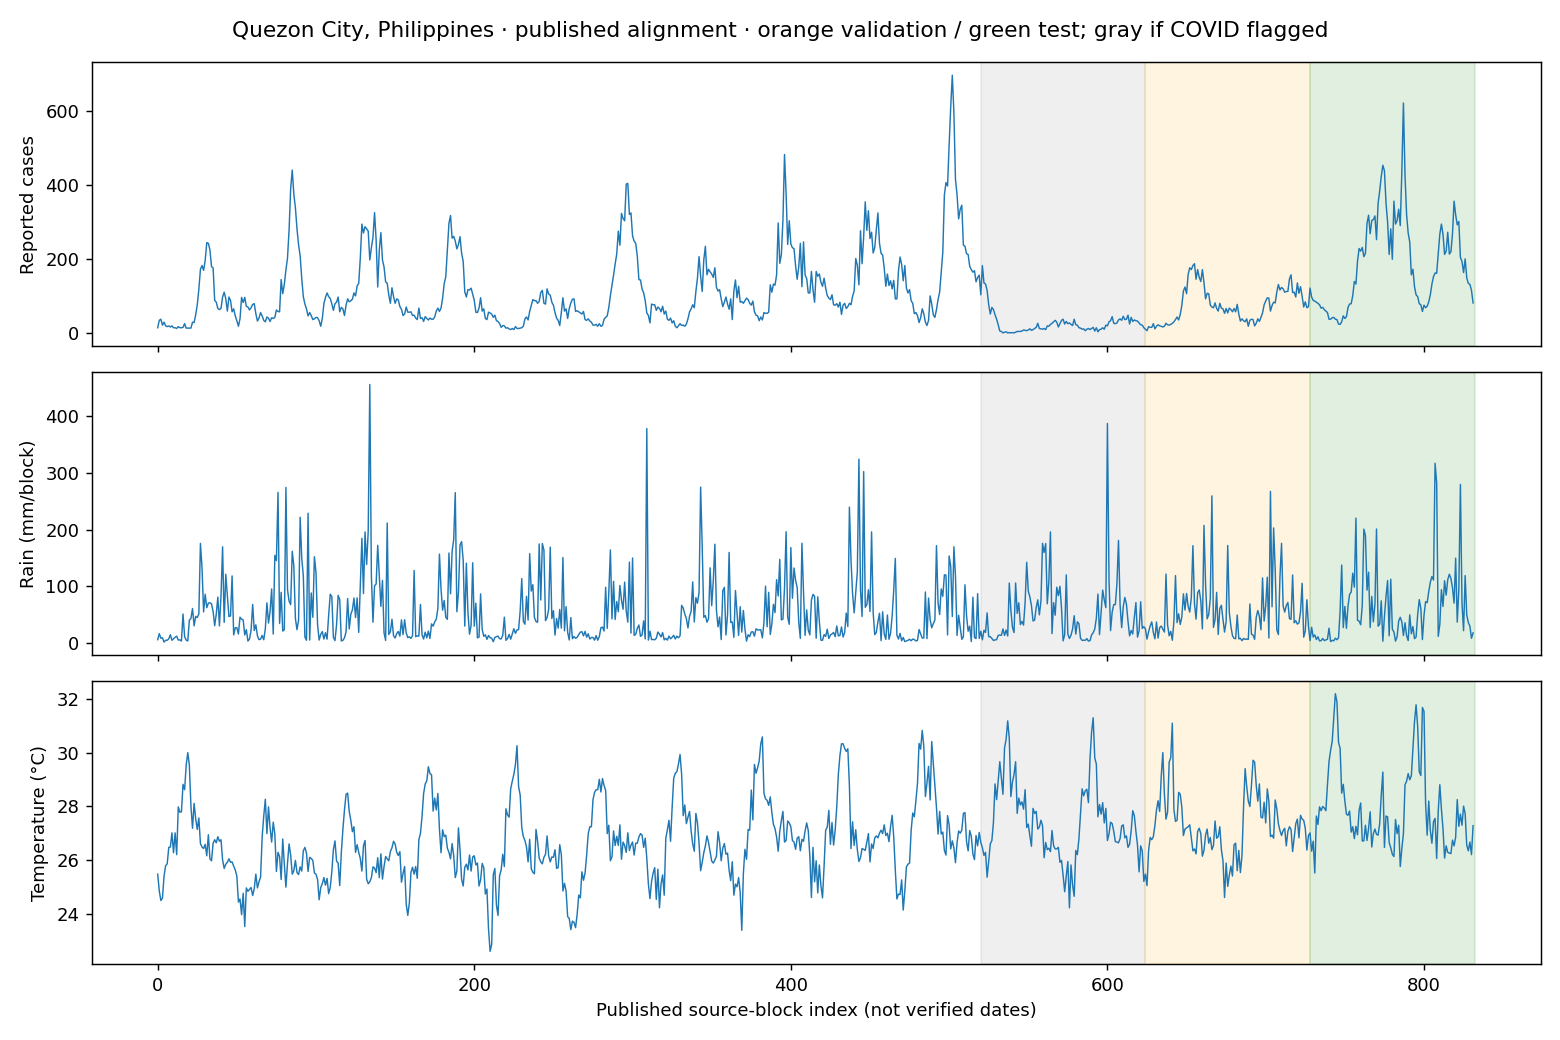

/content/outputs/dengue/b7f9cc3954ac/dataset_audit.json

/content/outputs/dengue/b7f9cc3954ac/DATA_LICENSE.md

In [3]:
run('prepare')
plan=json.loads((ROOT/'results/plan.json').read_text())
print('Area:',plan['area'],'· Source:',plan['source_citation'])
record('plan.json')
record('context_preflight.json')
table('origin_manifest.csv',['partition','origin_key','horizon','target_key','cutoff'],limit=8)
figure('prepare.png')
display(FileLink(str(ROOT/'dataset_audit.json')))
display(FileLink(str(ROOT/'DATA_LICENSE.md')))


## 2. Build a fair chronological comparison

An **origin** is the last block at which a forecast is issued. A **horizon** says how many blocks ahead it predicts. A **lag** is an earlier observed value. **Leakage** occurs when fitting or prediction sees information unavailable at issuance.

Default history: 2010–2021; validation: 2022–2023; test: 2024–2025. Each evaluation year forecasts blocks 1–4, 5–8, …, 49–52 from the preceding origin: 26 origins × four horizons. Older test observations may enter later forecast contexts after becoming observable; test errors never tune settings.

We assume zero reporting delay initially. Event-date truncation cannot reconstruct historical publication vintages: final-run weather and revised counts may not have been available at the time. Foundation-model pretraining overlap is also unknown.

**Trace one row before trusting the rest.** The first table below takes the first test origin, horizon 1, and lists every weather-model feature with its value and the source blocks it reads. Every block is at or before the origin; the target block is not observed at issuance. The last row is the most recent training label that was already mature. The audit table then checks the same rule for every origin.

**Predict:** will persistence or the same block last year work better? Ridge fits a transparent log-count regression using past counts and known target-block seasonality. Negative inverse-transformed estimates are floored at zero and flagged; forecasts are not rounded for scoring.


Running baselines — log: /content/outputs/dengue/b7f9cc3954ac/baselines.log
baselines: PASS


| item | value | source_blocks |
| --- | --- | --- |
| forecast origin (issued after this block) |  | 2023-B52 |
| target (not observed at issuance) |  | 2024-B01 |
| cases_lag_0 | 72.0 | 2023-B52 |
| cases_lag_1 | 69.0 | 2023-B51 |
| cases_lag_2 | 85.0 | 2023-B50 |
| cases_lag_3 | 71.0 | 2023-B49 |
| cases_lag_4 | 100.0 | 2023-B48 |
| cases_lag_8 | 98.0 | 2023-B44 |
| cases_lag_12 | 147.0 | 2023-B40 |
| cases_lag_52 | 67.0 | 2022-B52 |
| cases_mean_4 | 74.25 | 2023-B49 .. 2023-B52 |
| cases_mean_8 | 95.875 | 2023-B45 .. 2023-B52 |
| cases_mean_12 | 103.6667 | 2023-B41 .. 2023-B52 |
| target_block_sin | 0.0 | target block calendar position (known in advance) |
| target_block_cos | 1.0 | target block calendar position (known in advance) |
| rain_lag_0 | 28.9005 | 2023-B52 |
| rain_lag_1 | 76.1351 | 2023-B51 |
| rain_lag_2 | 20.864 | 2023-B50 |
| rain_lag_3 | 10.0761 | 2023-B49 |
| rain_lag_4 | 105.2351 | 2023-B48 |
| rain_mean_4 | 33.9939 | 2023-B49 .. 2023-B52 |
| rain_mean_8 | 45.6504 | 2023-B45 .. 2023-B52 |
| temp_lag_0 | 26.9143 | 2023-B52 |
| temp_lag_1 | 26.3714 | 2023-B51 |
| temp_lag_2 | 27.1857 | 2023-B50 |
| temp_lag_3 | 27.4857 | 2023-B49 |
| temp_lag_4 | 27.5286 | 2023-B48 |
| temp_mean_4 | 26.9893 | 2023-B49 .. 2023-B52 |
| temp_mean_8 | 27.1893 | 2023-B45 .. 2023-B52 |
| latest mature training label (cases) | 72 | 2023-B52 |

Showing 30 of 30 rows. All columns in the CSV: item, value, source_blocks


/content/outputs/dengue/b7f9cc3954ac/results/feature_example.csv

| partition | origin | horizon | cutoff | max_training_target | max_training_input | future_input_used |
| --- | --- | --- | --- | --- | --- | --- |
| validation | 623 | 1 | 623 | 623 | 622 | False |
| validation | 623 | 2 | 623 | 623 | 621 | False |
| validation | 623 | 3 | 623 | 623 | 620 | False |
| validation | 623 | 4 | 623 | 623 | 619 | False |
| validation | 627 | 1 | 627 | 627 | 626 | False |
| validation | 627 | 2 | 627 | 627 | 625 | False |
| validation | 627 | 3 | 627 | 627 | 624 | False |
| validation | 627 | 4 | 627 | 627 | 623 | False |

Showing 8 of 208 rows. All columns in the CSV: partition, origin, horizon, cutoff, max_training_target, max_training_input, query_latest_input, future_input_used


/content/outputs/dengue/b7f9cc3954ac/results/availability_audit.csv

{
  "persistence": {
    "origins": 26,
    "pairs": 104,
    "mae": 16.932692307692307,
    "horizons": {
      "1": {
        "n": 26,
        "mae": 14.076923076923077,
        "rmse": 18.619675284287524,
        "bias": -3.5384615384615383
      },
      "2": {
        "n": 26,
        "mae": 12.76923076923077,
        "rmse": 17.373720207432658,
        "bias": 1.0
      },
      "3": {
        "n": 26,
        "mae": 18.307692307692307,
        "rmse": 22.264148483432006,
        "bias": 2.230769230769231
      },
      "4": {
        "n": 26,
        "mae": 22.576923076923077,
        "rmse": 30.2139804624385,
        "bias": -2.1923076923076925
      }
    },
    "seasonal_skill": 0.6077951002227171
  },
  "ridge": {
    "origins": 26,
    "pairs": 104,
    "mae": 75.12820084410619,
    "horizons": {
      "1": {
        "n": 26,
        "mae": 43.071642038272984,
        "rmse": 89.21780824814434,
        "bias": 0.8208011001658968
      },
      "2": {
        "n": 26,
      

/content/outputs/dengue/b7f9cc3954ac/results/baseline_metrics.json

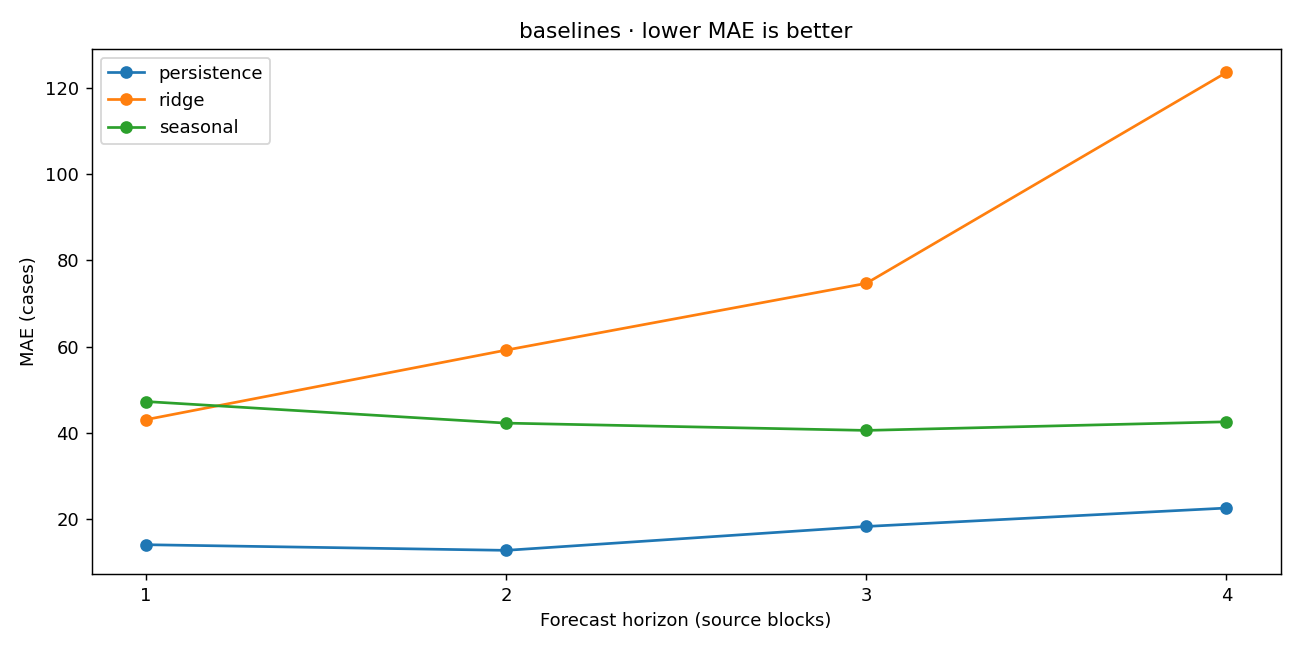

In [4]:
run('baselines')
table('feature_example.csv',['item','value','source_blocks'])
table('availability_audit.csv',['partition','origin','horizon','cutoff','max_training_target','max_training_input','future_input_used'],limit=8)
record('baseline_metrics.json')
figure('baselines.png')


<details><summary>Interpretation checkpoint</summary>
A seasonal baseline can capture recurring patterns but miss changing intensity. Persistence can work over short horizons but miss turning points. Neither guarantees good high-case forecasts. Features and training labels must satisfy their own availability cutoffs, not merely precede the final test year.
</details>

## 3. Compare Chronos and the weather ablation

Chronos-2 reads the last 104 case blocks without gradient training. Mitra performs horizon-specific regression using labelled in-context examples; it does not fine-tune weights here. Validation selects 52 versus 104 issuance blocks for case-only Mitra, with shorter-window ties. Weather Mitra uses that exact setting and the same rows, adding only lagged rainfall and temperature. Fresh context preprocessing uses training examples only.

**Predict:** will weather help every horizon? The controlled question is **Mitra + weather versus Mitra case-only**. Chronos versus Mitra changes the model family too, so it cannot isolate weather's effect.

**What to notice:** all six systems should have 104 validation forecasts. A worse foundation-model score is legitimate evidence, not a notebook error.


Running validation — log: /content/outputs/dengue/b7f9cc3954ac/validation.log
mitra_cases: origin 1/26 2021-B52
mitra_cases: origin 2/26 2022-B04
mitra_cases: origin 3/26 2022-B08
mitra_cases: origin 4/26 2022-B12
mitra_cases: origin 5/26 2022-B16
mitra_cases: origin 6/26 2022-B20
mitra_cases: origin 7/26 2022-B24
mitra_cases: origin 8/26 2022-B28
mitra_cases: origin 9/26 2022-B32
mitra_cases: origin 10/26 2022-B36
mitra_cases: origin 11/26 2022-B40
mitra_cases: origin 12/26 2022-B44
mitra_cases: origin 13/26 2022-B48
mitra_cases: origin 14/26 2022-B52
mitra_cases: origin 15/26 2023-B04
mitra_cases: origin 16/26 2023-B08
mitra_cases: origin 17/26 2023-B12
mitra_cases: origin 18/26 2023-B16
mitra_cases: origin 19/26 2023-B20
mitra_cases: origin 20/26 2023-B24
mitra_cases: origin 21/26 2023-B28
mitra_cases: origin 22/26 2023-B32
mitra_cases: origin 23/26 2023-B36
mitra_cases: origin 24/26 2023-B40
mitra_cases: origin 25/26 2023-B44
mitra_cases: origin 26/26 2023-B48
mitra_cases: origin 1

/content/outputs/dengue/b7f9cc3954ac/results/selection.json

{
  "chronos": {
    "origins": 26,
    "pairs": 104,
    "mae": 18.628139569209175,
    "horizons": {
      "1": {
        "n": 26,
        "mae": 17.841542097238396,
        "rmse": 23.766555375487762,
        "bias": -7.072476827181303
      },
      "2": {
        "n": 26,
        "mae": 14.899374851813683,
        "rmse": 19.69820635613053,
        "bias": -3.8670763969421387
      },
      "3": {
        "n": 26,
        "mae": 17.849592172182522,
        "rmse": 23.548909409403382,
        "bias": -3.3373965116647573
      },
      "4": {
        "n": 26,
        "mae": 23.92204915560209,
        "rmse": 32.893399717680694,
        "bias": -8.051948987520658
      }
    },
    "seasonal_skill": 0.5685241614258899
  },
  "mitra_cases": {
    "origins": 26,
    "pairs": 104,
    "mae": 20.498909961397832,
    "horizons": {
      "1": {
        "n": 26,
        "mae": 21.15745250822003,
        "rmse": 32.29545990773166,
        "bias": -6.162982403505783
      },
      "2": {
    

/content/outputs/dengue/b7f9cc3954ac/results/validation_metrics.json

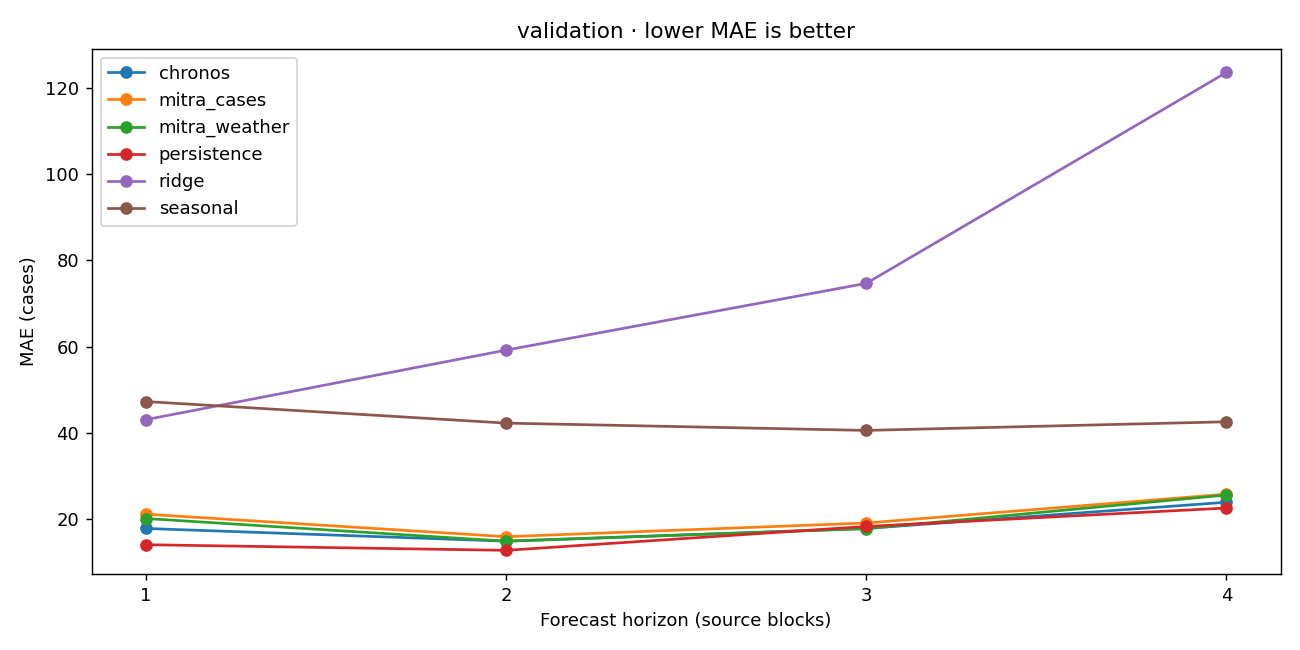

Running lock — log: /content/outputs/dengue/b7f9cc3954ac/lock.log
lock: PASS
{
  "identity": "3361d1bfb3b7638dc63d4ccc41fd7e3f9cd9d3d39e70d6d8102d3394920531fb",
  "window": 52,
  "plan_sha256": "4a76a645635a7a3f97e8128620ea4f6a1c866283ff853f005be82204d0e7dadd",
  "systems": [
    "persistence",
    "seasonal",
    "ridge",
    "chronos",
    "mitra_cases",
    "mitra_weather"
  ],
  "target_transform": "log1p for ridge/mitra; expm1 then nonnegative floor",
  "weather_comparison": "mitra_weather minus mitra_cases",
  "seed": 42,
  "retrospective_delay_assumption": 0,
  "scope": "exploratory_published_source_blocks"
}


/content/outputs/dengue/b7f9cc3954ac/results/experiment_lock.json

In [5]:
run('validation')
record('selection.json')
record('validation_metrics.json')
figure('validation.png')
run('lock')
record('experiment_lock.json')


## 4. Evaluate held-out published blocks

Settings are now locked. **MAE** is the average absolute count error; lower is better. **Bias** is prediction minus reference; a negative value means underprediction. Skill compares MAE with seasonal naïve and is undefined if its denominator is zero.

**Predict:** will validation's ranking persist? Read each horizon separately, then the equal-horizon mean. Inspect high-case blocks defined by the development-history 90th percentile; this is not an official outbreak threshold.

The paired weather comparison reports weather MAE minus case-only MAE. Negative favours weather. A bootstrap resamples contiguous groups of four origins, keeping their horizons together; its interval is descriptive with only two evaluation years.

Chronos's nominal 80% model interval is not a guaranteed calibrated interval. Inspect its actual coverage and width. Mitra and Ridge have point forecasts, not borrowed Chronos intervals.

The largest-misses table shows each miss's published count (`reference`), the forecast, the signed error (forecast minus reference; negative means underprediction) and its size. Pick one and explain it: was it a high-case block, and did every system miss it?


Running test — log: /content/outputs/dengue/b7f9cc3954ac/test.log
chronos: origin 1/26 2023-B52
chronos: origin 2/26 2024-B04
chronos: origin 3/26 2024-B08
chronos: origin 4/26 2024-B12
chronos: origin 5/26 2024-B16
chronos: origin 6/26 2024-B20
chronos: origin 7/26 2024-B24
chronos: origin 8/26 2024-B28
chronos: origin 9/26 2024-B32
chronos: origin 10/26 2024-B36
chronos: origin 11/26 2024-B40
chronos: origin 12/26 2024-B44
chronos: origin 13/26 2024-B48
chronos: origin 14/26 2024-B52
chronos: origin 15/26 2025-B04
chronos: origin 16/26 2025-B08
chronos: origin 17/26 2025-B12
chronos: origin 18/26 2025-B16
chronos: origin 19/26 2025-B20
chronos: origin 20/26 2025-B24
chronos: origin 21/26 2025-B28
chronos: origin 22/26 2025-B32
chronos: origin 23/26 2025-B36
chronos: origin 24/26 2025-B40
chronos: origin 25/26 2025-B44
chronos: origin 26/26 2025-B48
mitra_cases: origin 1/26 2023-B52
mitra_cases: origin 2/26 2024-B04
mitra_cases: origin 3/26 2024-B08
mitra_cases: origin 4/26 2024-B12
m

/content/outputs/dengue/b7f9cc3954ac/results/metrics.json

{
  "difference_b_minus_a": -6.612748664343753,
  "ci95": [
    -21.475152912462782,
    6.441538327715383
  ],
  "n_origins": 26,
  "n_pairs": 104,
  "n_groups": 7,
  "group_sizes": [
    4,
    4,
    4,
    4,
    4,
    4,
    2
  ],
  "replicates": 2000,
  "seed": 42
}


/content/outputs/dengue/b7f9cc3954ac/results/paired_comparison.json

{
  "persistence": {
    "n": 35,
    "threshold": 242.4000000000001,
    "metrics": {
      "n": 35,
      "mae": 99.31428571428572,
      "rmse": 138.72933565554393,
      "bias": 8.114285714285714
    },
    "underprediction_rate": 0.5714285714285714
  },
  "seasonal": {
    "n": 35,
    "threshold": 242.4000000000001,
    "metrics": {
      "n": 35,
      "mae": 195.6,
      "rmse": 228.30355732163764,
      "bias": -194.22857142857143
    },
    "underprediction_rate": 0.9428571428571428
  },
  "ridge": {
    "n": 35,
    "threshold": 242.4000000000001,
    "metrics": {
      "n": 35,
      "mae": 204.67169653469819,
      "rmse": 280.74579447796185,
      "bias": 43.95249797390653
    },
    "underprediction_rate": 0.5428571428571428
  },
  "chronos": {
    "n": 35,
    "threshold": 242.4000000000001,
    "metrics": {
      "n": 35,
      "mae": 90.62327270507812,
      "rmse": 119.11389386255914,
      "bias": -15.545084926060268
    },
    "underprediction_rate": 0.657142857142

/content/outputs/dengue/b7f9cc3954ac/results/high_case_metrics.json

{
  "1": {
    "n": 26,
    "raw_coverage_80": 0.6923076923076923,
    "raw_mean_width": 104.42915094815768,
    "pinball": [
      6.257534203162563,
      17.79541668525109,
      9.826239028343789
    ]
  },
  "2": {
    "n": 26,
    "raw_coverage_80": 0.6538461538461539,
    "raw_mean_width": 129.06402837313138,
    "pinball": [
      8.117321087763859,
      24.19235999767597,
      12.019364166259761
    ]
  },
  "3": {
    "n": 26,
    "raw_coverage_80": 0.6153846153846154,
    "raw_mean_width": 149.78901334909293,
    "pinball": [
      13.810683162395772,
      31.356043815612793,
      16.18350689227764
    ]
  },
  "4": {
    "n": 26,
    "raw_coverage_80": 0.5384615384615384,
    "raw_mean_width": 169.97247842641977,
    "pinball": [
      13.883276015061599,
      42.04942453824557,
      24.920944918118998
    ]
  }
}


/content/outputs/dengue/b7f9cc3954ac/results/interval_metrics.json

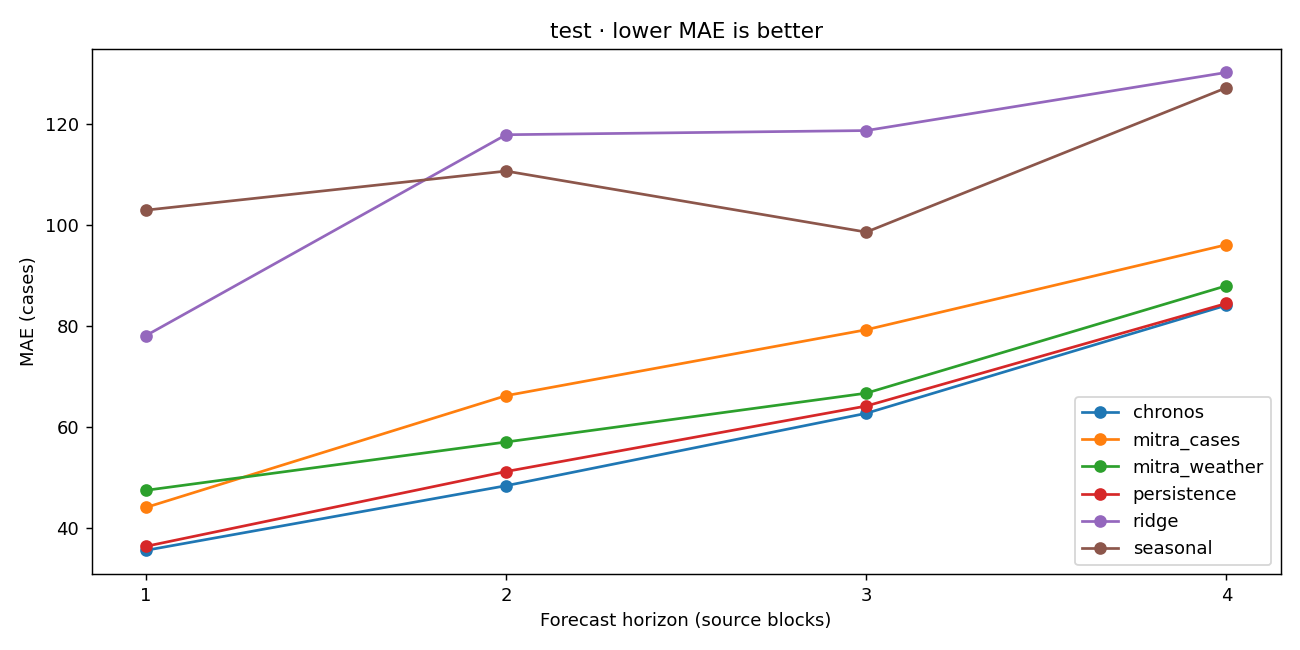

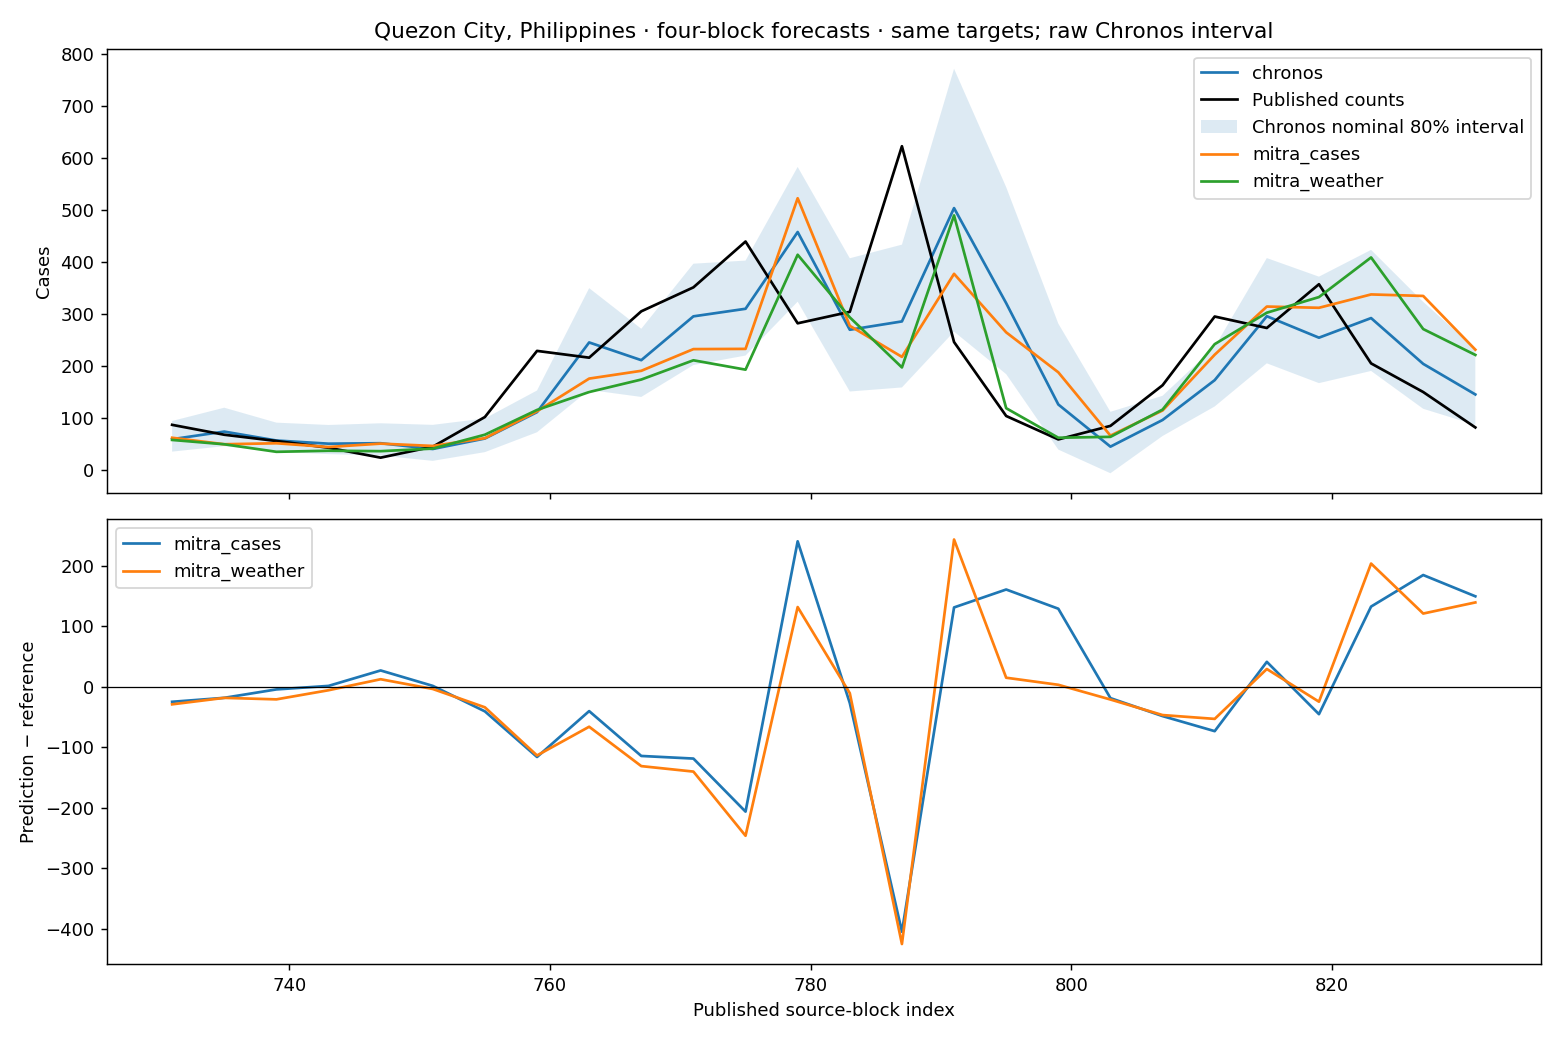

| system | target_key | horizon | reference | prediction | error | abs_error |
| --- | --- | --- | --- | --- | --- | --- |
| ridge | 2025-B10 | 2 | 321 | 1229.035 | 908.035 | 908.035 |
| ridge | 2025-B09 | 1 | 427 | 1096.748 | 669.748 | 669.748 |
| ridge | 2025-B11 | 3 | 271 | 912.546 | 641.546 | 641.546 |
| seasonal | 2025-B08 | 4 | 622 | 68.0 | -554.0 | 554.0 |
| ridge | 2025-B08 | 4 | 622 | 99.04 | -522.96 | 522.96 |
| mitra_weather | 2025-B08 | 4 | 622 | 197.232 | -424.768 | 424.768 |
| ridge | 2025-B44 | 4 | 205 | 618.397 | 413.397 | 413.397 |
| mitra_cases | 2025-B08 | 4 | 622 | 217.505 | -404.495 | 404.495 |
| persistence | 2025-B12 | 4 | 246 | 622.0 | 376.0 | 376.0 |
| seasonal | 2025-B07 | 3 | 437 | 77.0 | -360.0 | 360.0 |

Showing 10 of 20 rows. All columns in the CSV: system, origin_key, target_key, horizon, reference, prediction, error, abs_error, raw_prediction, clipped


/content/outputs/dengue/b7f9cc3954ac/results/largest_misses.csv

In [6]:
run('test')
record('metrics.json')
record('paired_comparison.json')
record('high_case_metrics.json')
record('interval_metrics.json')
figure('test.png')
figure('test_forecasts.png')
table('largest_misses.csv',['system','target_key','horizon','reference','prediction','error','abs_error'],limit=10)


<details><summary>Worked interpretation guidance</summary>
If adding weather lowers average MAE but worsens the longest horizon or high-case errors, report that trade-off. An interval containing zero does not establish that the models are identical. A consistent gain on these rows still does not validate the source timing, prove causality or establish future operational performance.
</details>

## 5. Change one thing: assume a two-block reporting delay

**Predict → change → run → observe → explain.** The following completed activity changes only the availability cutoff from zero to two blocks on validation origins. Target blocks stay identical; Chronos must forecast two additional steps from its earlier cutoff. Mitra's labels must also be mature by that cutoff.

This two-block delay is illustrative, not an estimate of actual reporting delay. Canonical test outputs and the locked experiment remain unchanged. The first table pairs each system's zero-delay and two-block validation MAE on the same 104 targets; `change` is delay-two minus zero-delay, so a positive value means the delay hurt. The second table shows individual paired forecasts.


Running activity — log: /content/outputs/dengue/b7f9cc3954ac/activity.log
chronos: origin 1/26 2021-B52
chronos: origin 2/26 2022-B04
chronos: origin 3/26 2022-B08
chronos: origin 4/26 2022-B12
chronos: origin 5/26 2022-B16
chronos: origin 6/26 2022-B20
chronos: origin 7/26 2022-B24
chronos: origin 8/26 2022-B28
chronos: origin 9/26 2022-B32
chronos: origin 10/26 2022-B36
chronos: origin 11/26 2022-B40
chronos: origin 12/26 2022-B44
chronos: origin 13/26 2022-B48
chronos: origin 14/26 2022-B52
chronos: origin 15/26 2023-B04
chronos: origin 16/26 2023-B08
chronos: origin 17/26 2023-B12
chronos: origin 18/26 2023-B16
chronos: origin 19/26 2023-B20
chronos: origin 20/26 2023-B24
chronos: origin 21/26 2023-B28
chronos: origin 22/26 2023-B32
chronos: origin 23/26 2023-B36
chronos: origin 24/26 2023-B40
chronos: origin 25/26 2023-B44
chronos: origin 26/26 2023-B48
mitra_cases: origin 1/26 2021-B52
mitra_cases: origin 2/26 2022-B04
mitra_cases: origin 3/26 2022-B08
mitra_cases: origin 4/26 20

| system | pairs | mae_delay_0 | mae_delay_2 | change |
| --- | --- | --- | --- | --- |
| persistence | 104 | 16.933 | 22.971 | 6.038 |
| seasonal | 104 | 43.173 | 43.173 | 0.0 |
| ridge | 104 | 75.128 | 109.049 | 33.921 |
| chronos | 104 | 18.628 | 23.786 | 5.158 |
| mitra_cases | 104 | 20.499 | 23.526 | 3.027 |
| mitra_weather | 104 | 19.607 | 24.669 | 5.062 |

Showing 6 of 6 rows. All columns in the CSV: system, pairs, mae_delay_0, mae_delay_2, change


/content/outputs/dengue/b7f9cc3954ac/results/delay_summary.csv

| system | target_key | horizon | reference | prediction_delay_0 | prediction_delay_2 | abs_error_change |
| --- | --- | --- | --- | --- | --- | --- |
| persistence | 2022-B01 | 1 | 11 | 15.0 | 23.0 | 8.0 |
| persistence | 2022-B02 | 2 | 7 | 15.0 | 23.0 | 8.0 |
| persistence | 2022-B03 | 3 | 18 | 15.0 | 23.0 | 2.0 |
| persistence | 2022-B04 | 4 | 16 | 15.0 | 23.0 | 6.0 |
| persistence | 2022-B05 | 1 | 16 | 16.0 | 7.0 | 9.0 |
| persistence | 2022-B06 | 2 | 26 | 16.0 | 7.0 | 9.0 |
| persistence | 2022-B07 | 3 | 12 | 16.0 | 7.0 | 1.0 |
| persistence | 2022-B08 | 4 | 19 | 16.0 | 7.0 | 9.0 |
| persistence | 2022-B09 | 1 | 23 | 19.0 | 26.0 | -1.0 |
| persistence | 2022-B10 | 2 | 20 | 19.0 | 26.0 | 5.0 |
| persistence | 2022-B11 | 3 | 19 | 19.0 | 26.0 | 7.0 |
| persistence | 2022-B12 | 4 | 17 | 19.0 | 26.0 | 7.0 |

Showing 12 of 624 rows. All columns in the CSV: system, origin_key, target_key, horizon, reference, prediction_delay_0, prediction_delay_2, abs_error_delay_0, abs_error_delay_2, abs_error_change


/content/outputs/dengue/b7f9cc3954ac/results/delay_comparison.csv

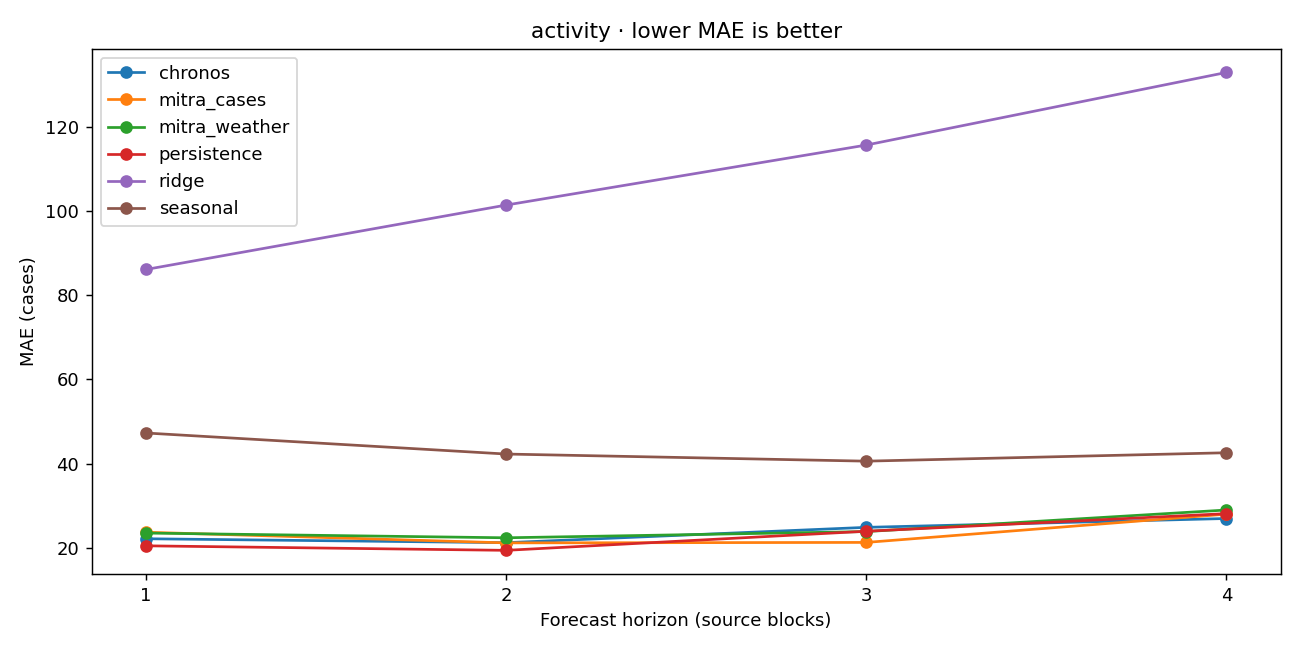

{
  "chronos": {
    "origins": 26,
    "pairs": 104,
    "mae": 23.786153463216927,
    "horizons": {
      "1": {
        "n": 26,
        "mae": 22.139666997469387,
        "rmse": 29.752639670051188,
        "bias": -8.584697796748234
      },
      "2": {
        "n": 26,
        "mae": 21.204629311194786,
        "rmse": 27.729174560819494,
        "bias": -4.995193774883564
      },
      "3": {
        "n": 26,
        "mae": 24.850262495187614,
        "rmse": 32.43382110329139,
        "bias": -4.730645619905912
      },
      "4": {
        "n": 26,
        "mae": 26.950055049015926,
        "rmse": 38.37046545755938,
        "bias": -9.918203647320087
      }
    },
    "seasonal_skill": 0.44905123381412904
  },
  "mitra_cases": {
    "origins": 26,
    "pairs": 104,
    "mae": 23.52627773796629,
    "horizons": {
      "1": {
        "n": 26,
        "mae": 23.692919143094706,
        "rmse": 31.79630330523861,
        "bias": -9.541432541175663
      },
      "2": {
     

/content/outputs/dengue/b7f9cc3954ac/results/delay_metrics.json

In [7]:
run('activity')
table('delay_summary.csv',['system','pairs','mae_delay_0','mae_delay_2','change'])
table('delay_comparison.csv',['system','target_key','horizon','reference','prediction_delay_0','prediction_delay_2','abs_error_change'],limit=12)
figure('activity.png')
record('delay_metrics.json')


## 6. Forecast beyond the final source block

Fit/context information now extends through the last published row. The next four block forecasts have no observed reference in this dataset. We export them without an accuracy score or a claim about today's real-world dengue situation.

**What to notice:** the original source year/block labels continue. The first table places all six systems side by side for the four target blocks. The second lists all 24 forecasts: `prediction` is the value used (never below zero), `raw_prediction` and `clipped` show any flooring, and `q10`/`q50`/`q90` are Chronos's nominal quantiles (blank for systems without intervals). There is no reference column because these blocks have not been observed. These are source-block projections, not reconstructed dates.


In [8]:
run('future')
table('future_forecast_view.csv',['target_key','horizon','persistence','seasonal','ridge','chronos','mitra_cases','mitra_weather'])
table('future_predictions.csv',['system','target_key','horizon','prediction','raw_prediction','clipped','q10','q50','q90'])


Running future — log: /content/outputs/dengue/b7f9cc3954ac/future.log
chronos: origin 1/1 2025-B52
mitra_cases: origin 1/1 2025-B52
mitra_weather: origin 1/1 2025-B52
future: PASS


| target_key | horizon | persistence | seasonal | ridge | chronos | mitra_cases | mitra_weather |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2026-B01 | 1 | 82.0 | 200.0 | 89.33 | 72.43 | 83.19 | 89.0 |
| 2026-B02 | 2 | 82.0 | 357.0 | 88.11 | 66.43 | 82.43 | 116.14 |
| 2026-B03 | 3 | 82.0 | 295.0 | 85.68 | 61.15 | 93.44 | 214.98 |
| 2026-B04 | 4 | 82.0 | 304.0 | 79.88 | 53.04 | 106.49 | 286.85 |

Showing 4 of 4 rows. All columns in the CSV: target_key, horizon, persistence, seasonal, ridge, chronos, mitra_cases, mitra_weather


/content/outputs/dengue/b7f9cc3954ac/results/future_forecast_view.csv

| system | target_key | horizon | prediction | raw_prediction | clipped | q10 | q50 | q90 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| persistence | 2026-B01 | 1 | 82.0 | 82.0 | False |  |  |  |
| seasonal | 2026-B01 | 1 | 200.0 | 200.0 | False |  |  |  |
| ridge | 2026-B01 | 1 | 89.32684456008379 | 89.32684456008379 | False |  |  |  |
| persistence | 2026-B02 | 2 | 82.0 | 82.0 | False |  |  |  |
| seasonal | 2026-B02 | 2 | 357.0 | 357.0 | False |  |  |  |
| ridge | 2026-B02 | 2 | 88.11401187609805 | 88.11401187609805 | False |  |  |  |
| persistence | 2026-B03 | 3 | 82.0 | 82.0 | False |  |  |  |
| seasonal | 2026-B03 | 3 | 295.0 | 295.0 | False |  |  |  |
| ridge | 2026-B03 | 3 | 85.68347755419204 | 85.68347755419204 | False |  |  |  |
| persistence | 2026-B04 | 4 | 82.0 | 82.0 | False |  |  |  |
| seasonal | 2026-B04 | 4 | 304.0 | 304.0 | False |  |  |  |
| ridge | 2026-B04 | 4 | 79.88174060899037 | 79.88174060899037 | False |  |  |  |
| chronos | 2026-B01 | 1 | 72.43489837646484 | 72.43489837646484 | False | 56.00224304199219 | 72.43489837646484 | 99.71806335449219 |
| chronos | 2026-B02 | 2 | 66.43270874023438 | 66.43270874023438 | False | 44.750335693359375 | 66.43270874023438 | 102.7325439453125 |
| chronos | 2026-B03 | 3 | 61.15238952636719 | 61.15238952636719 | False | 32.660400390625 | 61.15238952636719 | 103.01851654052734 |
| chronos | 2026-B04 | 4 | 53.03715515136719 | 53.03715515136719 | False | 20.622055053710938 | 53.03715515136719 | 108.29664611816406 |
| mitra_cases | 2026-B01 | 1 | 83.18829893189506 | 83.18829893189506 | False |  |  |  |
| mitra_cases | 2026-B02 | 2 | 82.43286530538793 | 82.43286530538793 | False |  |  |  |
| mitra_cases | 2026-B03 | 3 | 93.4404796216856 | 93.4404796216856 | False |  |  |  |
| mitra_cases | 2026-B04 | 4 | 106.48997623180415 | 106.48997623180415 | False |  |  |  |
| mitra_weather | 2026-B01 | 1 | 88.9971094740931 | 88.9971094740931 | False |  |  |  |
| mitra_weather | 2026-B02 | 2 | 116.13566952413515 | 116.13566952413515 | False |  |  |  |
| mitra_weather | 2026-B03 | 3 | 214.98492328548224 | 214.98492328548224 | False |  |  |  |
| mitra_weather | 2026-B04 | 4 | 286.8487880012167 | 286.8487880012167 | False |  |  |  |

Showing 24 of 24 rows. All columns in the CSV: system, origin, origin_key, cutoff, target_index, target_key, horizon, delay, reference, raw_prediction, prediction, clipped, q10, q50, q90


/content/outputs/dengue/b7f9cc3954ac/results/future_predictions.csv

## 7. Export, reconstruct and verify

The notebook saves safe numeric context and preprocessing state, pinned model identities and checksums. A fresh process reconstructs both models plus the fitted Ridge state, then reproduces the final completed origin and unscored final inference. It verifies all four horizons and Chronos quantiles with declared tolerances.

Results include predictions, metrics, availability audit, source/licence notices, stage receipts and verification. The ZIP excludes the source archive and model weights. It does retain aggregate numeric support contexts (lagged counts, and rain and temperature for weather Mitra) for two origins; `artifact_manifest.json` says exactly what. The summary records the area, limitations, Python, device, precision and package versions, with the resource figures labelled as targets.

**Reuse the bundle elsewhere.** The last step extracts `results.zip` into a new directory that holds only this notebook's embedded code, then reproduces the same forecasts from the bundle alone. It needs the verified model snapshots, but not the original run directory, its data file or its settings. Elsewhere, run the embedded `dengue_runtime.py --consume results.zip --workdir <new dir> --models <snapshot cache>` next to `source.json` and `model_manifest.json`. Preserve the executed notebook alongside the ZIP for qualification evidence.


In [9]:
run('reload')
record('verification.json')
run('report')
record('run_summary.json')
display(FileLink(str(ROOT/'results/results.zip')))
consume()


Running reload — log: /content/outputs/dengue/b7f9cc3954ac/reload.log
reload: PASS
{
  "passed": true,
  "predictions_checked": 32,
  "max_absolute_difference": 0.0,
  "atol": 0.001,
  "rtol": 0.0001,
  "fresh_process": true,
  "pid": 2880,
  "scope": "same workspace; see consumer_verification.json for the exported bundle"
}


/content/outputs/dengue/b7f9cc3954ac/results/verification.json

Running report — log: /content/outputs/dengue/b7f9cc3954ac/report.log
report: PASS
{
  "scope": "exploratory_published_source_blocks",
  "status": "executed_candidate",
  "area": "Quezon City, Philippines",
  "source_citation": "Zenodo record 21978184 (QC Data sheet), ODC-ODbL 1.0",
  "units": {
    "cases": "reported cases per source block (nonnegative integer count)",
    "rain": "mm per source block (nonnegative)",
    "temp": "degrees Celsius"
  },
  "timing_verified": false,
  "weather_alignment_verified": false,
  "prospective_validation": false,
  "limitations": [
    "Published source-block order only: calendar dates and case-weather alignment are unverified",
    "Final data vintages: revised counts and retrospective IMERG/ERA5-Land products do not reconstruct what was available when each forecast would have been issued",
    "Zero reporting delay is an assumption; the two-block delay activity is illustrative",
    "Foundation-model pretraining overlap with this series is unkn

/content/outputs/dengue/b7f9cc3954ac/results/run_summary.json

/content/outputs/dengue/b7f9cc3954ac/results/results.zip

consume: PASS (32 predictions)

{
  "passed": true,
  "bundle_sha256": "bd49e2674748052e567613abdb2c7d09d214ca3204228f561748ea3bc4deb7a3",
  "predictions_checked": 32,
  "max_absolute_difference": 0.0,
  "atol": 0.001,
  "rtol": 0.0001,
  "original_workspace_read": false,
  "inputs": "results.zip, trusted embedded code/manifests and verified model snapshots"
}


## 8. Conclude with evidence

Use your measured results to complete: “Adding historical weather changed MAE from ___ to ___ at horizon ___. The paired difference was ___, with interval ___. On high-case blocks ___. Under the illustrative delay ___. These results support ___ under the published alignment, but cannot establish ___.”

Keep the unresolved block definition, case–weather alignment, retrospective availability, possible pretraining overlap and limited evaluation span visible. Your completion record is an optional learning aid, not a required submission.

**Continue on DIMER:** explore the Chronos-2 and Mitra regression pipelines for their complete supported workflows. This capstone demonstrates in-context regression; it does not claim gradient fine-tuning or a deployment-ready health service.

Sources: [pinned dataset](https://zenodo.org/records/21978184), [UPRI-NOAH documentation](https://github.com/UPRI-NOAH/dengue-rainfall-dataset), [author repository](https://github.com/pelitro-rcw/dengue-environmental-dataset), [Chronos-2](https://huggingface.co/amazon/chronos-2), [Mitra regressor](https://huggingface.co/autogluon/mitra-regressor). The two dataset repositories currently distribute the same workbook; they are not independent replication cohorts.
